# Wordle Solver Comparison Project

## Reproducibility Notebook

This notebook contains the code required to reproduce the experiments reported in the dissertation.

The project evaluates five Wordle solving strategies:

1. First-candidate solver
2. Random solver
3. Frequency-based solver
4. Positional frequency solver
5. Approximate entropy solver

The aim is to compare solver performance under identical datasets, game rules, stopping criteria, and evaluation metrics. The notebook reproduces the reported success rates, average guess counts, unsolved games, runtimes, statistical tests, and figures.

In [43]:
from pathlib import Path
from collections import Counter, defaultdict
from functools import lru_cache
from typing import Callable

import math
import random
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# Reproducibility
random.seed(42)
np.random.seed(42)

# Global plotting style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "legend.frameon": False
})

# 1. Data Loading and Validation

The analysis uses two publicly available Wordle word lists:

- `wordle-answers-alphabetical.txt`: the list of 2,315 possible solution words.
- `nyt-wordle-allowed-guesses-2026-03-06.txt`: the list of 14,855 allowable guess words.

Before running any experiments, the lists are validated to ensure that:

- all words are five letters long;
- all words contain alphabetic characters only;
- there are no duplicate entries;
- every solution word is also a valid guess.

These checks ensure that the simulation uses a fixed and valid Wordle solution space throughout the analysis.

In [44]:
def load_words(file_path: str, word_length: int = 5) -> list[str]:
    """
    Load a word list from a text file and validate that each word has
    the required length and contains alphabetic characters only.
    """
    path = Path(file_path)

    if not path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    with path.open("r", encoding="utf-8") as file:
        words = [line.strip().lower() for line in file if line.strip()]

    invalid_words = [
        word for word in words
        if len(word) != word_length or not word.isalpha()
    ]

    if invalid_words:
        raise ValueError(f"Invalid words found: {invalid_words[:10]}")

    return words

In [45]:
solutions = load_words("wordle-answers-alphabetical.txt")
allowed_guesses = load_words("nyt-wordle-allowed-guesses-2026-03-06.txt")

print(f"Number of solution words: {len(solutions)}")
print(f"Number of allowable guesses: {len(allowed_guesses)}")
print(f"Unique solution words: {len(set(solutions))}")
print(f"Unique allowable guesses: {len(set(allowed_guesses))}")
print("All solutions are valid guesses:", set(solutions).issubset(set(allowed_guesses)))

Number of solution words: 2315
Number of allowable guesses: 14855
Unique solution words: 2315
Unique allowable guesses: 14855
All solutions are valid guesses: True


# 2. Wordle Feedback Function

The feedback function is the core rule-based component of the simulator. For each guess, it compares the guessed word with the hidden solution and returns a five-element feedback pattern.

The feedback labels are:

- `green`: the letter is correct and in the correct position;
- `yellow`: the letter is present but in the wrong position;
- `grey`: the letter is absent, or all copies of that letter have already been matched.

A two-pass algorithm is used to correctly handle repeated letters. Exact positional matches are identified first, and only the remaining unmatched letters are then considered for yellow feedback. This avoids incorrectly marking repeated letters as present when the solution contains fewer copies of that letter.

In [46]:
def get_feedback(guess: str, solution: str) -> list[str]:
    """
    Return Wordle-style feedback for a guess against a hidden solution.

    Parameters
    ----------
    guess : str
        Five-letter guessed word.
    solution : str
        Five-letter hidden target word.

    Returns
    -------
    list[str]
        A list containing five feedback labels: 'green', 'yellow', or 'grey'.
    """
    guess = guess.lower().strip()
    solution = solution.lower().strip()

    if len(guess) != 5 or len(solution) != 5:
        raise ValueError("Both guess and solution must be five-letter words.")

    feedback = ["grey"] * 5
    remaining_letters = Counter()

    # First pass: mark exact matches as green.
    for i in range(5):
        if guess[i] == solution[i]:
            feedback[i] = "green"
        else:
            remaining_letters[solution[i]] += 1

    # Second pass: mark misplaced unmatched letters as yellow.
    for i in range(5):
        if feedback[i] == "green":
            continue

        letter = guess[i]

        if remaining_letters[letter] > 0:
            feedback[i] = "yellow"
            remaining_letters[letter] -= 1

    return feedback

In [47]:
def feedback_to_boxes(feedback: list[str]) -> str:
    """
    Convert a feedback pattern into Wordle-style emoji boxes for display.
    """
    mapping = {
        "green": "🟩",
        "yellow": "🟨",
        "grey": "⬜"
    }

    return "".join(mapping[colour] for colour in feedback)

## Feedback validation examples

The following examples check that the feedback function behaves correctly in ordinary cases and in repeated-letter cases. Repeated letters are particularly important because incorrect feedback at this stage would affect every later candidate-filtering step.

In [48]:
test_cases = [
    ("crane", "slate"),
    ("llama", "lakes"),
    ("abbey", "cabin"),
    ("eerie", "serve"),
    ("apple", "allee"),
]

for guess, solution in test_cases:
    feedback = get_feedback(guess, solution)
    print(f"{guess} vs {solution} -> {feedback} -> {feedback_to_boxes(feedback)}")

crane vs slate -> ['grey', 'grey', 'green', 'grey', 'green'] -> ⬜⬜🟩⬜🟩
llama vs lakes -> ['green', 'grey', 'yellow', 'grey', 'grey'] -> 🟩⬜🟨⬜⬜
abbey vs cabin -> ['yellow', 'grey', 'green', 'grey', 'grey'] -> 🟨⬜🟩⬜⬜
eerie vs serve -> ['grey', 'green', 'green', 'grey', 'green'] -> ⬜🟩🟩⬜🟩
apple vs allee -> ['green', 'grey', 'grey', 'yellow', 'green'] -> 🟩⬜⬜🟨🟩


In [49]:
assert get_feedback("llama", "lakes") == ["green", "grey", "yellow", "grey", "grey"]
assert get_feedback("eerie", "serve") == ["grey", "green", "green", "grey", "green"]
assert get_feedback("abbey", "cabin") == ["yellow", "grey", "green", "grey", "grey"]

print("Feedback validation checks passed.")

Feedback validation checks passed.


# 3. Candidate Filtering

After each guess, the set of feasible solution words is updated using the observed feedback pattern. A candidate word remains possible only if it would generate exactly the same feedback pattern when compared with the current guess.

This candidate-filtering step represents the knowledge-updating mechanism of the game. All solver strategies use the same filtering function, ensuring that performance differences arise from the guess-selection rule rather than from different interpretations of feedback.

In [50]:
def filter_candidates(
    candidates: list[str],
    guess: str,
    feedback: list[str]
) -> list[str]:
    """
    Retain only candidate words that are consistent with an observed feedback pattern.

    A candidate is retained if guessing `guess` against that candidate would produce
    the same feedback pattern observed in the actual game.
    """
    return [
        word for word in candidates
        if get_feedback(guess, word) == feedback
    ]

## Candidate-filtering validation

The next cells demonstrate candidate filtering on both a small artificial candidate set and the full solution list. The true solution should always remain in the candidate set after filtering.

In [51]:
test_candidates = ["cigar", "rebut", "sissy", "humph", "awake", "blush"]

guess = "cigar"
true_solution = "awake"
observed_feedback = get_feedback(guess, true_solution)

filtered = filter_candidates(test_candidates, guess, observed_feedback)

print("Guess:", guess)
print("True solution:", true_solution)
print("Observed feedback:", observed_feedback, feedback_to_boxes(observed_feedback))
print("Filtered candidates:", filtered)

assert true_solution in filtered

Guess: cigar
True solution: awake
Observed feedback: ['grey', 'grey', 'grey', 'yellow', 'grey'] ⬜⬜⬜🟨⬜
Filtered candidates: ['awake']


In [52]:
guess = "cigar"
true_solution = "awake"
observed_feedback = get_feedback(guess, true_solution)

remaining_candidates = filter_candidates(solutions, guess, observed_feedback)

print("Guess:", guess)
print("True solution:", true_solution)
print("Feedback:", observed_feedback, feedback_to_boxes(observed_feedback))
print("Number of remaining candidates:", len(remaining_candidates))
print("First 20 remaining candidates:", remaining_candidates[:20])
print("True solution still included:", true_solution in remaining_candidates)

assert true_solution in remaining_candidates

Guess: cigar
True solution: awake
Feedback: ['grey', 'grey', 'grey', 'yellow', 'grey'] ⬜⬜⬜🟨⬜
Number of remaining candidates: 266
First 20 remaining candidates: ['abase', 'abate', 'abbey', 'abbot', 'abled', 'abode', 'about', 'above', 'abuse', 'abyss', 'adapt', 'adept', 'adobe', 'adopt', 'adult', 'afoot', 'afoul', 'album', 'alley', 'allot']
True solution still included: True


## Filtering from a sequence of guesses

During a full game, the solver accumulates several guess-feedback pairs. The following helper function applies all previous constraints in sequence.

In [53]:
def filter_candidates_from_history(
    candidates: list[str],
    history: list[tuple[str, list[str]]]
) -> list[str]:
    """
    Apply a sequence of guess-feedback constraints to a candidate set.

    Parameters
    ----------
    candidates : list[str]
        Current list of possible solution words.
    history : list[tuple[str, list[str]]]
        Previous guesses and their observed feedback patterns.

    Returns
    -------
    list[str]
        Candidate words consistent with all previous feedback.
    """
    remaining = candidates[:]

    for guess, feedback in history:
        remaining = filter_candidates(remaining, guess, feedback)

    return remaining

# 4. Game Simulation Framework

The simulator models Wordle as a sequential decision-making process. For each hidden solution, a solver repeatedly:

1. selects a guess using the current candidate set;
2. receives feedback according to the Wordle rules;
3. filters the candidate set using the observed feedback.

The process stops when the target word is identified or when the six-guess limit is reached.

For each game, the simulator records the solution word, guess sequence, feedback sequence, whether the game was solved, and the number of guesses used.

In [54]:
def simulate_game(
    solution: str,
    solutions: list[str],
    allowed_guesses: list[str],
    solver: Callable,
    max_guesses: int = 6,
    verbose: bool = False
) -> dict:
    """
    Simulate one complete Wordle game.

    Parameters
    ----------
    solution : str
        Hidden target word.
    solutions : list[str]
        Valid solution words.
    allowed_guesses : list[str]
        Full list of allowable guess words.
    solver : Callable
        Solver function with signature:
        solver(candidates, allowed_guesses, history) -> guess
    max_guesses : int
        Maximum number of allowed guesses.
    verbose : bool
        Whether to print each turn.

    Returns
    -------
    dict
        Dictionary containing the solution, guesses, feedback history,
        solved status, and number of guesses used.
    """
    candidates = solutions[:]
    history = []

    for turn in range(1, max_guesses + 1):
        guess = solver(candidates, allowed_guesses, history)

        if guess not in allowed_guesses:
            raise ValueError(f"Solver returned invalid guess: {guess}")

        feedback = get_feedback(guess, solution)
        history.append((guess, feedback))

        if verbose:
            print(f"Turn {turn}: {guess} -> {feedback_to_boxes(feedback)}")

        if guess == solution:
            return {
                "solution": solution,
                "guesses": [g for g, _ in history],
                "feedback_history": [f for _, f in history],
                "solved": True,
                "num_guesses": turn
            }

        candidates = filter_candidates(candidates, guess, feedback)

        if verbose:
            print(f"Remaining candidates: {len(candidates)}")

    return {
        "solution": solution,
        "guesses": [g for g, _ in history],
        "feedback_history": [f for _, f in history],
        "solved": False,
        "num_guesses": max_guesses
    }

# 5. Baseline Solver Strategies

Two baseline solvers are implemented before introducing heuristic and information-theoretic methods.

The first-candidate solver is deterministic and always selects the first remaining feasible word. The random solver selects uniformly from the remaining feasible candidates. Both baselines rely only on candidate filtering and do not use statistical information about the remaining solution space.

In [55]:
def first_candidate_solver(
    candidates: list[str],
    allowed_guesses: list[str],
    history: list[tuple[str, list[str]]]
) -> str:
    """
    Deterministic baseline solver.

    Always returns the first remaining feasible candidate.
    """
    if not candidates:
        raise ValueError("No candidates remaining.")

    return candidates[0]

In [56]:
def random_candidate_solver(
    candidates: list[str],
    allowed_guesses: list[str],
    history: list[tuple[str, list[str]]]
) -> str:
    """
    Stochastic baseline solver.

    Selects uniformly at random from the remaining feasible candidates.
    """
    if not candidates:
        raise ValueError("No candidates remaining.")

    return random.choice(candidates)

## Baseline solver check

The following cell runs both baseline solvers on a single target word. This is not part of the main experimental evaluation; it verifies that the simulator and solver interface work correctly.

In [57]:
example_solution = "cigar"

first_example = simulate_game(
    solution=example_solution,
    solutions=solutions,
    allowed_guesses=allowed_guesses,
    solver=first_candidate_solver,
    verbose=True
)

print("\nFirst-candidate result:")
print(first_example)

Turn 1: aback -> 🟨⬜⬜🟨⬜
Remaining candidates: 63
Turn 2: cache -> 🟩🟨⬜⬜⬜
Remaining candidates: 3
Turn 3: cigar -> 🟩🟩🟩🟩🟩

First-candidate result:
{'solution': 'cigar', 'guesses': ['aback', 'cache', 'cigar'], 'feedback_history': [['yellow', 'grey', 'grey', 'yellow', 'grey'], ['green', 'yellow', 'grey', 'grey', 'grey'], ['green', 'green', 'green', 'green', 'green']], 'solved': True, 'num_guesses': 3}


In [58]:
random.seed(42)

random_example = simulate_game(
    solution=example_solution,
    solutions=solutions,
    allowed_guesses=allowed_guesses,
    solver=random_candidate_solver,
    verbose=True
)

print("\nRandom solver result:")
print(random_example)

Turn 1: craft -> 🟩🟨🟨⬜⬜
Remaining candidates: 12
Turn 2: cairn -> 🟩🟨🟨🟨⬜
Remaining candidates: 2
Turn 3: circa -> 🟩🟩🟨⬜🟨
Remaining candidates: 1
Turn 4: cigar -> 🟩🟩🟩🟩🟩

Random solver result:
{'solution': 'cigar', 'guesses': ['craft', 'cairn', 'circa', 'cigar'], 'feedback_history': [['green', 'yellow', 'yellow', 'grey', 'grey'], ['green', 'yellow', 'yellow', 'yellow', 'grey'], ['green', 'green', 'yellow', 'grey', 'yellow'], ['green', 'green', 'green', 'green', 'green']], 'solved': True, 'num_guesses': 4}


# 6. Experimental Evaluation Function

The following function evaluates a solver across a set of target words and returns both summary metrics and per-game results.

The reported metrics are:

- number of games evaluated;
- number solved and unsolved;
- success rate;
- average number of guesses for solved games;
- worst-case number of guesses among solved games;
- total runtime.

The per-game results are retained so that distributions, hard cases, and statistical tests can be reproduced.

In [59]:
def run_experiment(
    solutions: list[str],
    allowed_guesses: list[str],
    solver: Callable,
    max_guesses: int = 6,
    limit: int | None = None,
    verbose: bool = False
) -> dict:
    """
    Evaluate a solver over multiple Wordle solution words.
    """
    test_solutions = solutions[:limit] if limit is not None else solutions[:]

    results = []
    start_time = time.time()

    for index, solution in enumerate(test_solutions, start=1):
        result = simulate_game(
            solution=solution,
            solutions=solutions,
            allowed_guesses=allowed_guesses,
            solver=solver,
            max_guesses=max_guesses,
            verbose=False
        )

        results.append(result)

        if verbose and index % 100 == 0:
            print(f"Completed {index}/{len(test_solutions)} games")

    runtime = time.time() - start_time

    solved_games = [r for r in results if r["solved"]]
    unsolved_games = [r for r in results if not r["solved"]]

    success_rate = len(solved_games) / len(results)

    average_guesses = (
        np.mean([r["num_guesses"] for r in solved_games])
        if solved_games else np.nan
    )

    worst_case_guesses = (
        max(r["num_guesses"] for r in solved_games)
        if solved_games else np.nan
    )

    return {
        "solver_name": solver.__name__,
        "num_games": len(results),
        "num_solved": len(solved_games),
        "num_unsolved": len(unsolved_games),
        "success_rate": success_rate,
        "average_guesses_solved_only": average_guesses,
        "worst_case_guesses_solved_only": worst_case_guesses,
        "runtime_seconds": runtime,
        "results": results
    }

In [60]:
# Full baseline experiments

experiment_first_full = run_experiment(
    solutions=solutions,
    allowed_guesses=allowed_guesses,
    solver=first_candidate_solver,
    limit=None,
    verbose=True
)

random.seed(42)

experiment_random_full = run_experiment(
    solutions=solutions,
    allowed_guesses=allowed_guesses,
    solver=random_candidate_solver,
    limit=None,
    verbose=True
)

Completed 100/2315 games
Completed 200/2315 games
Completed 300/2315 games
Completed 400/2315 games
Completed 500/2315 games
Completed 600/2315 games
Completed 700/2315 games
Completed 800/2315 games
Completed 900/2315 games
Completed 1000/2315 games
Completed 1100/2315 games
Completed 1200/2315 games
Completed 1300/2315 games
Completed 1400/2315 games
Completed 1500/2315 games
Completed 1600/2315 games
Completed 1700/2315 games
Completed 1800/2315 games
Completed 1900/2315 games
Completed 2000/2315 games
Completed 2100/2315 games
Completed 2200/2315 games
Completed 2300/2315 games
Completed 100/2315 games
Completed 200/2315 games
Completed 300/2315 games
Completed 400/2315 games
Completed 500/2315 games
Completed 600/2315 games
Completed 700/2315 games
Completed 800/2315 games
Completed 900/2315 games
Completed 1000/2315 games
Completed 1100/2315 games
Completed 1200/2315 games
Completed 1300/2315 games
Completed 1400/2315 games
Completed 1500/2315 games
Completed 1600/2315 games
Comp

# 7. Frequency-Based Solver

The frequency-based solver uses the distribution of letters within the remaining candidate set to guide guess selection.

For each remaining candidate word, a score is calculated from the frequency of its unique letters. Repeated letters are counted only once so that words with broader letter coverage are favoured. This reflects the intuition that guesses containing common letters are likely to provide more useful feedback and reduce the candidate set more efficiently.

This solver represents a simple heuristic approach: it uses statistical information from the current candidate set but avoids expensive look-ahead or exhaustive optimisation.

In [61]:
def build_letter_frequencies(words: list[str]) -> Counter:
    """
    Count how often each letter appears across a list of words.

    Each letter is counted once per word so that repeated letters do not
    receive excessive weight.
    """
    frequencies = Counter()

    for word in words:
        frequencies.update(set(word))

    return frequencies

In [62]:
def score_word_by_frequency(word: str, frequencies: Counter) -> int:
    """
    Score a candidate word using overall letter frequencies.

    Duplicate letters are counted only once to encourage broad letter coverage.
    """
    return sum(frequencies[letter] for letter in set(word))

In [63]:
def frequency_solver(
    candidates: list[str],
    allowed_guesses: list[str],
    history: list[tuple[str, list[str]]]
) -> str:
    """
    Select the remaining candidate with the highest overall letter-frequency score.
    """
    if not candidates:
        raise ValueError("No candidates remaining.")

    frequencies = build_letter_frequencies(candidates)

    return max(
        candidates,
        key=lambda word: score_word_by_frequency(word, frequencies)
    )

## Frequency solver validation

The following single-game check verifies that the solver can interact correctly with the simulation framework before being evaluated across the full solution list.

In [64]:
frequency_example = simulate_game(
    solution="cigar",
    solutions=solutions,
    allowed_guesses=allowed_guesses,
    solver=frequency_solver,
    verbose=True
)

frequency_example

Turn 1: alert -> 🟨⬜⬜🟨⬜
Remaining candidates: 77
Turn 2: baron -> ⬜🟨🟨⬜⬜
Remaining candidates: 17
Turn 3: cigar -> 🟩🟩🟩🟩🟩


{'solution': 'cigar',
 'guesses': ['alert', 'baron', 'cigar'],
 'feedback_history': [['yellow', 'grey', 'grey', 'yellow', 'grey'],
  ['grey', 'yellow', 'yellow', 'grey', 'grey'],
  ['green', 'green', 'green', 'green', 'green']],
 'solved': True,
 'num_guesses': 3}

## Full frequency-solver experiment

The frequency-based solver is now evaluated across all 2,315 solution words.

In [65]:
experiment_frequency_full = run_experiment(
    solutions=solutions,
    allowed_guesses=allowed_guesses,
    solver=frequency_solver,
    limit=None,
    verbose=True
)

for key, value in experiment_frequency_full.items():
    if key != "results":
        print(f"{key}: {value}")

Completed 100/2315 games
Completed 200/2315 games
Completed 300/2315 games
Completed 400/2315 games
Completed 500/2315 games
Completed 600/2315 games
Completed 700/2315 games
Completed 800/2315 games
Completed 900/2315 games
Completed 1000/2315 games
Completed 1100/2315 games
Completed 1200/2315 games
Completed 1300/2315 games
Completed 1400/2315 games
Completed 1500/2315 games
Completed 1600/2315 games
Completed 1700/2315 games
Completed 1800/2315 games
Completed 1900/2315 games
Completed 2000/2315 games
Completed 2100/2315 games
Completed 2200/2315 games
Completed 2300/2315 games
solver_name: frequency_solver
num_games: 2315
num_solved: 2293
num_unsolved: 22
success_rate: 0.9904967602591793
average_guesses_solved_only: 3.6498037505451375
worst_case_guesses_solved_only: 6
runtime_seconds: 72.50533699989319


# 8. Positional Frequency Solver

The positional frequency solver extends the previous heuristic by considering where letters occur.

Instead of scoring a word only by overall letter frequency, this solver calculates letter frequencies separately for each of the five word positions. A candidate word receives a higher score when its letters occur frequently in their specific positions among the remaining candidates.

This allows the solver to exploit additional structure in the candidate set, especially when several feasible words contain similar letters but differ in their positions.

In [66]:
def build_positional_frequencies(candidates: list[str]) -> list[defaultdict]:
    """
    Count letter frequencies separately at each of the five positions.
    """
    position_counts = [defaultdict(int) for _ in range(5)]

    for word in candidates:
        for position, letter in enumerate(word):
            position_counts[position][letter] += 1

    return position_counts

In [67]:
def score_word_by_position(word: str, position_counts: list[defaultdict]) -> int:
    """
    Score a word using position-specific letter frequencies.
    """
    score = 0

    for position, letter in enumerate(word):
        score += position_counts[position][letter]

    return score

In [68]:
def positional_frequency_solver(
    candidates: list[str],
    allowed_guesses: list[str],
    history: list[tuple[str, list[str]]]
) -> str:
    """
    Select the remaining candidate with the highest positional-frequency score.
    """
    if not candidates:
        raise ValueError("No candidates remaining.")

    position_counts = build_positional_frequencies(candidates)

    return max(
        candidates,
        key=lambda word: score_word_by_position(word, position_counts)
    )

## Full positional-frequency experiment

The positional frequency solver is evaluated across the complete set of 2,315 solution words.

In [69]:
experiment_positional_full = run_experiment(
    solutions=solutions,
    allowed_guesses=allowed_guesses,
    solver=positional_frequency_solver,
    limit=None,
    verbose=True
)

for key, value in experiment_positional_full.items():
    if key != "results":
        print(f"{key}: {value}")

Completed 100/2315 games
Completed 200/2315 games
Completed 300/2315 games
Completed 400/2315 games
Completed 500/2315 games
Completed 600/2315 games
Completed 700/2315 games
Completed 800/2315 games
Completed 900/2315 games
Completed 1000/2315 games
Completed 1100/2315 games
Completed 1200/2315 games
Completed 1300/2315 games
Completed 1400/2315 games
Completed 1500/2315 games
Completed 1600/2315 games
Completed 1700/2315 games
Completed 1800/2315 games
Completed 1900/2315 games
Completed 2000/2315 games
Completed 2100/2315 games
Completed 2200/2315 games
Completed 2300/2315 games
solver_name: positional_frequency_solver
num_games: 2315
num_solved: 2301
num_unsolved: 14
success_rate: 0.9939524838012959
average_guesses_solved_only: 3.619295958279009
worst_case_guesses_solved_only: 6
runtime_seconds: 61.87380385398865


# 9. Approximate Entropy Solver

The entropy solver treats Wordle as a problem of uncertainty reduction. For each possible guess, the solver considers the feedback patterns that would be produced across the remaining candidate solutions. These feedback patterns partition the candidate set into groups.

A guess has high entropy when it produces many relatively balanced feedback groups. Such a guess is expected to reduce uncertainty more effectively because, regardless of the feedback received, the remaining candidate set is likely to become smaller.

For a guess \(g\), entropy is calculated as

\[
H(g) = - \sum_{j=1}^{k} p_j \log_2(p_j),
\]

where \(p_j\) is the probability of feedback pattern \(j\).

The implementation used in the report adopts a fixed opening guess, `SLATE`, before applying entropy calculations to the reduced candidate set. This avoids the expensive first-turn entropy calculation while preserving the information-theoretic decision rule for later turns.

In [70]:
def feedback_to_pattern(feedback: list[str]) -> tuple[str, ...]:
    """
    Convert a feedback list into a hashable feedback pattern.
    """
    return tuple(feedback)

In [71]:
def calculate_entropy(guess: str, candidates: list[str]) -> float:
    """
    Calculate the Shannon entropy of a guess over the current candidate set.
    """
    pattern_counts = Counter()

    for solution in candidates:
        feedback = get_feedback(guess, solution)
        pattern = feedback_to_pattern(feedback)
        pattern_counts[pattern] += 1

    total = len(candidates)
    entropy = 0.0

    for count in pattern_counts.values():
        p = count / total
        entropy -= p * math.log2(p)

    return entropy

In [72]:
def entropy_solver_fast(
    candidates: list[str],
    allowed_guesses: list[str],
    history: list[tuple[str, list[str]]]
) -> str:
    """
    Approximate entropy solver.

    Uses SLATE as a fixed opening guess, then selects the candidate with the
    highest entropy over the remaining candidate set.
    """
    if not candidates:
        raise ValueError("No candidates remaining.")

    if len(history) == 0:
        return "slate"

    if len(candidates) == 1:
        return candidates[0]

    return max(
        candidates,
        key=lambda word: calculate_entropy(word, candidates)
    )

## Entropy solver validation

The following single-game run checks that the entropy solver works correctly within the simulation framework.

In [73]:
entropy_example = simulate_game(
    solution="cigar",
    solutions=solutions,
    allowed_guesses=allowed_guesses,
    solver=entropy_solver_fast,
    verbose=True
)

entropy_example

Turn 1: slate -> ⬜⬜🟨⬜⬜
Remaining candidates: 136
Turn 2: manor -> ⬜🟨⬜⬜🟩
Remaining candidates: 5
Turn 3: briar -> ⬜⬜🟨🟩🟩
Remaining candidates: 2
Turn 4: cigar -> 🟩🟩🟩🟩🟩


{'solution': 'cigar',
 'guesses': ['slate', 'manor', 'briar', 'cigar'],
 'feedback_history': [['grey', 'grey', 'yellow', 'grey', 'grey'],
  ['grey', 'yellow', 'grey', 'grey', 'green'],
  ['grey', 'grey', 'yellow', 'green', 'green'],
  ['green', 'green', 'green', 'green', 'green']],
 'solved': True,
 'num_guesses': 4}

## Full approximate entropy experiment

The approximate entropy solver is evaluated across all 2,315 solution words. This is the entropy result reported in the dissertation.

In [74]:
experiment_entropy_full = run_experiment(
    solutions=solutions,
    allowed_guesses=allowed_guesses,
    solver=entropy_solver_fast,
    limit=None,
    verbose=True
)

for key, value in experiment_entropy_full.items():
    if key != "results":
        print(f"{key}: {value}")

Completed 100/2315 games
Completed 200/2315 games
Completed 300/2315 games
Completed 400/2315 games
Completed 500/2315 games
Completed 600/2315 games
Completed 700/2315 games
Completed 800/2315 games
Completed 900/2315 games
Completed 1000/2315 games
Completed 1100/2315 games
Completed 1200/2315 games
Completed 1300/2315 games
Completed 1400/2315 games
Completed 1500/2315 games
Completed 1600/2315 games
Completed 1700/2315 games
Completed 1800/2315 games
Completed 1900/2315 games
Completed 2000/2315 games
Completed 2100/2315 games
Completed 2200/2315 games
Completed 2300/2315 games
solver_name: entropy_solver_fast
num_games: 2315
num_solved: 2308
num_unsolved: 7
success_rate: 0.9969762419006479
average_guesses_solved_only: 3.5177642980935877
worst_case_guesses_solved_only: 6
runtime_seconds: 262.7169842720032


# 10. Entropy Feasibility Experiment

The report includes a small feasibility experiment comparing the fully exhaustive entropy solver with the fixed-opening entropy approximation.

The purpose of this experiment is not to compare solver accuracy. Instead, it demonstrates why the fully exhaustive entropy approach was not used for the full evaluation. The exhaustive version evaluates a much larger guess pool and is therefore substantially slower, even when tested on only five solution words.

This section reproduces the feasibility comparison reported in the dissertation.

In [75]:
def entropy_solver_full(
    candidates: list[str],
    allowed_guesses: list[str],
    history: list[tuple[str, list[str]]]
) -> str:
    """
    Fully exhaustive entropy solver used for the feasibility comparison.

    The solver evaluates all allowable guesses using entropy when the candidate
    set is large. When only a few candidates remain, it restricts the guess pool
    to the remaining candidates to avoid wasting late guesses.
    """
    if not candidates:
        raise ValueError("No candidates remaining.")

    if len(candidates) == 1:
        return candidates[0]

    if len(candidates) <= 3:
        guess_pool = candidates
    else:
        guess_pool = allowed_guesses

    best_guess = None
    best_entropy = -1.0

    for guess in guess_pool:
        entropy = calculate_entropy(guess, candidates)

        if entropy > best_entropy:
            best_entropy = entropy
            best_guess = guess

    return best_guess

In [77]:
experiment_full_entropy_5 = run_experiment(
    solutions=solutions,
    allowed_guesses=allowed_guesses,
    solver=entropy_solver_full,
    limit=5,
    verbose=True
)

experiment_fast_entropy_5 = run_experiment(
    solutions=solutions,
    allowed_guesses=allowed_guesses,
    solver=entropy_solver_fast,
    limit=5,
    verbose=True
)

In [78]:
entropy_feasibility_table = pd.DataFrame([
    {
        "Solver": "Full entropy",
        "Games": experiment_full_entropy_5["num_games"],
        "Solved": experiment_full_entropy_5["num_solved"],
        "Success Rate": experiment_full_entropy_5["success_rate"],
        "Average Guesses": experiment_full_entropy_5["average_guesses_solved_only"],
        "Runtime (s)": experiment_full_entropy_5["runtime_seconds"]
    },
    {
        "Solver": "Fast entropy (SLATE)",
        "Games": experiment_fast_entropy_5["num_games"],
        "Solved": experiment_fast_entropy_5["num_solved"],
        "Success Rate": experiment_fast_entropy_5["success_rate"],
        "Average Guesses": experiment_fast_entropy_5["average_guesses_solved_only"],
        "Runtime (s)": experiment_fast_entropy_5["runtime_seconds"]
    }
])

entropy_feasibility_table

,Solver,Games,Solved,Success Rate,Average Guesses,Runtime (s)
0,Full entropy,5,5,1.0,3.2,2556.123314
1,Fast entropy (SLATE),5,5,1.0,3.0,0.109265


## 10.2 Entropy Walkthrough Example

This example reproduces a single game played by the approximate entropy solver. The hidden solution is fixed as `CRANE`.

The purpose of this walkthrough is to show how the entropy solver behaves during gameplay. After the fixed opening guess `SLATE`, the solver filters the candidate set using the observed feedback. It then calculates the entropy of each remaining candidate guess and selects the word with the highest expected information gain.

This provides a concrete example of how entropy-based guess selection differs from the simpler baseline and frequency-based methods.

In [79]:
def entropy_walkthrough(
    solution: str,
    solutions: list[str],
    allowed_guesses: list[str],
    max_guesses: int = 6,
    top_n: int = 5
) -> pd.DataFrame:
    """
    Produce a step-by-step walkthrough of the approximate entropy solver.

    The first guess is fixed as SLATE. After the first turn, the function
    calculates entropy scores for the remaining candidate words and selects
    the candidate with the highest entropy.

    Returns a DataFrame containing:
    - turn number
    - guess
    - feedback pattern
    - candidate count before filtering
    - candidate count after filtering
    - top entropy candidates considered at that turn
    """
    candidates = solutions[:]
    history = []
    walkthrough_rows = []

    for turn in range(1, max_guesses + 1):

        candidates_before = len(candidates)

        if turn == 1:
            guess = "slate"
            entropy_scores = None
            top_entropy_words = "Fixed opening guess"
        else:
            entropy_scores = [
                (word, calculate_entropy(word, candidates))
                for word in candidates
            ]

            entropy_scores = sorted(
                entropy_scores,
                key=lambda x: x[1],
                reverse=True
            )

            guess = entropy_scores[0][0]

            top_entropy_words = ", ".join(
                [f"{word.upper()} ({score:.3f})" for word, score in entropy_scores[:top_n]]
            )

        feedback = get_feedback(guess, solution)
        feedback_boxes = feedback_to_boxes(feedback)

        history.append((guess, feedback))

        if guess == solution:
            candidates_after = 1
        else:
            candidates = filter_candidates(candidates, guess, feedback)
            candidates_after = len(candidates)

        walkthrough_rows.append({
            "Turn": turn,
            "Guess": guess.upper(),
            "Feedback": feedback_boxes,
            "Candidates before": candidates_before,
            "Candidates after": candidates_after,
            "Top entropy candidates": top_entropy_words
        })

        if guess == solution:
            break

    return pd.DataFrame(walkthrough_rows)

In [80]:
entropy_crane_walkthrough = entropy_walkthrough(
    solution="crane",
    solutions=solutions,
    allowed_guesses=allowed_guesses,
    max_guesses=6,
    top_n=5
)

entropy_crane_walkthrough

,Turn,Guess,Feedback,Candidates before,Candidates after,Top entropy candidates
0,1,SLATE,⬜⬜🟩⬜🟩,2315,28,Fixed opening guess
1,2,CRAVE,🟩🟩🟩⬜🟩,28,2,"CRAVE (3.020), GRACE (2.910), GRAVE (2.855), G..."
2,3,CRANE,🟩🟩🟩🟩🟩,2,1,"CRANE (1.000), CRAZE (1.000)"


In [81]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

entropy_crane_walkthrough.to_csv(
    output_dir / "entropy_crane_walkthrough.csv",
    index=False
)

print("Saved entropy walkthrough.")


Saved entropy walkthrough.


In [82]:
for _, row in entropy_crane_walkthrough.iterrows():
    print(f"Turn {row['Turn']}")
    print(f"Guess: {row['Guess']}")
    print(f"Feedback: {row['Feedback']}")
    print(f"Candidates before: {row['Candidates before']}")
    print(f"Candidates after: {row['Candidates after']}")
    print(f"Top entropy candidates: {row['Top entropy candidates']}")
    print("-" * 60)

Turn 1
Guess: SLATE
Feedback: ⬜⬜🟩⬜🟩
Candidates before: 2315
Candidates after: 28
Top entropy candidates: Fixed opening guess
------------------------------------------------------------
Turn 2
Guess: CRAVE
Feedback: 🟩🟩🟩⬜🟩
Candidates before: 28
Candidates after: 2
Top entropy candidates: CRAVE (3.020), GRACE (2.910), GRAVE (2.855), GRADE (2.658), CRANE (2.627)
------------------------------------------------------------
Turn 3
Guess: CRANE
Feedback: 🟩🟩🟩🟩🟩
Candidates before: 2
Candidates after: 1
Top entropy candidates: CRANE (1.000), CRAZE (1.000)
------------------------------------------------------------


## 10.3 Runtime Benchmarking

Runtime measurements can vary slightly between otherwise identical notebook
executions because they are affected by operating-system scheduling, background
processes and hardware state. Each main solver is therefore timed three times,
with the mean and standard deviation reported. Solver outcomes remain fixed
because the datasets and random seed are reset before every run.

In [83]:
# Number of allowable guesses and possible solutions at the opening turn
num_allowed_guesses = len(allowed_guesses)
num_candidate_solutions = len(solutions)

opening_feedback_evaluations = (
    num_allowed_guesses * num_candidate_solutions
)

print(f"Allowable guesses: {num_allowed_guesses:,}")
print(f"Candidate solutions: {num_candidate_solutions:,}")
print(
    "Opening-turn guess-solution evaluations: "
    f"{opening_feedback_evaluations:,}"
)

Allowable guesses: 14,855
Candidate solutions: 2,315
Opening-turn guess-solution evaluations: 34,389,325


In [84]:
def benchmark_runtime(
    solver_name: str,
    solver_function: Callable,
    n_runs: int = 3,
    seed: int = 42
) -> pd.DataFrame:
    """
    Benchmark one solver repeatedly across the full solution list.

    The random seed is reset before every run so that stochastic solvers
    follow the same sequence of choices. Only runtime is intended to vary.
    """
    rows = []

    for run_number in range(1, n_runs + 1):

        random.seed(seed)
        np.random.seed(seed)

        experiment = run_experiment(
            solutions=solutions,
            allowed_guesses=allowed_guesses,
            solver=solver_function,
            limit=None,
            verbose=False
        )

        rows.append({
            "Solver": solver_name,
            "Run": run_number,
            "Runtime (s)": experiment["runtime_seconds"],
            "Solved": experiment["num_solved"],
            "Unsolved": experiment["num_unsolved"],
            "Average guesses": experiment[
                "average_guesses_solved_only"
            ]
        })

        print(
            f"{solver_name}, run {run_number}/{n_runs}: "
            f"{experiment['runtime_seconds']:.2f} seconds"
        )

    return pd.DataFrame(rows)

In [85]:
runtime_first = benchmark_runtime(
    solver_name="First-candidate",
    solver_function=first_candidate_solver,
    n_runs=3
)

runtime_random = benchmark_runtime(
    solver_name="Random",
    solver_function=random_candidate_solver,
    n_runs=3
)

runtime_frequency = benchmark_runtime(
    solver_name="Frequency-based",
    solver_function=frequency_solver,
    n_runs=3
)

runtime_positional = benchmark_runtime(
    solver_name="Positional frequency",
    solver_function=positional_frequency_solver,
    n_runs=3
)

runtime_entropy = benchmark_runtime(
    solver_name="Entropy",
    solver_function=entropy_solver_fast,
    n_runs=3
)

First-candidate, run 1/3: 42.72 seconds
First-candidate, run 2/3: 44.84 seconds
First-candidate, run 3/3: 44.40 seconds
Random, run 1/3: 42.04 seconds
Random, run 2/3: 41.42 seconds
Random, run 3/3: 42.85 seconds
Frequency-based, run 1/3: 59.48 seconds
Frequency-based, run 2/3: 57.69 seconds
Frequency-based, run 3/3: 59.43 seconds
Positional frequency, run 1/3: 49.95 seconds
Positional frequency, run 2/3: 49.89 seconds
Positional frequency, run 3/3: 49.43 seconds
Entropy, run 1/3: 211.43 seconds
Entropy, run 2/3: 206.33 seconds
Entropy, run 3/3: 960.48 seconds


In [86]:
runtime_runs = pd.concat(
    [
        runtime_first,
        runtime_random,
        runtime_frequency,
        runtime_positional,
        runtime_entropy
    ],
    ignore_index=True
)

runtime_summary = (
    runtime_runs
    .groupby("Solver", sort=False)
    .agg(
        mean_runtime=("Runtime (s)", "mean"),
        std_runtime=("Runtime (s)", "std"),
        min_runtime=("Runtime (s)", "min"),
        max_runtime=("Runtime (s)", "max"),
        solved=("Solved", "first"),
        unsolved=("Unsolved", "first"),
        average_guesses=("Average guesses", "first")
    )
    .reset_index()
)

runtime_summary

,Solver,mean_runtime,std_runtime,min_runtime,max_runtime,solved,unsolved,average_guesses
0,First-candidate,43.987976,1.119185,42.721543,44.844092,2257,58,4.274701
1,Random,42.102939,0.717408,41.421064,42.851256,2275,40,4.029011
2,Frequency-based,58.864809,1.016929,57.690910,59.476569,2293,22,3.649804
3,Positional frequency,49.754613,0.283934,49.428300,49.945299,2301,14,3.619296
4,Entropy,459.414677,433.942994,206.333968,960.480248,2308,7,3.517764


In [87]:
runtime_lookup = dict(
    zip(runtime_summary["Solver"],
        runtime_summary["mean_runtime"])
)

runtime_sd_lookup = dict(
    zip(runtime_summary["Solver"],
        runtime_summary["std_runtime"])
)

## 10.4 Detailed Runtime and Candidate-Set Profiling

This section investigates the computational behaviour of the solver
strategies in greater detail. In particular, it separates guess-selection
time from candidate-filtering time, measures candidate-set reduction across
turns, and examines why the positional frequency implementation completes
the full evaluation more quickly than the overall frequency implementation.

In [88]:


from collections import defaultdict

import matplotlib.pyplot as plt


def estimate_scoring_work(
    solver_name: str,
    candidates_before: int,
    turn: int
) -> dict:
    """
    Estimate the amount of solver-specific work performed during one decision.

    These are operation counts rather than runtime measurements:
    - First/random: one direct selection operation.
    - Frequency/positional: every remaining candidate is scored.
    - Approximate entropy:
        * fixed opening guess on turn 1;
        * afterwards, every candidate guess is evaluated against every
          possible remaining solution.
    """
    if solver_name in {"First-candidate", "Random"}:
        return {
            "candidates_scored": 1,
            "feedback_evaluations_for_scoring": 0
        }

    if solver_name in {"Frequency-based", "Positional frequency"}:
        return {
            "candidates_scored": candidates_before,
            "feedback_evaluations_for_scoring": 0
        }

    if solver_name == "Approximate entropy":
        if turn == 1 or candidates_before == 1:
            return {
                "candidates_scored": 1,
                "feedback_evaluations_for_scoring": 0
            }

        return {
            "candidates_scored": candidates_before,
            "feedback_evaluations_for_scoring":
                candidates_before * candidates_before
        }

    return {
        "candidates_scored": np.nan,
        "feedback_evaluations_for_scoring": np.nan
    }


def simulate_game_profiled(
    solution: str,
    solutions: list[str],
    allowed_guesses: list[str],
    solver,
    solver_name: str,
    max_guesses: int = 6
) -> tuple[dict, list[dict]]:
    """
    Simulate one Wordle game while profiling each turn.

    Records:
    - candidate-set size before and after each guess;
    - time used to select the guess;
    - time used to generate feedback;
    - time used to filter candidates;
    - estimated solver-specific scoring work.
    """
    candidates = solutions[:]
    history = []
    turn_records = []

    for turn in range(1, max_guesses + 1):
        candidates_before = len(candidates)

        # -----------------------------
        # Time the solver decision
        # -----------------------------
        decision_start = time.perf_counter()

        guess = solver(
            candidates,
            allowed_guesses,
            history
        )

        decision_time = time.perf_counter() - decision_start

        if guess not in allowed_guesses:
            raise ValueError(
                f"{solver_name} returned invalid guess: {guess}"
            )

        # -----------------------------
        # Time feedback generation
        # -----------------------------
        feedback_start = time.perf_counter()

        feedback = get_feedback(guess, solution)

        feedback_time = time.perf_counter() - feedback_start
        history.append((guess, feedback))

        solved = guess == solution

        # -----------------------------
        # Time candidate filtering
        # -----------------------------
        if solved:
            candidates_after = 1
            filtering_time = 0.0
        else:
            filtering_start = time.perf_counter()

            candidates = filter_candidates(
                candidates,
                guess,
                feedback
            )

            filtering_time = (
                time.perf_counter() - filtering_start
            )
            candidates_after = len(candidates)

        work = estimate_scoring_work(
            solver_name=solver_name,
            candidates_before=candidates_before,
            turn=turn
        )

        turn_records.append({
            "solver": solver_name,
            "solution": solution,
            "turn": turn,
            "guess": guess,
            "solved_on_turn": solved,
            "candidates_before": candidates_before,
            "candidates_after": candidates_after,
            "candidate_reduction": (
                candidates_before - candidates_after
            ),
            "proportion_eliminated": (
                (candidates_before - candidates_after)
                / candidates_before
                if candidates_before > 0
                else np.nan
            ),
            "decision_time_seconds": decision_time,
            "feedback_time_seconds": feedback_time,
            "filtering_time_seconds": filtering_time,
            "candidates_scored": work["candidates_scored"],
            "feedback_evaluations_for_scoring":
                work["feedback_evaluations_for_scoring"]
        })

        if solved:
            return (
                {
                    "solver": solver_name,
                    "solution": solution,
                    "solved": True,
                    "num_guesses": turn,
                    "guesses": [g for g, _ in history]
                },
                turn_records
            )

    return (
        {
            "solver": solver_name,
            "solution": solution,
            "solved": False,
            "num_guesses": max_guesses,
            "guesses": [g for g, _ in history]
        },
        turn_records
    )

In [89]:
def run_profiled_experiment(
    solver,
    solver_name: str,
    solutions: list[str],
    allowed_guesses: list[str],
    max_guesses: int = 6,
    limit: int | None = None,
    progress_every: int = 250
) -> dict:
    """
    Run a solver over multiple solutions while collecting detailed
    timing and candidate-set information.
    """
    test_solutions = (
        solutions[:limit]
        if limit is not None
        else solutions[:]
    )

    game_results = []
    turn_records = []

    total_start = time.perf_counter()

    for index, solution in enumerate(test_solutions, start=1):
        game_result, game_turns = simulate_game_profiled(
            solution=solution,
            solutions=solutions,
            allowed_guesses=allowed_guesses,
            solver=solver,
            solver_name=solver_name,
            max_guesses=max_guesses
        )

        game_results.append(game_result)
        turn_records.extend(game_turns)

        if (
            progress_every
            and index % progress_every == 0
        ):
            print(
                f"{solver_name}: "
                f"{index}/{len(test_solutions)} games completed"
            )

    total_runtime = time.perf_counter() - total_start

    games_df = pd.DataFrame(game_results)
    turns_df = pd.DataFrame(turn_records)

    solved_df = games_df[games_df["solved"]]

    return {
        "solver": solver_name,
        "runtime_seconds": total_runtime,
        "num_games": len(games_df),
        "num_solved": int(games_df["solved"].sum()),
        "num_unsolved": int((~games_df["solved"]).sum()),
        "success_rate": games_df["solved"].mean(),
        "average_guesses_solved_only": (
            solved_df["num_guesses"].mean()
        ),
        "total_decisions": len(turns_df),
        "average_decision_time_seconds": (
            turns_df["decision_time_seconds"].mean()
        ),
        "average_filtering_time_seconds": (
            turns_df["filtering_time_seconds"].mean()
        ),
        "total_decision_time_seconds": (
            turns_df["decision_time_seconds"].sum()
        ),
        "total_filtering_time_seconds": (
            turns_df["filtering_time_seconds"].sum()
        ),
        "total_candidates_scored": (
            turns_df["candidates_scored"].sum()
        ),
        "total_feedback_evaluations_for_scoring": (
            turns_df[
                "feedback_evaluations_for_scoring"
            ].sum()
        ),
        "games": games_df,
        "turns": turns_df
    }

In [90]:
# Reproducible seeds
random.seed(42)
np.random.seed(42)

profile_frequency = run_profiled_experiment(
    solver=frequency_solver,
    solver_name="Frequency-based",
    solutions=solutions,
    allowed_guesses=allowed_guesses,
    max_guesses=6
)

random.seed(42)
np.random.seed(42)

profile_positional = run_profiled_experiment(
    solver=positional_frequency_solver,
    solver_name="Positional frequency",
    solutions=solutions,
    allowed_guesses=allowed_guesses,
    max_guesses=6
)

print("Frequency runtime:", profile_frequency["runtime_seconds"])
print("Positional runtime:", profile_positional["runtime_seconds"])

Frequency-based: 250/2315 games completed
Frequency-based: 500/2315 games completed
Frequency-based: 750/2315 games completed
Frequency-based: 1000/2315 games completed
Frequency-based: 1250/2315 games completed
Frequency-based: 1500/2315 games completed
Frequency-based: 1750/2315 games completed
Frequency-based: 2000/2315 games completed
Frequency-based: 2250/2315 games completed
Positional frequency: 250/2315 games completed
Positional frequency: 500/2315 games completed
Positional frequency: 750/2315 games completed
Positional frequency: 1000/2315 games completed
Positional frequency: 1250/2315 games completed
Positional frequency: 1500/2315 games completed
Positional frequency: 1750/2315 games completed
Positional frequency: 2000/2315 games completed
Positional frequency: 2250/2315 games completed
Frequency runtime: 440.7840744999994
Positional runtime: 372.702540600003


In [91]:
solver_definitions = [
    ("First-candidate", first_candidate_solver),
    ("Random", random_candidate_solver),
    ("Frequency-based", frequency_solver),
    ("Positional frequency", positional_frequency_solver),
    ("Approximate entropy", entropy_solver_fast)
]

profiled_experiments = {}

for solver_name, solver_function in solver_definitions:
    print(f"\nRunning detailed profile: {solver_name}")

    random.seed(42)
    np.random.seed(42)

    profiled_experiments[solver_name] = (
        run_profiled_experiment(
            solver=solver_function,
            solver_name=solver_name,
            solutions=solutions,
            allowed_guesses=allowed_guesses,
            max_guesses=6
        )
    )


Running detailed profile: First-candidate
First-candidate: 250/2315 games completed
First-candidate: 500/2315 games completed
First-candidate: 750/2315 games completed
First-candidate: 1000/2315 games completed
First-candidate: 1250/2315 games completed
First-candidate: 1500/2315 games completed
First-candidate: 1750/2315 games completed
First-candidate: 2000/2315 games completed
First-candidate: 2250/2315 games completed

Running detailed profile: Random
Random: 250/2315 games completed
Random: 500/2315 games completed
Random: 750/2315 games completed
Random: 1000/2315 games completed
Random: 1250/2315 games completed
Random: 1500/2315 games completed
Random: 1750/2315 games completed
Random: 2000/2315 games completed
Random: 2250/2315 games completed

Running detailed profile: Frequency-based
Frequency-based: 250/2315 games completed
Frequency-based: 500/2315 games completed
Frequency-based: 750/2315 games completed
Frequency-based: 1000/2315 games completed
Frequency-based: 1250/23

In [92]:

runtime_rows = []

for solver_name, result in profiled_experiments.items():
    runtime_rows.append({
        "Solver": solver_name,
        "Total runtime (s)": result["runtime_seconds"],
        "Average guesses": (
            result["average_guesses_solved_only"]
        ),
        "Total decisions": result["total_decisions"],
        "Mean decision time (ms)": (
            result["average_decision_time_seconds"] * 1000
        ),
        "Mean filtering time (ms)": (
            result["average_filtering_time_seconds"] * 1000
        ),
        "Total decision time (s)": (
            result["total_decision_time_seconds"]
        ),
        "Total filtering time (s)": (
            result["total_filtering_time_seconds"]
        ),
        "Candidates scored": (
            result["total_candidates_scored"]
        ),
        "Entropy feedback evaluations": (
            result[
                "total_feedback_evaluations_for_scoring"
            ]
        )
    })

runtime_profile_table = pd.DataFrame(runtime_rows)

runtime_profile_table.round({
    "Total runtime (s)": 2,
    "Average guesses": 3,
    "Mean decision time (ms)": 4,
    "Mean filtering time (ms)": 4,
    "Total decision time (s)": 2,
    "Total filtering time (s)": 2
})

,Solver,Total runtime (s),Average guesses,Total decisions,Mean decision time (ms),Mean filtering time (ms),Total decision time (s),Total filtering time (s),Candidates scored,Entropy feedback evaluations
0,First-candidate,287.29,4.275,9996,0.0061,27.9642,0.06,279.53,9996,0
1,Random,56.34,4.029,9406,0.0076,5.7260,0.07,53.86,9406,0
2,Frequency-based,34.82,3.650,8501,1.4110,2.5771,12.00,21.91,5539261,0
3,Positional frequency,27.02,3.619,8412,0.7423,2.3283,6.24,19.59,5539432,0
4,Approximate entropy,104.91,3.518,8161,10.4664,2.2576,85.42,18.42,179101,22392840


In [93]:
runtime_profile_table.to_csv(
    output_dir / "solver_runtime_profile.csv",
    index=False
)

print("Saved detailed runtime profile.")

Saved detailed runtime profile.


In [94]:
frequency_positional_summary = pd.DataFrame([
    {
        "Solver": "Frequency-based",
        "Runtime (s)": profile_frequency["runtime_seconds"],
        "Average guesses": (
            profile_frequency[
                "average_guesses_solved_only"
            ]
        ),
        "Total decisions": (
            profile_frequency["total_decisions"]
        ),
        "Decision time (s)": (
            profile_frequency[
                "total_decision_time_seconds"
            ]
        ),
        "Filtering time (s)": (
            profile_frequency[
                "total_filtering_time_seconds"
            ]
        ),
        "Candidates scored": (
            profile_frequency[
                "total_candidates_scored"
            ]
        )
    },
    {
        "Solver": "Positional frequency",
        "Runtime (s)": profile_positional["runtime_seconds"],
        "Average guesses": (
            profile_positional[
                "average_guesses_solved_only"
            ]
        ),
        "Total decisions": (
            profile_positional["total_decisions"]
        ),
        "Decision time (s)": (
            profile_positional[
                "total_decision_time_seconds"
            ]
        ),
        "Filtering time (s)": (
            profile_positional[
                "total_filtering_time_seconds"
            ]
        ),
        "Candidates scored": (
            profile_positional[
                "total_candidates_scored"
            ]
        )
    }
])

frequency_positional_summary.round({
    "Runtime (s)": 2,
    "Average guesses": 3,
    "Decision time (s)": 2,
    "Filtering time (s)": 2
})

,Solver,Runtime (s),Average guesses,Total decisions,Decision time (s),Filtering time (s),Candidates scored
0,Frequency-based,440.78,3.650,8501,149.55,280.46,5539261
1,Positional frequency,372.70,3.619,8412,84.37,273.31,5539432


In [95]:
frequency_turns = profile_frequency["turns"].copy()
positional_turns = profile_positional["turns"].copy()

frequency_positional_turns = pd.concat(
    [frequency_turns, positional_turns],
    ignore_index=True
)

candidate_size_by_turn = (
    frequency_positional_turns
    .groupby(["solver", "turn"], as_index=False)
    .agg(
        games_reaching_turn=("solution", "count"),
        mean_candidates_before=("candidates_before", "mean"),
        median_candidates_before=("candidates_before", "median"),
        mean_candidates_after=("candidates_after", "mean"),
        median_candidates_after=("candidates_after", "median"),
        mean_proportion_eliminated=("proportion_eliminated", "mean"),
        mean_decision_time_ms=(
            "decision_time_seconds",
            lambda values: values.mean() * 1000
        )
    )
)

candidate_size_by_turn.round({
    "mean_candidates_before": 2,
    "median_candidates_before": 2,
    "mean_candidates_after": 2,
    "median_candidates_after": 2,
    "mean_proportion_eliminated": 3,
    "mean_decision_time_ms": 4
})

,solver,turn,games_reaching_turn,mean_candidates_before,median_candidates_before,mean_candidates_after,median_candidates_after,mean_proportion_eliminated,mean_decision_time_ms
0,Frequency-based,1,2315,2315.00,2315.0,71.60,52.0,0.969,61.9047
1,Frequency-based,2,2314,71.63,52.0,4.89,3.0,0.874,2.2551
2,Frequency-based,3,2184,5.12,3.0,1.52,1.0,0.513,0.3358
3,Frequency-based,4,1272,1.89,1.0,1.19,1.0,0.227,0.1830
4,Frequency-based,5,339,1.70,1.0,1.17,1.0,0.182,0.1287
5,Frequency-based,6,77,1.75,1.0,1.13,1.0,0.245,0.1512
6,Positional frequency,1,2315,2315.00,2315.0,71.57,51.0,0.969,34.8312
7,Positional frequency,2,2314,71.60,51.0,5.12,3.0,0.861,1.3077
8,Positional frequency,3,2168,5.40,3.0,1.46,1.0,0.526,0.2262
9,Positional frequency,4,1268,1.79,1.0,1.12,1.0,0.205,0.1482


In [96]:
candidate_size_wide = (
    candidate_size_by_turn
    .pivot(
        index="turn",
        columns="solver",
        values="mean_candidates_after"
    )
    .reset_index()
)

candidate_size_wide.round(2)

solver,turn,Frequency-based,Positional frequency
0,1,71.60,71.57
1,2,4.89,5.12
2,3,1.52,1.46
3,4,1.19,1.12
4,5,1.17,1.13
5,6,1.13,1.11


In [97]:
candidate_size_by_turn.to_csv(
    output_dir / "candidate_size_by_turn.csv",
    index=False
)

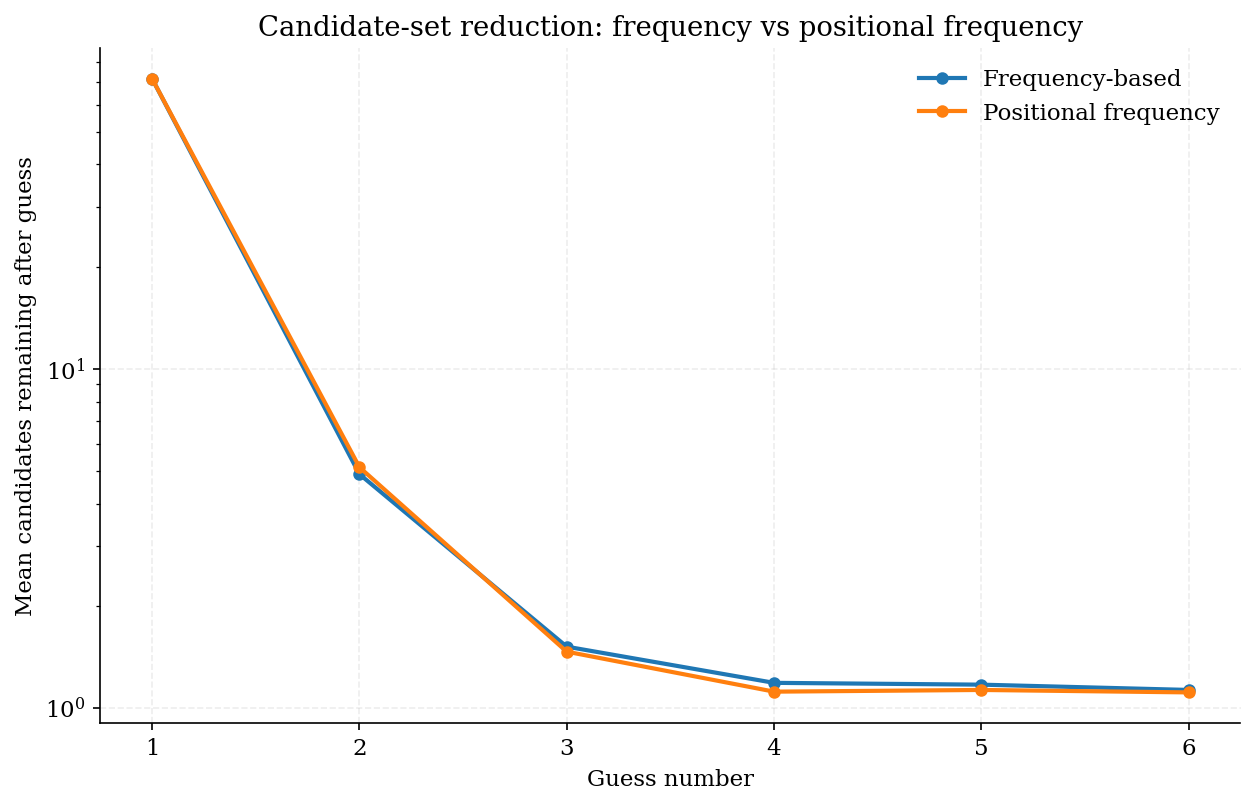

Saved figure to: figures\candidate_reduction_frequency_positional.png


In [98]:
from pathlib import Path

output_dir = Path("outputs")
figure_dir = Path("figures")

output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)
# ============================================================
# FIGURE 7:
# CANDIDATE-SET REDUCTION
# FREQUENCY VS POSITIONAL FREQUENCY
# ============================================================

fig, ax = plt.subplots(figsize=(8.5, 5.5))

for solver_name, group in (
    candidate_size_by_turn
    .sort_values("turn")
    .groupby("solver")
):
    ax.plot(
        group["turn"],
        group["mean_candidates_after"],
        marker="o",
        markersize=5,
        linewidth=2,
        label=solver_name
    )

ax.set_xlabel("Guess number")

ax.set_ylabel(
    "Mean candidates remaining after guess"
)

ax.set_title(
    "Candidate-set reduction: frequency vs positional frequency"
)

# Log scale is useful because the candidate set
# shrinks by orders of magnitude.
ax.set_yscale("log")

ax.set_xticks(range(1, 7))

ax.grid(
    axis="both",
    alpha=0.22,
    linestyle="--"
)

ax.legend(
    frameon=False,
    loc="upper right"
)

plt.tight_layout()

figure_path = (
    figure_dir
    / "candidate_reduction_frequency_positional.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved figure to: {figure_path}")

,solver,candidate_size_bin,mean_candidates,mean_decision_time_ms,observations
0,Frequency-based,"(-0.001, 1.0]",1.00,0.1409,1453
1,Frequency-based,"(1.0, 5.0]",3.06,0.2542,1889
2,Frequency-based,"(5.0, 10.0]",7.56,0.5175,622
3,Frequency-based,"(10.0, 25.0]",17.72,0.7853,613
4,Frequency-based,"(25.0, 50.0]",40.04,1.4131,423
5,Frequency-based,"(50.0, 100.0]",75.05,2.4645,575
6,Frequency-based,"(100.0, 250.0]",158.99,4.4790,611
7,Frequency-based,"(1000.0, 2500.0]",2315.00,61.9047,2315
8,Positional frequency,"(-0.001, 1.0]",1.00,0.1375,1509
9,Positional frequency,"(1.0, 5.0]",3.00,0.1731,1719


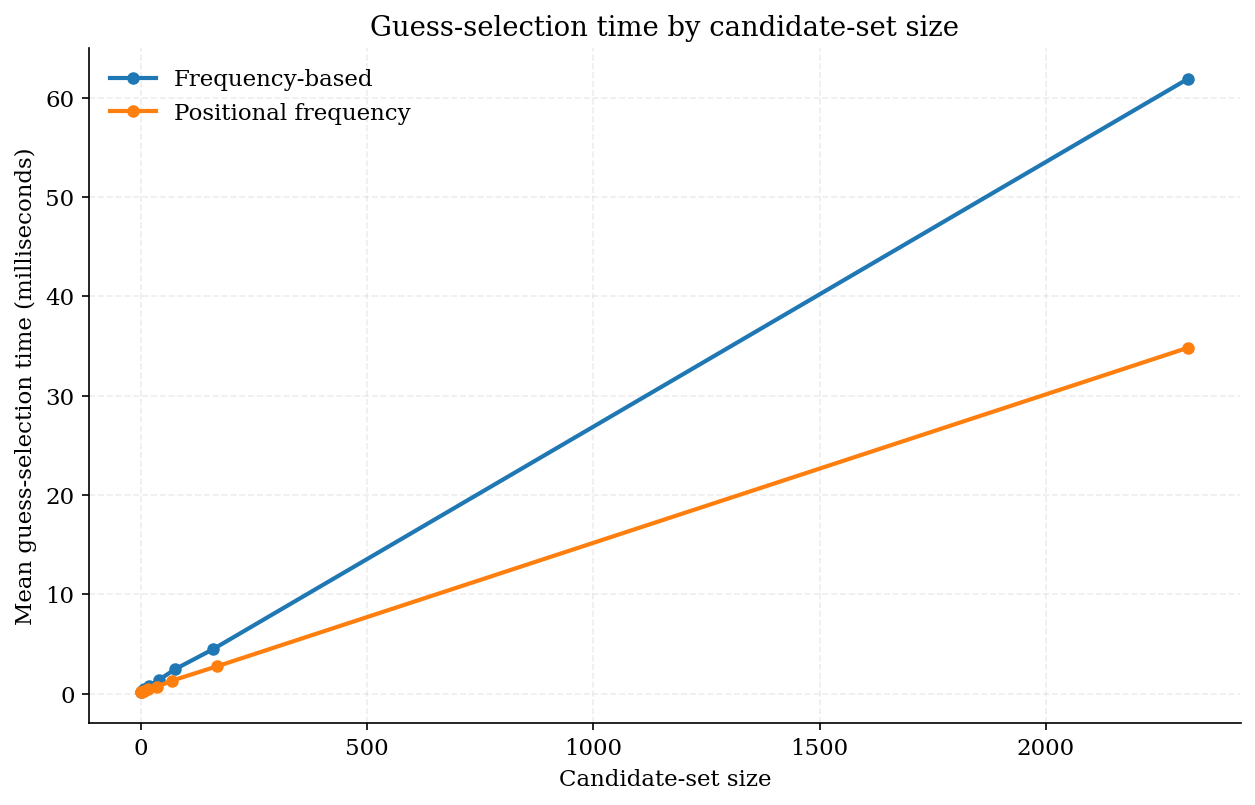

Saved figure to: C:\Users\tahmi\Downloads\MAML\figures\decision_time_by_candidate_size.png


In [99]:
# ============================================================
# PREPARE DATA FOR FIGURE 8:
# GUESS-SELECTION TIME BY CANDIDATE-SET SIZE
# ============================================================

timing_data = frequency_positional_turns.copy()

# Group candidate-set sizes into ranges.
timing_data["candidate_size_bin"] = pd.cut(
    timing_data["candidates_before"],
    bins=[
        0,
        1,
        5,
        10,
        25,
        50,
        100,
        250,
        500,
        1000,
        2500
    ],
    include_lowest=True
)

# Calculate mean candidate-set size and
# mean guess-selection time within each range.
decision_time_by_size = (
    timing_data
    .groupby(
        ["solver", "candidate_size_bin"],
        observed=True,
        as_index=False
    )
    .agg(
        mean_candidates=(
            "candidates_before",
            "mean"
        ),
        mean_decision_time_ms=(
            "decision_time_seconds",
            lambda values: values.mean() * 1000
        ),
        observations=(
            "solution",
            "count"
        )
    )
)

# Remove any invalid rows defensively.
decision_time_by_size = (
    decision_time_by_size
    .dropna(
        subset=[
            "mean_candidates",
            "mean_decision_time_ms"
        ]
    )
)

display(
    decision_time_by_size[
        [
            "solver",
            "candidate_size_bin",
            "mean_candidates",
            "mean_decision_time_ms",
            "observations"
        ]
    ].round({
        "mean_candidates": 2,
        "mean_decision_time_ms": 4
    })
)
# ============================================================
# FIGURE 8:
# GUESS-SELECTION TIME BY CANDIDATE-SET SIZE
# ============================================================

fig, ax = plt.subplots(figsize=(8.5, 5.5))

for solver_name, group in (
    decision_time_by_size
    .sort_values("mean_candidates")
    .groupby("solver")
):
    ax.plot(
        group["mean_candidates"],
        group["mean_decision_time_ms"],
        marker="o",
        markersize=5,
        linewidth=2,
        label=solver_name
    )

ax.set_xlabel("Candidate-set size")

ax.set_ylabel(
    "Mean guess-selection time (milliseconds)"
)

ax.set_title(
    "Guess-selection time by candidate-set size"
)

ax.grid(
    alpha=0.22,
    linestyle="--"
)

ax.legend(
    frameon=False,
    loc="upper left"
)

plt.tight_layout()

figure_path = (
    figure_dir
    / "decision_time_by_candidate_size.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved figure to: {figure_path.resolve()}")

## 10.5 Performance--Runtime Trade-off

This section compares the mean runtime and average guess count of all five
implemented solvers. The exact dynamic-programming result reported by
Bertsimas and Paskov is included as a performance benchmark, although its
runtime is not directly compared because it was obtained using a different
implementation and computing environment.

In [100]:
efficiency_rows = []

for solver_name, result in profiled_experiments.items():
    efficiency_rows.append({
        "Solver": solver_name,
        "Runtime per game (ms)": (
            result["runtime_seconds"]
            / result["num_games"]
            * 1000
        ),
        "Runtime per decision (ms)": (
            result["runtime_seconds"]
            / result["total_decisions"]
            * 1000
        ),
        "Solver-selection time per decision (ms)": (
            result["average_decision_time_seconds"]
            * 1000
        ),
        "Filtering time per decision (ms)": (
            result["average_filtering_time_seconds"]
            * 1000
        )
    })

runtime_efficiency_table = pd.DataFrame(efficiency_rows)

runtime_efficiency_table.round(4)

,Solver,Runtime per game (ms),Runtime per decision (ms),Solver-selection time per decision (ms),Filtering time per decision (ms)
0,First-candidate,124.0996,28.7405,0.0061,27.9642
1,Random,24.3372,5.9899,0.0076,5.7260
2,Frequency-based,15.0411,4.0960,1.4110,2.5771
3,Positional frequency,11.6730,3.2124,0.7423,2.3283
4,Approximate entropy,45.3182,12.8552,10.4664,2.2576


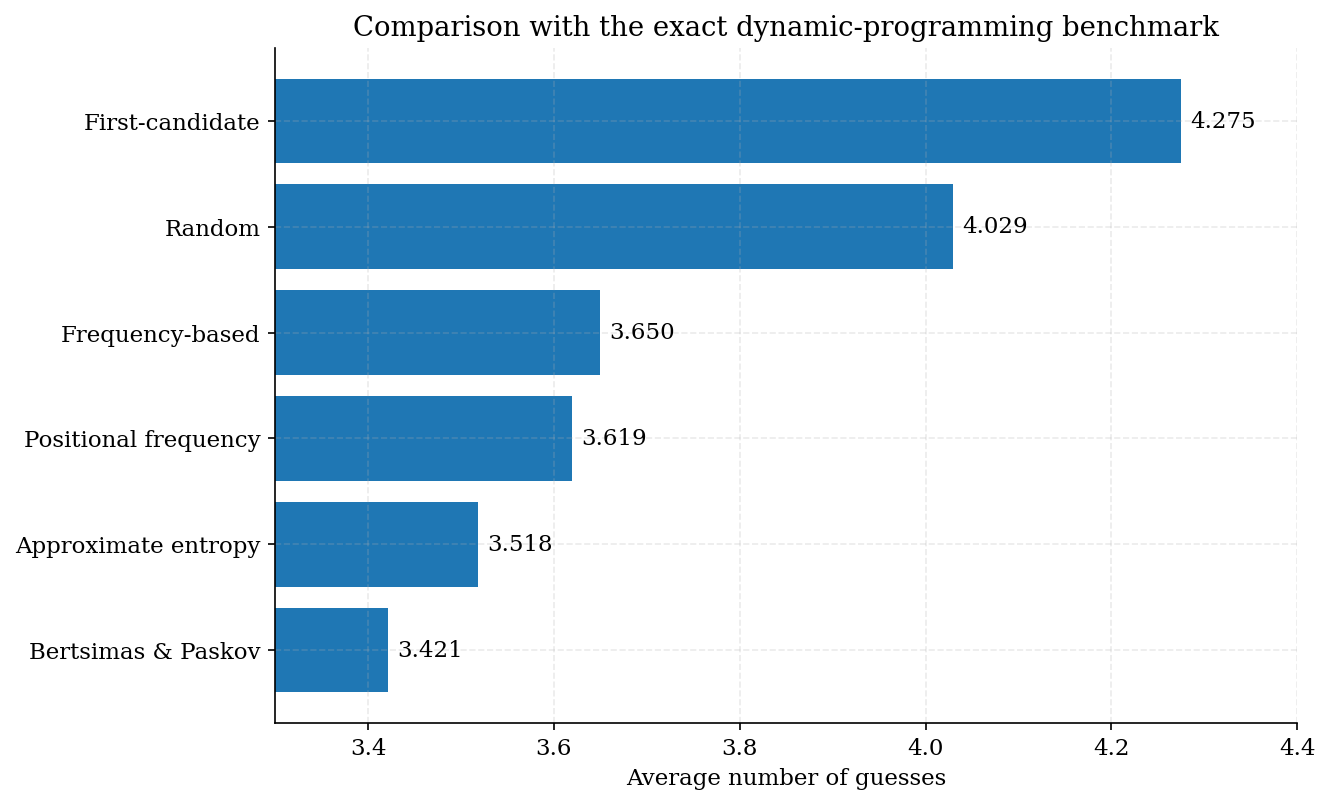

In [101]:
comparison_data = pd.DataFrame({
    "Method": [
        "First-candidate",
        "Random",
        "Frequency-based",
        "Positional frequency",
        "Approximate entropy",
        "Bertsimas & Paskov"
    ],
    "Average guesses": [
        4.275,
        4.029,
        3.650,
        3.619,
        3.518,
        3.421
    ]
})

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(
    comparison_data["Method"],
    comparison_data["Average guesses"]
)

ax.invert_yaxis()
ax.set_xlabel("Average number of guesses")
ax.set_title(
    "Comparison with the exact dynamic-programming benchmark"
)
ax.set_xlim(3.3, 4.4)

for bar, value in zip(
    bars,
    comparison_data["Average guesses"]
):
    ax.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    figure_dir / "comparison_with_bertsimas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 11. Overall Solver Comparison

This section combines the full experimental results for all five solver strategies into one summary table.

The table reproduces the main performance comparison reported in the dissertation, including:

- success rate;
- average guesses for solved games;
- number of unsolved games;
- runtime.

In [102]:
overall_results = pd.DataFrame([
    {
        "Solver": "First-candidate",
        "Success Rate": experiment_first_full["success_rate"],
        "Avg. Guesses": experiment_first_full["average_guesses_solved_only"],
        "Unsolved": experiment_first_full["num_unsolved"],
        "Runtime (s)": runtime_lookup["First-candidate"],
        "Runtime SD (s)": runtime_sd_lookup["First-candidate"]
    },
    {
        "Solver": "Random",
        "Success Rate": experiment_random_full["success_rate"],
        "Avg. Guesses": experiment_random_full["average_guesses_solved_only"],
        "Unsolved": experiment_random_full["num_unsolved"],
        "Runtime (s)": runtime_lookup["Random"],
        "Runtime SD (s)": runtime_sd_lookup["Random"]
    },
    {
        "Solver": "Frequency-based",
        "Success Rate": experiment_frequency_full["success_rate"],
        "Avg. Guesses": experiment_frequency_full["average_guesses_solved_only"],
        "Unsolved": experiment_frequency_full["num_unsolved"],
        "Runtime (s)": runtime_lookup["Frequency-based"],
        "Runtime SD (s)": runtime_sd_lookup["Frequency-based"]
    },
    {
        "Solver": "Positional frequency",
        "Success Rate": experiment_positional_full["success_rate"],
        "Avg. Guesses": experiment_positional_full["average_guesses_solved_only"],
        "Unsolved": experiment_positional_full["num_unsolved"],
        "Runtime (s)": runtime_lookup["Positional frequency"],
        "Runtime SD (s)": runtime_sd_lookup["Positional frequency"]
    },
    {
        "Solver": "Entropy",
        "Success Rate": experiment_entropy_full["success_rate"],
        "Avg. Guesses": experiment_entropy_full["average_guesses_solved_only"],
        "Unsolved": experiment_entropy_full["num_unsolved"],
        "Runtime (s)": runtime_lookup["Entropy"],
        "Runtime SD (s)": runtime_sd_lookup["Entropy"]
    }
])

In [103]:
overall_results_formatted = overall_results.copy()

overall_results_formatted["Success Rate"] = (
    overall_results_formatted["Success Rate"] * 100
).map(lambda x: f"{x:.1f}%")

overall_results_formatted["Avg. Guesses"] = (
    overall_results_formatted["Avg. Guesses"]
    .map(lambda x: f"{x:.3f}")
)

overall_results_formatted["Runtime"] = (
    overall_results_formatted.apply(
        lambda row: (
            f"{row['Runtime (s)']:.2f} "
            f"± {row['Runtime SD (s)']:.2f}"
        ),
        axis=1
    )
)

overall_results_formatted = overall_results_formatted[
    [
        "Solver",
        "Success Rate",
        "Avg. Guesses",
        "Unsolved",
        "Runtime"
    ]
]

overall_results_formatted

,Solver,Success Rate,Avg. Guesses,Unsolved,Runtime
0,First-candidate,97.5%,4.275,58,43.99 ± 1.12
1,Random,98.3%,4.029,40,42.10 ± 0.72
2,Frequency-based,99.0%,3.650,22,58.86 ± 1.02
3,Positional frequency,99.4%,3.619,14,49.75 ± 0.28
4,Entropy,99.7%,3.518,7,459.41 ± 433.94


In [104]:
# Create sets of unsolved words for each solver

failed_first = {
    r["solution"]
    for r in experiment_first_full["results"]
    if not r["solved"]
}

failed_random = {
    r["solution"]
    for r in experiment_random_full["results"]
    if not r["solved"]
}

failed_frequency = {
    r["solution"]
    for r in experiment_frequency_full["results"]
    if not r["solved"]
}

failed_positional = {
    r["solution"]
    for r in experiment_positional_full["results"]
    if not r["solved"]
}

failed_entropy = {
    r["solution"]
    for r in experiment_entropy_full["results"]
    if not r["solved"]
}

print("Number of failures")
print("-" * 40)
print("First-candidate:", len(failed_first))
print("Random:", len(failed_random))
print("Frequency-based:", len(failed_frequency))
print("Positional frequency:", len(failed_positional))
print("Entropy:", len(failed_entropy))

Number of failures
----------------------------------------
First-candidate: 58
Random: 40
Frequency-based: 22
Positional frequency: 14
Entropy: 7


In [105]:
# Pairwise overlap counts

failure_overlap_summary = pd.DataFrame([
    {
        "Comparison": "First-candidate vs Random",
        "Common failures": len(failed_first & failed_random),
        "Unique to first solver": len(failed_first - failed_random),
        "Unique to second solver": len(failed_random - failed_first)
    },
    {
        "Comparison": "Frequency-based vs Positional frequency",
        "Common failures": len(failed_frequency & failed_positional),
        "Unique to first solver": len(failed_frequency - failed_positional),
        "Unique to second solver": len(failed_positional - failed_frequency)
    },
    {
        "Comparison": "Positional frequency vs Entropy",
        "Common failures": len(failed_positional & failed_entropy),
        "Unique to first solver": len(failed_positional - failed_entropy),
        "Unique to second solver": len(failed_entropy - failed_positional)
    }
])

failure_overlap_summary

,Comparison,Common failures,Unique to first solver,Unique to second solver
0,First-candidate vs Random,5,53,35
1,Frequency-based vs Positional frequency,7,15,7
2,Positional frequency vs Entropy,5,9,2


In [106]:
# Exact words for baseline overlap

baseline_common_failures = sorted(failed_first & failed_random)
only_first_failures = sorted(failed_first - failed_random)
only_random_failures = sorted(failed_random - failed_first)

print("Common failures: First-candidate and Random")
print(baseline_common_failures)

print("\nUnique to First-candidate")
print(only_first_failures)

print("\nUnique to Random")
print(only_random_failures)

Common failures: First-candidate and Random
['rower', 'savvy', 'slave', 'spine', 'stove']

Unique to First-candidate
['bunny', 'burly', 'bushy', 'chart', 'craze', 'crowd', 'drown', 'graze', 'grout', 'grown', 'jazzy', 'mammy', 'naive', 'ovine', 'parer', 'pasty', 'patty', 'riper', 'rover', 'safer', 'saner', 'savoy', 'scary', 'smile', 'sound', 'stack', 'stake', 'swear', 'swell', 'swine', 'taint', 'tally', 'taste', 'tasty', 'tatty', 'taunt', 'tight', 'tower', 'vaunt', 'verve', 'viral', 'voice', 'wafer', 'waive', 'waste', 'watch', 'waver', 'wheat', 'wight', 'wiser', 'wooer', 'wound', 'wrack']

Unique to Random
['alloy', 'blaze', 'bring', 'caddy', 'count', 'dally', 'dense', 'fiber', 'finer', 'frame', 'fuzzy', 'gamer', 'grade', 'hilly', 'hover', 'jaunt', 'kinky', 'might', 'miser', 'mower', 'nanny', 'ninny', 'paddy', 'patch', 'pinch', 'price', 'proxy', 'saint', 'shape', 'skate', 'stare', 'stunt', 'sully', 'willy', 'wreak']


In [107]:
# Exact words for positional and entropy overlap

positional_entropy_common_failures = sorted(failed_positional & failed_entropy)
only_positional_vs_entropy_failures = sorted(failed_positional - failed_entropy)
only_entropy_failures = sorted(failed_entropy - failed_positional)

print("Common failures: Positional frequency and Entropy")
print(positional_entropy_common_failures)

print("\nUnique to Positional frequency")
print(only_positional_vs_entropy_failures)

print("\nUnique to Entropy")
print(only_entropy_failures)

Common failures: Positional frequency and Entropy
['pound', 'vaunt', 'waste', 'watch', 'wound']

Unique to Positional frequency
['homer', 'joker', 'match', 'roger', 'shave', 'stash', 'tatty', 'wight', 'willy']

Unique to Entropy
['foyer', 'patch']


In [108]:
# Words failed by all solvers

failed_by_all_solvers = sorted(
    failed_first
    & failed_random
    & failed_frequency
    & failed_positional
    & failed_entropy
)

print("Words failed by every solver:", len(failed_by_all_solvers))
print(failed_by_all_solvers)

Words failed by every solver: 0
[]


In [109]:
# Entropy failures specifically

entropy_failure_table = pd.DataFrame({
    "Entropy failures": sorted(failed_entropy)
})

entropy_failure_table

,Entropy failures
0,foyer
1,patch
2,pound
3,vaunt
4,waste
5,watch
6,wound


In [110]:
# Full failure-membership table

all_failure_words = sorted(
    failed_first
    | failed_random
    | failed_frequency
    | failed_positional
    | failed_entropy
)

failure_membership_table = pd.DataFrame([
    {
        "Word": word,
        "First-candidate": word in failed_first,
        "Random": word in failed_random,
        "Frequency-based": word in failed_frequency,
        "Positional frequency": word in failed_positional,
        "Entropy": word in failed_entropy,
        "Number of solvers failed": sum([
            word in failed_first,
            word in failed_random,
            word in failed_frequency,
            word in failed_positional,
            word in failed_entropy
        ])
    }
    for word in all_failure_words
])

failure_membership_table.sort_values(
    by=["Number of solvers failed", "Word"],
    ascending=[False, True]
)

,Word,First-candidate,Random,Frequency-based,Positional frequency,Entropy,Number of solvers failed
93,vaunt,True,False,True,True,True,4
109,wound,True,False,True,True,True,4
53,pound,False,False,True,True,True,3
89,tatty,True,False,True,True,False,3
99,waste,True,False,False,True,True,3
...,...,...,...,...,...,...,...
106,witty,False,False,True,False,False,1
107,wooer,True,False,False,False,False,1
108,wooly,False,False,True,False,False,1
110,wrack,True,False,False,False,False,1


In [111]:
# Optional: save failure analysis outputs

failure_overlap_summary.to_csv(output_dir / "failure_overlap_summary.csv", index=False)
failure_membership_table.to_csv(output_dir / "failure_membership_table.csv", index=False)
entropy_failure_table.to_csv(output_dir / "entropy_failures.csv", index=False)

print("Failure analysis tables saved.")

Failure analysis tables saved.


# 12. Failure and Hard-Case Analysis

The report examines the words that were not solved within six guesses and the cases that required the maximum number of guesses.

This analysis helps identify where simple baseline methods struggle. In particular, hard cases often involve structurally similar candidate words or repeated letters, where candidate filtering alone may reduce the search space too slowly.

In [112]:
first_failures = [
    result for result in experiment_first_full["results"]
    if not result["solved"]
]

random_failures = [
    result for result in experiment_random_full["results"]
    if not result["solved"]
]

frequency_failures = [
    result for result in experiment_frequency_full["results"]
    if not result["solved"]
]

positional_failures = [
    result for result in experiment_positional_full["results"]
    if not result["solved"]
]

entropy_failures = [
    result for result in experiment_entropy_full["results"]
    if not result["solved"]
]

failure_summary = pd.DataFrame([
    {"Solver": "First-candidate", "Unsolved": len(first_failures)},
    {"Solver": "Random", "Unsolved": len(random_failures)},
    {"Solver": "Frequency-based", "Unsolved": len(frequency_failures)},
    {"Solver": "Positional frequency", "Unsolved": len(positional_failures)},
    {"Solver": "Entropy", "Unsolved": len(entropy_failures)}
])

failure_summary

,Solver,Unsolved
0,First-candidate,58
1,Random,40
2,Frequency-based,22
3,Positional frequency,14
4,Entropy,7


In [113]:
first_six_guess_cases = [
    result for result in experiment_first_full["results"]
    if result["solved"] and result["num_guesses"] == 6
]

print("Number of six-guess cases for first-candidate solver:", len(first_six_guess_cases))

hard_case_examples = [
    result["solution"]
    for result in first_six_guess_cases[:10]
]

hard_case_examples

Number of six-guess cases for first-candidate solver: 210


['armor',
 'arson',
 'ashen',
 'augur',
 'baton',
 'bliss',
 'boozy',
 'bossy',
 'budge',
 'bully']

In [114]:
hard_case_table = pd.DataFrame([
    {
        "Solution": result["solution"],
        "Guesses": ", ".join(result["guesses"]),
        "Number of guesses": result["num_guesses"]
    }
    for result in first_six_guess_cases[:10]
])

hard_case_table

,Solution,Guesses,Number of guesses
0,armor,"aback, adept, affix, aglow, annoy, armor",6
1,arson,"aback, adept, affix, aglow, annoy, arson",6
2,ashen,"aback, adept, afire, alley, annex, ashen",6
3,augur,"aback, adept, affix, aglow, angry, augur",6
4,baton,"aback, badge, balmy, banjo, baron, baton",6
5,bliss,"aback, beefy, bigot, blimp, blind, bliss",6
6,boozy,"aback, beefy, biddy, bobby, booty, boozy",6
7,bossy,"aback, beefy, biddy, bobby, booty, bossy",6
8,budge,"aback, beefy, bible, booze, brute, budge",6
9,bully,"aback, beefy, biddy, bobby, buggy, bully",6


In [115]:
import pandas as pd

# ------------------------------------------------------------
# Build solver success table
# ------------------------------------------------------------

solver_results = {
    "First-candidate": experiment_first_full,
    "Random": experiment_random_full,
    "Frequency-based": experiment_frequency_full,
    "Positional": experiment_positional_full,
    "Entropy": experiment_entropy_full,
}

failure_table = pd.DataFrame()

for solver_name, experiment in solver_results.items():

    df = pd.DataFrame(experiment["results"])[
        ["solution", "solved", "num_guesses"]
    ].rename(
        columns={
            "solved": solver_name,
            "num_guesses": f"{solver_name} guesses"
        }
    )

    if failure_table.empty:
        failure_table = df
    else:
        failure_table = failure_table.merge(
            df,
            on="solution"
        )

# ------------------------------------------------------------
# Count how many solvers succeeded
# ------------------------------------------------------------

solver_columns = [
    "First-candidate",
    "Random",
    "Frequency-based",
    "Positional",
    "Entropy",
]

failure_table["Solved by"] = (
    failure_table[solver_columns]
    .sum(axis=1)
)

failure_table["Failed by"] = (
    len(solver_columns)
    - failure_table["Solved by"]
)

# ------------------------------------------------------------
# Create readable failure list
# ------------------------------------------------------------

def failed_solvers(row):

    failed = []

    for solver in solver_columns:
        if not row[solver]:
            failed.append(solver)

    if len(failed) == 0:
        return "None"

    return ", ".join(failed)

failure_table["Failed solvers"] = (
    failure_table.apply(
        failed_solvers,
        axis=1
    )
)

# ------------------------------------------------------------
# Keep only words missed by at least one solver
# ------------------------------------------------------------

hard_words = (
    failure_table[
        failure_table["Failed by"] > 0
    ]
    .sort_values(
        ["Solved by", "solution"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

display(
    hard_words[
        [
            "solution",
            "Solved by",
            "Failed solvers"
        ]
    ]
)

print()

print("Words missed by at least one solver:",
      len(hard_words))

,solution,Solved by,Failed solvers
0,vaunt,1,"First-candidate, Frequency-based, Positional, ..."
1,wound,1,"First-candidate, Frequency-based, Positional, ..."
2,pound,2,"Frequency-based, Positional, Entropy"
3,tatty,2,"First-candidate, Frequency-based, Positional"
4,waste,2,"First-candidate, Positional, Entropy"
...,...,...,...
107,witty,4,Frequency-based
108,wooer,4,First-candidate
109,wooly,4,Frequency-based
110,wrack,4,First-candidate



Words missed by at least one solver: 112


In [116]:
summary_table = hard_words[
    [
        "solution",
        "Solved by",
        "Failed solvers"
    ]
].rename(
    columns={
        "solution":"Target word"
    }
)

summary_table.head(15)
summary_table.to_csv(
    output_dir / "hard_case_summary.csv",
    index=False
)

In [117]:
top_hardest = (
    summary_table
    .sort_values("Solved by")
    .head(15)
)

display(top_hardest)

,Target word,Solved by,Failed solvers
0,vaunt,1,"First-candidate, Frequency-based, Positional, ..."
1,wound,1,"First-candidate, Frequency-based, Positional, ..."
2,pound,2,"Frequency-based, Positional, Entropy"
3,tatty,2,"First-candidate, Frequency-based, Positional"
4,waste,2,"First-candidate, Positional, Entropy"
5,watch,2,"First-candidate, Positional, Entropy"
6,willy,2,"Random, Frequency-based, Positional"
7,foyer,3,"Frequency-based, Entropy"
8,patch,3,"Random, Entropy"
9,rower,3,"First-candidate, Random"


### Structural Analysis of Overlapping Failure Cases

This analysis investigates why some words are failed by multiple solvers. It
examines whether difficult words contain repeated letters or belong to dense
word families containing several one-letter neighbours.

A one-letter neighbour is defined as another solution word that differs in
exactly one position. Words with many such neighbours may be difficult because
several structurally similar candidates can remain feasible late in the game.

In [118]:
from collections import Counter


def has_repeated_letters(word: str) -> bool:
    """Return True if the word contains at least one repeated letter."""
    return len(set(word)) < len(word)


def repeated_letter_count(word: str) -> int:
    """Return the number of repeated letter occurrences beyond the first."""
    counts = Counter(word)

    return sum(
        count - 1
        for count in counts.values()
        if count > 1
    )


def hamming_distance(word_a: str, word_b: str) -> int:
    """Count the positions at which two equal-length words differ."""
    return sum(
        letter_a != letter_b
        for letter_a, letter_b in zip(word_a, word_b)
    )


def one_letter_neighbours(
    word: str,
    word_list: list[str]
) -> list[str]:
    """Return solution words that differ from `word` in exactly one position."""
    return [
        candidate
        for candidate in word_list
        if candidate != word
        and hamming_distance(word, candidate) == 1
    ]


def vowel_count(word: str) -> int:
    """Count the vowels in a word."""
    return sum(letter in "aeiou" for letter in word)

In [119]:
failure_structural_analysis = failure_membership_table.copy()

failure_structural_analysis["Has repeated letters"] = (
    failure_structural_analysis["Word"]
    .apply(has_repeated_letters)
)

failure_structural_analysis["Repeated letter count"] = (
    failure_structural_analysis["Word"]
    .apply(repeated_letter_count)
)

failure_structural_analysis["Unique letters"] = (
    failure_structural_analysis["Word"]
    .apply(lambda word: len(set(word)))
)

failure_structural_analysis["Vowel count"] = (
    failure_structural_analysis["Word"]
    .apply(vowel_count)
)

failure_structural_analysis["Neighbour words"] = (
    failure_structural_analysis["Word"]
    .apply(lambda word: one_letter_neighbours(word, solutions))
)

failure_structural_analysis["One-letter neighbours"] = (
    failure_structural_analysis["Neighbour words"]
    .apply(len)
)

failure_structural_analysis["Neighbour words"] = (
    failure_structural_analysis["Neighbour words"]
    .apply(lambda words: ", ".join(words))
)

failure_structural_analysis.head()

,Word,First-candidate,Random,Frequency-based,Positional frequency,Entropy,Number of solvers failed,Has repeated letters,Repeated letter count,Unique letters,Vowel count,Neighbour words,One-letter neighbours
0,alloy,False,True,False,False,False,1,True,1,4,2,"allay, alley, allot, allow",4
1,blaze,False,True,False,False,False,1,False,0,5,2,"blade, blame, blare, glaze",4
2,bring,False,True,False,False,False,1,False,0,5,1,"being, brine, brink, briny, wring",5
3,bunny,True,False,False,False,False,1,True,1,4,1,"funny, sunny",2
4,burly,True,False,False,False,False,1,False,0,5,1,"bully, curly, surly",3


In [120]:
overlapping_failure_analysis = (
    failure_structural_analysis[
        failure_structural_analysis["Number of solvers failed"] >= 2
    ]
    [
        [
            "Word",
            "Number of solvers failed",
            "First-candidate",
            "Random",
            "Frequency-based",
            "Positional frequency",
            "Entropy",
            "Has repeated letters",
            "Repeated letter count",
            "Unique letters",
            "Vowel count",
            "One-letter neighbours",
            "Neighbour words"
        ]
    ]
    .sort_values(
        by=[
            "Number of solvers failed",
            "One-letter neighbours",
            "Repeated letter count"
        ],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

overlapping_failure_analysis

,Word,Number of solvers failed,First-candidate,Random,Frequency-based,Positional frequency,Entropy,Has repeated letters,Repeated letter count,Unique letters,Vowel count,One-letter neighbours,Neighbour words
0,wound,4,True,False,True,True,True,False,0,5,2,8,"bound, found, hound, mound, pound, round, soun..."
1,vaunt,4,True,False,True,True,True,False,0,5,2,6,"daunt, gaunt, haunt, jaunt, taunt, vault"
2,pound,3,False,False,True,True,True,False,0,5,2,7,"bound, found, hound, mound, round, sound, wound"
3,watch,3,True,False,False,True,True,False,0,5,1,7,"batch, catch, hatch, latch, match, patch, witch"
4,tatty,3,True,False,True,True,False,True,2,3,1,6,"batty, catty, fatty, patty, ratty, tasty"
5,willy,3,False,True,True,True,False,True,1,4,1,5,"billy, dilly, filly, hilly, silly"
6,waste,3,True,False,False,True,True,False,0,5,2,5,"baste, caste, haste, paste, taste"
7,shave,2,False,False,True,True,False,False,0,5,2,10,"shade, shake, shale, shame, shape, share, shov..."
8,rower,2,True,True,False,False,False,True,1,4,2,8,"cower, lower, mower, power, roger, rover, sowe..."
9,tight,2,True,False,True,False,False,True,1,4,1,8,"eight, fight, light, might, night, right, sigh..."


In [121]:
maximum_failures = (
    failure_structural_analysis["Number of solvers failed"].max()
)

most_shared_failures = (
    failure_structural_analysis[
        failure_structural_analysis["Number of solvers failed"]
        == maximum_failures
    ]
    [
        [
            "Word",
            "Number of solvers failed",
            "Has repeated letters",
            "One-letter neighbours",
            "Neighbour words"
        ]
    ]
    .reset_index(drop=True)
)

most_shared_failures

,Word,Number of solvers failed,Has repeated letters,One-letter neighbours,Neighbour words
0,vaunt,4,False,6,"daunt, gaunt, haunt, jaunt, taunt, vault"
1,wound,4,False,8,"bound, found, hound, mound, pound, round, soun..."


In [122]:
all_word_structure = pd.DataFrame({
    "Word": solutions
})

all_word_structure["Has repeated letters"] = (
    all_word_structure["Word"]
    .apply(has_repeated_letters)
)

all_word_structure["Repeated letter count"] = (
    all_word_structure["Word"]
    .apply(repeated_letter_count)
)

all_word_structure["Unique letters"] = (
    all_word_structure["Word"]
    .apply(lambda word: len(set(word)))
)

all_word_structure["Vowel count"] = (
    all_word_structure["Word"]
    .apply(vowel_count)
)

all_word_structure["One-letter neighbours"] = (
    all_word_structure["Word"]
    .apply(
        lambda word: len(
            one_letter_neighbours(word, solutions)
        )
    )
)

In [123]:
def summarise_group(
    table: pd.DataFrame,
    group_name: str
) -> dict:
    """Summarise structural properties for a group of words."""
    return {
        "Group": group_name,
        "Number of words": len(table),
        "Repeated letters (%)": (
            table["Has repeated letters"].mean() * 100
        ),
        "Mean repeated-letter count": (
            table["Repeated letter count"].mean()
        ),
        "Mean unique letters": (
            table["Unique letters"].mean()
        ),
        "Mean vowels": (
            table["Vowel count"].mean()
        ),
        "Mean one-letter neighbours": (
            table["One-letter neighbours"].mean()
        )
    }


structural_failure_summary = pd.DataFrame([
    summarise_group(
        all_word_structure,
        "All solution words"
    ),
    summarise_group(
        failure_structural_analysis,
        "Failed by at least one solver"
    ),
    summarise_group(
        failure_structural_analysis[
            failure_structural_analysis["Number of solvers failed"] >= 2
        ],
        "Failed by at least two solvers"
    ),
    summarise_group(
        failure_structural_analysis[
            failure_structural_analysis["Number of solvers failed"] >= 3
        ],
        "Failed by at least three solvers"
    ),
    summarise_group(
        failure_structural_analysis[
            failure_structural_analysis["Number of solvers failed"] >= 4
        ],
        "Failed by four solvers"
    )
])

structural_failure_summary

,Group,Number of words,Repeated letters (%),Mean repeated-letter count,Mean unique letters,Mean vowels,Mean one-letter neighbours
0,All solution words,2315,32.354212,0.349028,4.650972,1.772786,2.222030
1,Failed by at least one solver,112,38.392857,0.446429,4.553571,1.625000,4.276786
2,Failed by at least two solvers,20,40.000000,0.450000,4.550000,1.600000,6.000000
3,Failed by at least three solvers,7,28.571429,0.428571,4.571429,1.571429,6.285714
4,Failed by four solvers,2,0.000000,0.000000,5.000000,2.000000,7.000000


In [124]:
entropy_failure_structural_analysis = (
    failure_structural_analysis[
        failure_structural_analysis["Entropy"]
    ]
    [
        [
            "Word",
            "Number of solvers failed",
            "Has repeated letters",
            "Repeated letter count",
            "Unique letters",
            "Vowel count",
            "One-letter neighbours",
            "Neighbour words"
        ]
    ]
    .sort_values(
        by=[
            "Number of solvers failed",
            "One-letter neighbours"
        ],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

entropy_failure_structural_analysis

,Word,Number of solvers failed,Has repeated letters,Repeated letter count,Unique letters,Vowel count,One-letter neighbours,Neighbour words
0,wound,4,False,0,5,2,8,"bound, found, hound, mound, pound, round, soun..."
1,vaunt,4,False,0,5,2,6,"daunt, gaunt, haunt, jaunt, taunt, vault"
2,pound,3,False,0,5,2,7,"bound, found, hound, mound, round, sound, wound"
3,watch,3,False,0,5,1,7,"batch, catch, hatch, latch, match, patch, witch"
4,waste,3,False,0,5,2,5,"baste, caste, haste, paste, taste"
5,patch,2,False,0,5,1,7,"batch, catch, hatch, latch, match, pitch, watch"
6,foyer,2,False,0,5,2,1,flyer


In [125]:
failure_structural_analysis.to_csv(
    output_dir / "failure_structural_analysis.csv",
    index=False
)

overlapping_failure_analysis.to_csv(
    output_dir / "overlapping_failure_structural_analysis.csv",
    index=False
)

structural_failure_summary.to_csv(
    output_dir / "structural_failure_summary.csv",
    index=False
)

entropy_failure_structural_analysis.to_csv(
    output_dir / "entropy_failure_structural_analysis.csv",
    index=False
)

print("Saved structural failure-analysis outputs.")

Saved structural failure-analysis outputs.


# 13. Statistical Comparison of Solver Performance

Paired Wilcoxon signed-rank tests are used to compare successive solver strategies.

The paired design is appropriate because each solver is evaluated on the same set of 2,315 target words. The tests compare the number of guesses required for each solution word.

For statistical testing, unsolved games are assigned a value of 7. This penalises failures beyond the six-guess limit while preserving the paired structure of the data.

In [126]:
def guess_vector(experiment: dict, failure_value: int = 7) -> list[int]:
    """
    Convert per-game results into a vector of guess counts.

    Solved games use their actual number of guesses.
    Unsolved games are assigned `failure_value`.
    """
    return [
        result["num_guesses"] if result["solved"] else failure_value
        for result in experiment["results"]
    ]

In [127]:
first_vector = guess_vector(experiment_first_full)
random_vector = guess_vector(experiment_random_full)
frequency_vector = guess_vector(experiment_frequency_full)
positional_vector = guess_vector(experiment_positional_full)
entropy_vector = guess_vector(experiment_entropy_full)

In [128]:
wilcoxon_random_frequency = wilcoxon(random_vector, frequency_vector)
wilcoxon_frequency_positional = wilcoxon(frequency_vector, positional_vector)
wilcoxon_positional_entropy = wilcoxon(positional_vector, entropy_vector)

print("Random vs Frequency")
print("Statistic:", wilcoxon_random_frequency.statistic)
print("p-value:", wilcoxon_random_frequency.pvalue)

print("\nFrequency vs Positional")
print("Statistic:", wilcoxon_frequency_positional.statistic)
print("p-value:", wilcoxon_frequency_positional.pvalue)

print("\nPositional vs Entropy")
print("Statistic:", wilcoxon_positional_entropy.statistic)
print("p-value:", wilcoxon_positional_entropy.pvalue)

Random vs Frequency
Statistic: 374662.0
p-value: 7.948077461634365e-49

Frequency vs Positional
Statistic: 435390.0
p-value: 0.05341527323098344

Positional vs Entropy
Statistic: 165161.5
p-value: 2.1616190290372905e-12


In [129]:
wilcoxon_results = pd.DataFrame([
    {
        "Comparison": "Random vs Frequency",
        "Statistic": wilcoxon_random_frequency.statistic,
        "p-value": wilcoxon_random_frequency.pvalue,
        "Significant at 5%": wilcoxon_random_frequency.pvalue < 0.05
    },
    {
        "Comparison": "Frequency vs Positional",
        "Statistic": wilcoxon_frequency_positional.statistic,
        "p-value": wilcoxon_frequency_positional.pvalue,
        "Significant at 5%": wilcoxon_frequency_positional.pvalue < 0.05
    },
    {
        "Comparison": "Positional vs Entropy",
        "Statistic": wilcoxon_positional_entropy.statistic,
        "p-value": wilcoxon_positional_entropy.pvalue,
        "Significant at 5%": wilcoxon_positional_entropy.pvalue < 0.05
    }
])

wilcoxon_results

,Comparison,Statistic,p-value,Significant at 5%
0,Random vs Frequency,374662.0,7.948077e-49,True
1,Frequency vs Positional,435390.0,5.341527e-02,False
2,Positional vs Entropy,165161.5,2.161619e-12,True


# 14. Final Summary Table

The final summary table combines solver performance metrics with the statistical comparison reported in the dissertation.

The column labelled `Statistical improvement` indicates whether the improvement over the preceding main comparison was statistically significant at the 5% level.

In [130]:
final_summary_table = overall_results.copy()

final_summary_table["Statistical improvement"] = [
    "—",
    "—",
    "Yes",
    "No",
    "Yes"
]

final_summary_table_formatted = final_summary_table.copy()

final_summary_table_formatted["Success Rate"] = (
    final_summary_table_formatted["Success Rate"] * 100
).map(lambda x: f"{x:.1f}%")

final_summary_table_formatted["Avg. Guesses"] = final_summary_table_formatted["Avg. Guesses"].map(
    lambda x: f"{x:.3f}"
)

final_summary_table_formatted["Runtime (s)"] = final_summary_table_formatted["Runtime (s)"].map(
    lambda x: f"{x:.2f}"
)

final_summary_table_formatted

,Solver,Success Rate,Avg. Guesses,Unsolved,Runtime (s),Runtime SD (s),Statistical improvement
0,First-candidate,97.5%,4.275,58,43.99,1.119185,—
1,Random,98.3%,4.029,40,42.10,0.717408,—
2,Frequency-based,99.0%,3.650,22,58.86,1.016929,Yes
3,Positional frequency,99.4%,3.619,14,49.75,0.283934,No
4,Entropy,99.7%,3.518,7,459.41,433.942994,Yes


# 15. Report Figures and Saved Outputs

This section reproduces the figures and output files used in the dissertation. All figures are generated directly from the full experimental results, ensuring that the notebook can reproduce the reported tables, visualisations and statistical outputs.

In [131]:
from pathlib import Path
from collections import Counter

output_dir = Path("outputs")
figure_dir = Path("figures")

output_dir.mkdir(exist_ok=True)
figure_dir.mkdir(exist_ok=True)

print("Output directory:", output_dir.resolve())
print("Figure directory:", figure_dir.resolve())

Output directory: C:\Users\tahmi\Downloads\MAML\outputs
Figure directory: C:\Users\tahmi\Downloads\MAML\figures


## 15.1 One-Guess Validation

The first-candidate solver always selects the first remaining candidate word. Since `aback` is the first word in the ordered solution list, the first-candidate solver should solve this target in one guess. This check confirms that the one-guess case shown in the baseline distribution is present in the experiment output.

In [132]:
first_one_guess_cases = [
    result["solution"]
    for result in experiment_first_full["results"]
    if result["solved"] and result["num_guesses"] == 1
]

random_one_guess_cases = [
    result["solution"]
    for result in experiment_random_full["results"]
    if result["solved"] and result["num_guesses"] == 1
]

print("First-candidate one-guess cases:", len(first_one_guess_cases))
print(first_one_guess_cases)

print("\nRandom one-guess cases:", len(random_one_guess_cases))
print(random_one_guess_cases)

First-candidate one-guess cases: 1
['aback']

Random one-guess cases: 0
[]


# 15.2 Example Wordle Game
This figure illustrates a complete example Wordle game and is reproduced exactly as it appears in Chapter 2.

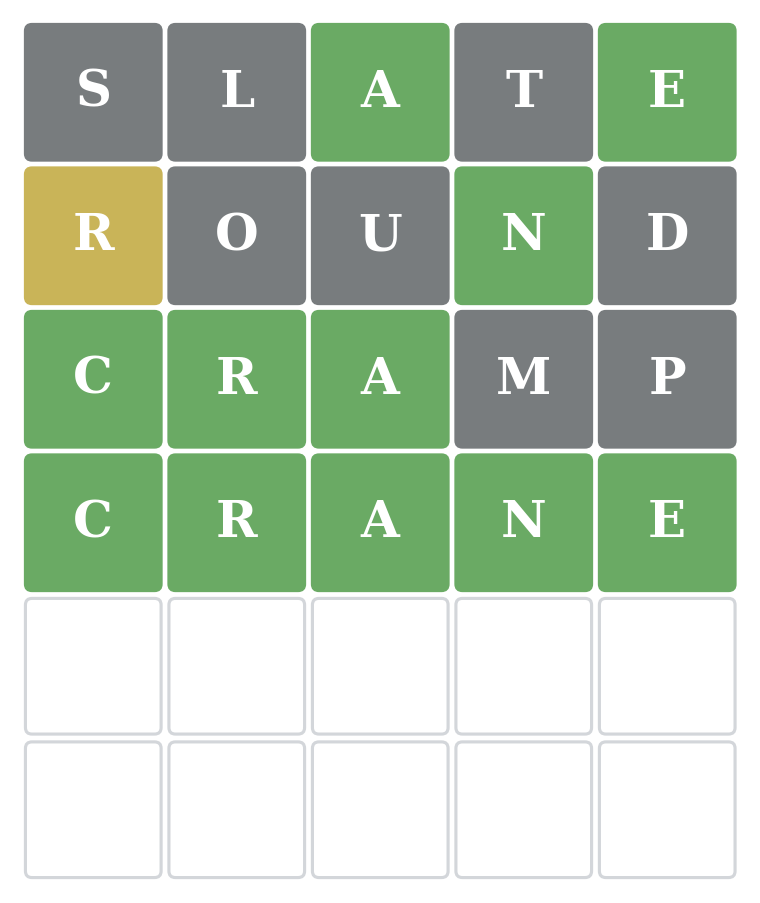

In [133]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from pathlib import Path
from collections import Counter

figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)

COLOURS = {
    "green": "#6AAA64",
    "yellow": "#C9B458",
    "grey": "#787C7E",
    "empty": "#FFFFFF"
}

EDGE_EMPTY = "#D3D6DA"


def wordle_feedback(guess, solution):
    guess = guess.lower()
    solution = solution.lower()

    feedback = ["grey"] * 5
    remaining = Counter()

    # First pass: greens
    for i, (g, s) in enumerate(zip(guess, solution)):
        if g == s:
            feedback[i] = "green"
        else:
            remaining[s] += 1

    # Second pass: yellows
    for i, g in enumerate(guess):
        if feedback[i] == "green":
            continue

        if remaining[g] > 0:
            feedback[i] = "yellow"
            remaining[g] -= 1

    return feedback


def plot_wordle_board(guesses, solution, filename, title=None):
    rows = 6
    cols = 5
    tile = 1
    gap = 0.10

    guesses = [g.upper() for g in guesses]
    solution = solution.upper()

    fig, ax = plt.subplots(figsize=(5.2, 6.2))

    for r in range(rows):
        for c in range(cols):
            x = c * (tile + gap)
            y = (rows - r - 1) * (tile + gap)

            if r < len(guesses):
                guess = guesses[r]
                feedback = wordle_feedback(guess, solution)
                colour = COLOURS[feedback[c]]
                letter = guess[c]
                edge = colour
                text_colour = "white"
            else:
                colour = COLOURS["empty"]
                letter = ""
                edge = EDGE_EMPTY
                text_colour = "black"

            rect = FancyBboxPatch(
                (x, y),
                tile,
                tile,
                boxstyle="round,pad=0.02,rounding_size=0.05",
                linewidth=1.5,
                edgecolor=edge,
                facecolor=colour
            )

            ax.add_patch(rect)

            ax.text(
                x + tile / 2,
                y + tile / 2,
                letter,
                ha="center",
                va="center",
                fontsize=24,
                color=text_colour,
                fontweight="bold"
            )

    if title:
        ax.set_title(title, fontsize=14, fontweight="bold", pad=12)

    ax.set_xlim(-0.1, cols * (tile + gap))
    ax.set_ylim(-0.1, rows * (tile + gap))
    ax.set_aspect("equal")
    ax.axis("off")

    plt.tight_layout()
    plt.savefig(figure_dir / filename, dpi=300, bbox_inches="tight")
    plt.show()
intro_guesses = ["SLATE", "ROUND", "CRAMP", "CRANE"]

plot_wordle_board(
    guesses=intro_guesses,
    solution="CRANE",
    filename="wordle_example_game.png",
    title=None
)


# 15.3 Candidate Filtering Illustration
This figure demonstrates how the observed Wordle feedback eliminates inconsistent candidate words after each guess.

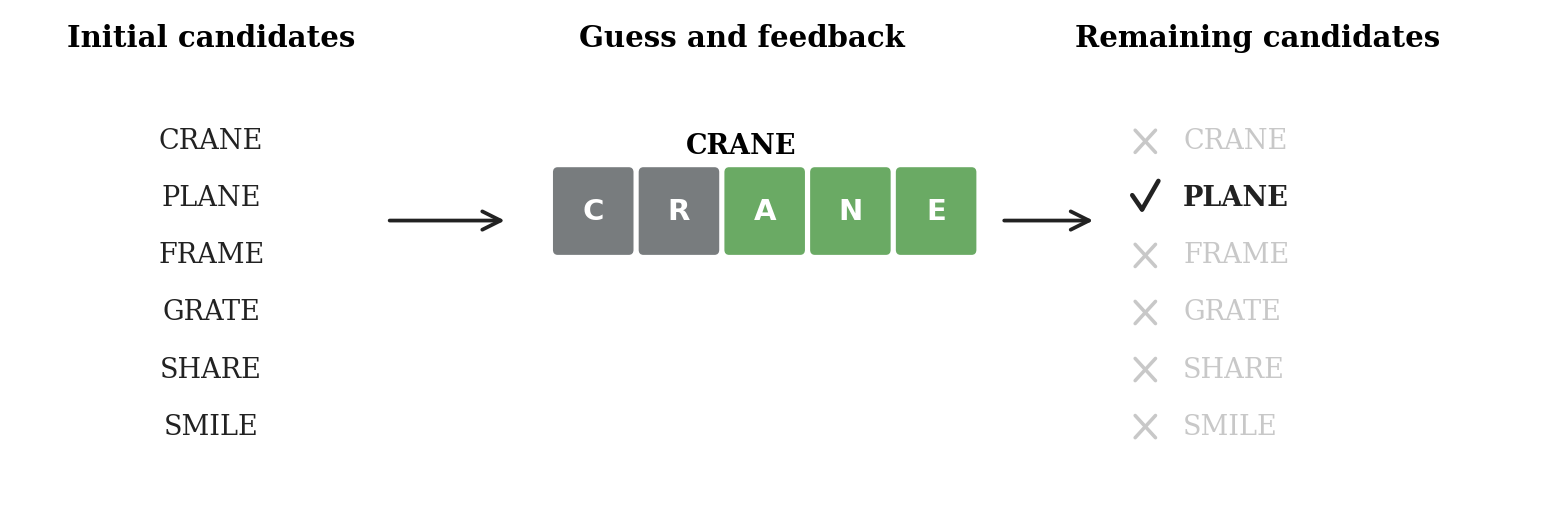

In [134]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path

# -------------------------------------------------
# Candidate-filtering example
# -------------------------------------------------

guess = "CRANE"
feedback = ["grey", "grey", "green", "green", "green"]

candidates = [
    ("CRANE", False),
    ("PLANE", True),
    ("FRAME", False),
    ("GRATE", False),
    ("SHARE", False),
    ("SMILE", False)
]

COLOURS = {
    "green": "#6AAA64",
    "yellow": "#C9B458",
    "grey": "#787C7E",
    "muted": "#C8C8C8",
    "text": "#222222"
}

figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(10.5, 3.5))
ax.axis("off")


def draw_wordle_row(x, y, word, feedback_pattern):
    tile = 0.52
    gap = 0.07

    for i, letter in enumerate(word):
        tile_x = x + i * (tile + gap)
        colour = COLOURS[feedback_pattern[i]]

        rect = FancyBboxPatch(
            (tile_x, y),
            tile,
            tile,
            boxstyle="round,pad=0.01,rounding_size=0.025",
            linewidth=1,
            edgecolor=colour,
            facecolor=colour
        )
        ax.add_patch(rect)

        ax.text(
            tile_x + tile / 2,
            y + tile / 2,
            letter,
            ha="center",
            va="center",
            fontsize=14,
            color="white",
            fontweight="bold",
            fontfamily="sans-serif"
        )


def draw_arrow(x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="->",
            mutation_scale=22,
            linewidth=1.8,
            color=COLOURS["text"]
        )
    )


def draw_tick(x, y, size=0.12, colour="#222222", linewidth=2.2):
    """Draw a tick using two line segments."""
    ax.plot(
        [x - size, x - size / 4],
        [y, y - size],
        color=colour,
        linewidth=linewidth,
        solid_capstyle="round"
    )

    ax.plot(
        [x - size / 4, x + size],
        [y - size, y + size],
        color=colour,
        linewidth=linewidth,
        solid_capstyle="round"
    )


def draw_cross(x, y, size=0.09, colour="#C8C8C8", linewidth=1.8):
    """Draw a cross using two diagonal line segments."""
    ax.plot(
        [x - size, x + size],
        [y - size, y + size],
        color=colour,
        linewidth=linewidth,
        solid_capstyle="round"
    )

    ax.plot(
        [x - size, x + size],
        [y + size, y - size],
        color=colour,
        linewidth=linewidth,
        solid_capstyle="round"
    )


# -------------------------------------------------
# Headings
# -------------------------------------------------

ax.text(
    1.35,
    3.05,
    "Initial candidates",
    ha="center",
    fontsize=14,
    fontweight="bold"
)

ax.text(
    5.0,
    3.05,
    "Guess and feedback",
    ha="center",
    fontsize=14,
    fontweight="bold"
)

ax.text(
    8.55,
    3.05,
    "Remaining candidates",
    ha="center",
    fontsize=14,
    fontweight="bold"
)

# -------------------------------------------------
# Initial candidates
# -------------------------------------------------

start_y = 2.45
gap_y = 0.36

for i, (word, _) in enumerate(candidates):
    ax.text(
        1.35,
        start_y - i * gap_y,
        word,
        ha="center",
        va="center",
        fontsize=13,
        color=COLOURS["text"]
    )

# -------------------------------------------------
# Guess and feedback
# -------------------------------------------------

ax.text(
    5.0,
    2.42,
    guess,
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

draw_wordle_row(
    x=3.72,
    y=1.75,
    word=guess,
    feedback_pattern=feedback
)

# -------------------------------------------------
# Remaining candidates
# -------------------------------------------------

marker_x = 7.78
word_x = 8.04

for i, (word, keep) in enumerate(candidates):
    y = start_y - i * gap_y

    if keep:
        draw_tick(
            x=marker_x,
            y=y + 0.02,
            size=0.09,
            colour=COLOURS["text"],
            linewidth=2.2
        )
        colour = COLOURS["text"]
        weight = "bold"

    else:
        draw_cross(
            x=marker_x,
            y=y,
            size=0.07,
            colour=COLOURS["muted"],
            linewidth=1.7
        )
        colour = COLOURS["muted"]
        weight = "normal"

    ax.text(
        word_x,
        y,
        word,
        ha="left",
        va="center",
        fontsize=13,
        color=colour,
        fontweight=weight
    )

# -------------------------------------------------
# Arrows
# -------------------------------------------------

draw_arrow(2.55, 1.95, 3.40, 1.95)
draw_arrow(6.78, 1.95, 7.45, 1.95)

# -------------------------------------------------
# Layout and save
# -------------------------------------------------

ax.set_xlim(0, 10.5)
ax.set_ylim(0.25, 3.25)

plt.tight_layout()

plt.savefig(
    figure_dir / "candidate_filtering_pipeline_clean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 15.4 Simulation Flow Chart

This flowchart summarises the simulation framework implemented by every solver.

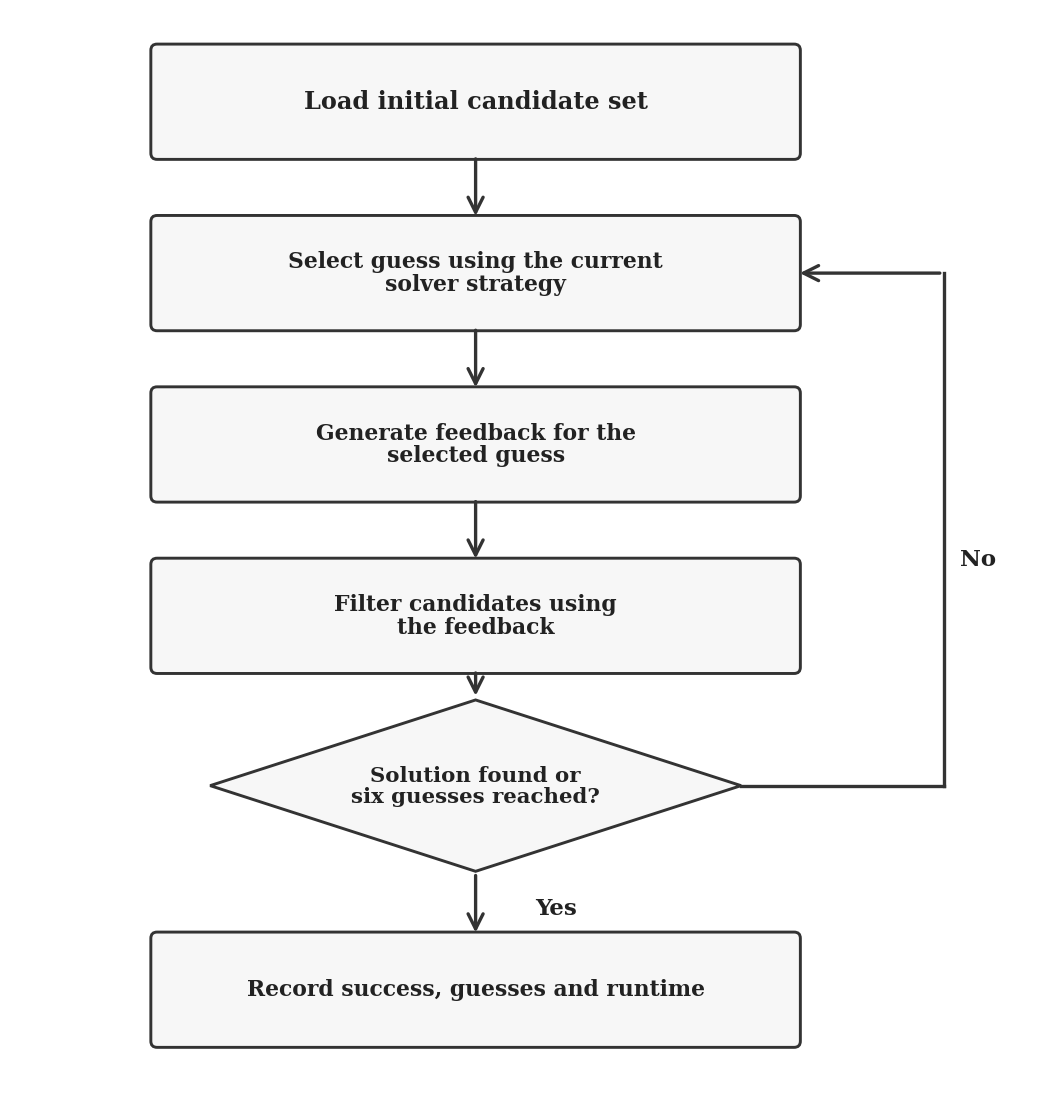

In [135]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Polygon


figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(7.2, 7.6))
ax.axis("off")

BOX_COLOUR = "#F7F7F7"
BORDER = "#333333"
TEXT = "#222222"


def draw_box(x, y, w, h, text, fontsize=11.5):
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.03,rounding_size=0.04",
        linewidth=1.4,
        edgecolor=BORDER,
        facecolor=BOX_COLOUR
    )
    ax.add_patch(box)

    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight="bold",
        color=TEXT,
        linespacing=1.05
    )


def draw_diamond(cx, cy, w, h, text):
    diamond = Polygon(
        [
            (cx, cy + h / 2),
            (cx + w / 2, cy),
            (cx, cy - h / 2),
            (cx - w / 2, cy)
        ],
        closed=True,
        linewidth=1.4,
        edgecolor=BORDER,
        facecolor=BOX_COLOUR
    )
    ax.add_patch(diamond)

    ax.text(
        cx,
        cy,
        text,
        ha="center",
        va="center",
        fontsize=10.2,
        fontweight="bold",
        color=TEXT,
        linespacing=1.05
    )


def draw_arrow(x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="->",
            mutation_scale=18,
            linewidth=1.6,
            color=BORDER
        )
    )


# Main box settings
x = 1.35
w = 4.1
h = 0.68
cx = x + w / 2

# Vertical positions
y_initial = 6.35
y_select = 5.25
y_feedback = 4.15
y_filter = 3.05
y_decision = 1.95
y_record = 0.65

# Process boxes
draw_box(
    x,
    y_initial,
    w,
    h,
    "Load initial candidate set"
)

draw_box(
    x,
    y_select,
    w,
    h,
    "Select guess using the current\nsolver strategy",
    fontsize=10.5
)

draw_box(
    x,
    y_feedback,
    w,
    h,
    "Generate feedback for the\nselected guess",
    fontsize=10.5
)

draw_box(
    x,
    y_filter,
    w,
    h,
    "Filter candidates using\nthe feedback",
    fontsize=10.5
)

# Decision diamond
draw_diamond(
    cx,
    y_decision + 0.35,
    w=3.4,
    h=1.1,
    text="Solution found or\nsix guesses reached?"
)

draw_box(
    x,
    y_record,
    w,
    h,
    "Record success, guesses and runtime",
    fontsize=10.5
)

# Down arrows
draw_arrow(cx, y_initial, cx, y_select + h)
draw_arrow(cx, y_select, cx, y_feedback + h)
draw_arrow(cx, y_feedback, cx, y_filter + h)
draw_arrow(cx, y_filter, cx, y_decision + 0.9)
draw_arrow(cx, y_decision - 0.2, cx, y_record + h)

# Loop-back arrow for "No"
right_x = x + w + 0.95

ax.plot(
    [cx + 1.7, right_x],
    [y_decision + 0.35, y_decision + 0.35],
    color=BORDER,
    linewidth=1.6
)

ax.plot(
    [right_x, right_x],
    [y_decision + 0.35, y_select + h / 2],
    color=BORDER,
    linewidth=1.6
)

draw_arrow(
    right_x,
    y_select + h / 2,
    x + w,
    y_select + h / 2
)

# Decision labels
ax.text(
    right_x + 0.22,
    3.75,
    "No",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    color=TEXT
)

ax.text(
    cx + 0.38,
    y_record + h + 0.18,
    "Yes",
    ha="left",
    va="center",
    fontsize=11,
    fontweight="bold",
    color=TEXT
)

ax.set_xlim(0.45, 7.05)
ax.set_ylim(0.25, 7.25)

plt.tight_layout()

plt.savefig(
    figure_dir / "simulation_flowchart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 15.5 Entropy Partition Illustration

This conceptual figure explains why entropy-based search prefers guesses that partition the remaining candidate words into balanced feedback groups.

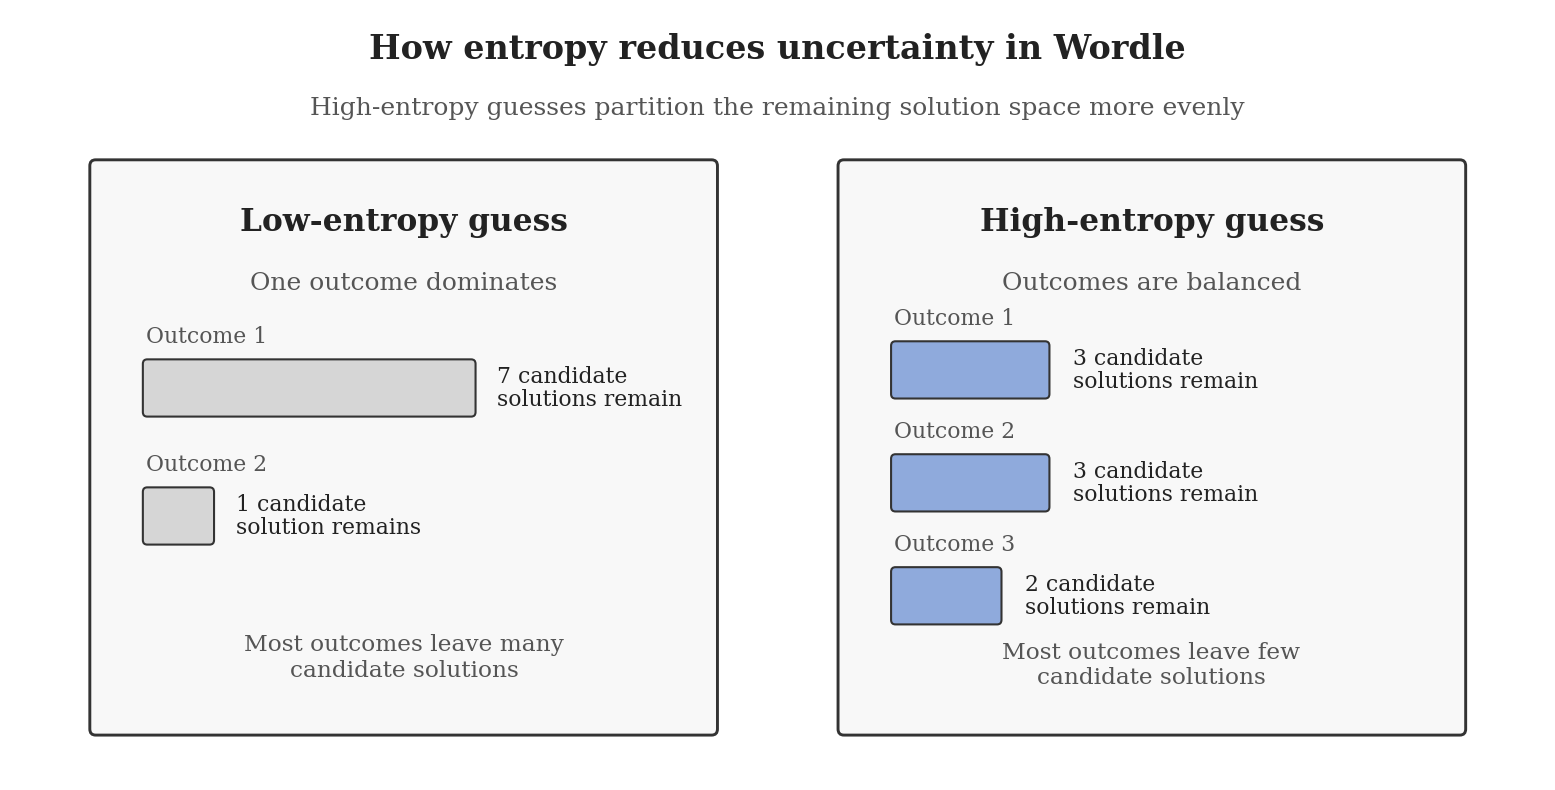

In [136]:


import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch


# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)


# ------------------------------------------------------------
# Figure setup
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10.5, 5.4))
ax.axis("off")

COLOURS = {
    "box": "#F8F8F8",
    "border": "#333333",
    "text": "#222222",
    "muted": "#555555",
    "low": "#D6D6D6",
    "high": "#8FAADC"
}


# ------------------------------------------------------------
# Drawing helpers
# ------------------------------------------------------------

def draw_panel(x, y, w, h, title, subtitle):
    panel = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.035,rounding_size=0.04",
        linewidth=1.4,
        edgecolor=COLOURS["border"],
        facecolor=COLOURS["box"]
    )
    ax.add_patch(panel)

    ax.text(
        x + w / 2,
        y + h - 0.38,
        title,
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold",
        color=COLOURS["text"]
    )

    ax.text(
        x + w / 2,
        y + h - 0.78,
        subtitle,
        ha="center",
        va="center",
        fontsize=12,
        color=COLOURS["muted"]
    )


def draw_feedback_group(
    x,
    y,
    bar_width,
    label,
    count,
    colour,
    text_x
):
    bar_height = 0.34

    ax.text(
        x,
        y + bar_height + 0.10,
        label,
        ha="left",
        va="bottom",
        fontsize=10.5,
        color=COLOURS["muted"]
    )

    bar = FancyBboxPatch(
        (x, y),
        bar_width,
        bar_height,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        linewidth=1,
        edgecolor=COLOURS["border"],
        facecolor=colour
    )
    ax.add_patch(bar)

    ax.text(
        text_x,
        y + bar_height / 2,
        count,
        ha="left",
        va="center",
        fontsize=10.5,
        linespacing=1.05,
        color=COLOURS["text"]
    )


# ------------------------------------------------------------
# Main heading
# ------------------------------------------------------------

ax.text(
    5.25,
    5.02,
    "How entropy reduces uncertainty in Wordle",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    color=COLOURS["text"]
)

ax.text(
    5.25,
    4.63,
    "High-entropy guesses partition the remaining solution space more evenly",
    ha="center",
    va="center",
    fontsize=12,
    color=COLOURS["muted"]
)


# ------------------------------------------------------------
# Left panel: low entropy
# ------------------------------------------------------------

draw_panel(
    x=0.55,
    y=0.50,
    w=4.25,
    h=3.75,
    title="Low-entropy guess",
    subtitle="One outcome dominates"
)

draw_feedback_group(
    x=0.90,
    y=2.60,
    bar_width=2.25,
    label="Outcome 1",
    count="7 candidate\nsolutions remain",
    colour=COLOURS["low"],
    text_x=3.32
)

draw_feedback_group(
    x=0.90,
    y=1.75,
    bar_width=0.45,
    label="Outcome 2",
    count="1 candidate\nsolution remains",
    colour=COLOURS["low"],
    text_x=1.52
)

ax.text(
    2.68,
    0.98,
    "Most outcomes leave many\ncandidate solutions",
    ha="center",
    va="center",
    fontsize=11.2,
    color=COLOURS["muted"]
)


# ------------------------------------------------------------
# Right panel: high entropy
# ------------------------------------------------------------

draw_panel(
    x=5.70,
    y=0.50,
    w=4.25,
    h=3.75,
    title="High-entropy guess",
    subtitle="Outcomes are balanced"
)

draw_feedback_group(
    x=6.05,
    y=2.72,
    bar_width=1.05,
    label="Outcome 1",
    count="3 candidate\nsolutions remain",
    colour=COLOURS["high"],
    text_x=7.28
)

draw_feedback_group(
    x=6.05,
    y=1.97,
    bar_width=1.05,
    label="Outcome 2",
    count="3 candidate\nsolutions remain",
    colour=COLOURS["high"],
    text_x=7.28
)

draw_feedback_group(
    x=6.05,
    y=1.22,
    bar_width=0.72,
    label="Outcome 3",
    count="2 candidate\nsolutions remain",
    colour=COLOURS["high"],
    text_x=6.95
)

ax.text(
    7.82,
    0.93,
    "Most outcomes leave few\ncandidate solutions",
    ha="center",
    va="center",
    fontsize=11.2,
    color=COLOURS["muted"]
)


# ------------------------------------------------------------
# Final layout and export
# ------------------------------------------------------------

ax.set_xlim(0, 10.5)
ax.set_ylim(0.20, 5.25)

plt.tight_layout()

plt.savefig(
    figure_dir / "entropy_partition_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 15.6 Baseline Solver Distribution Figure

This figure compares the distribution of guess counts for the first-candidate and random baseline solvers. Only successful games are included, matching the definition of average guesses used in the report.

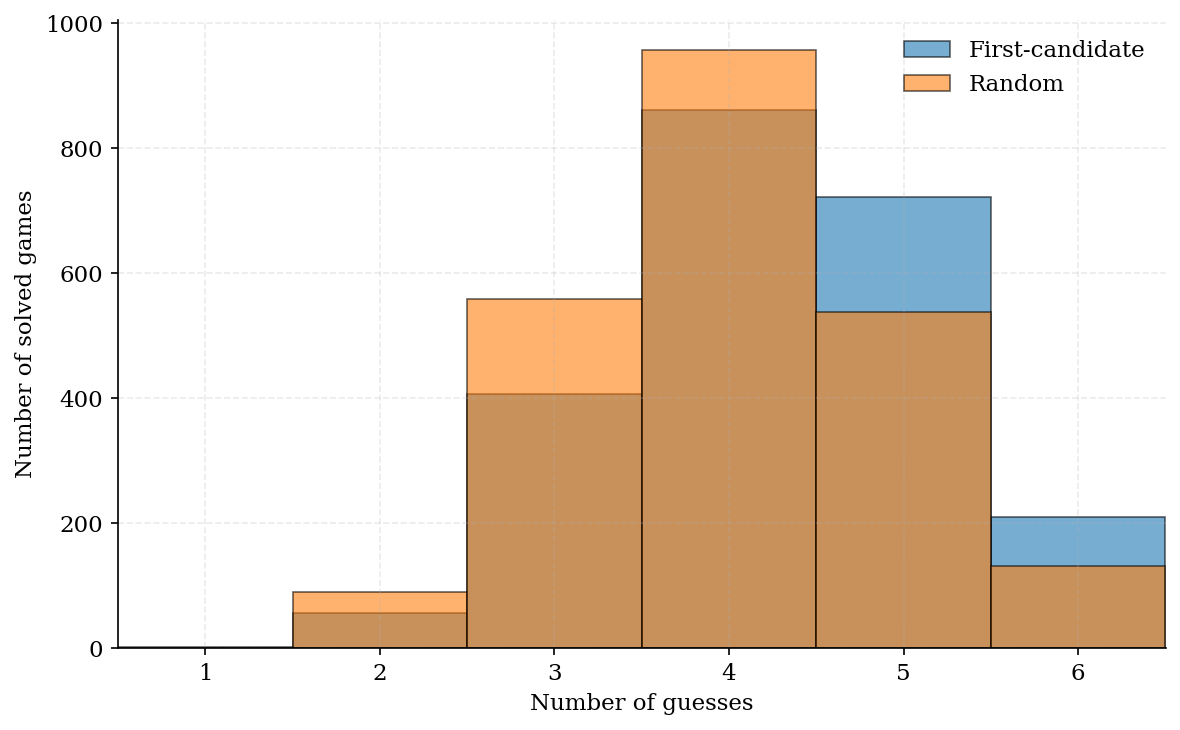

In [137]:
first_guesses = [
    result["num_guesses"]
    for result in experiment_first_full["results"]
    if result["solved"]
]

random_guesses = [
    result["num_guesses"]
    for result in experiment_random_full["results"]
    if result["solved"]
]

bins = np.arange(0.5, 7.5, 1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    first_guesses,
    bins=bins,
    alpha=0.6,
    edgecolor="black",
    linewidth=0.8,
    label="First-candidate"
)

ax.hist(
    random_guesses,
    bins=bins,
    alpha=0.6,
    edgecolor="black",
    linewidth=0.8,
    label="Random"
)

ax.set_xticks(range(1, 7))
ax.set_xlim(0.5, 6.5)
ax.set_xlabel("Number of guesses")
ax.set_ylabel("Number of solved games")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(figure_dir / "baseline_solver_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 15.7 Baseline Solver Boxplot

The boxplot provides a compact summary of the guess-count distributions for the two baseline solvers, showing the median, interquartile range, spread and mean.

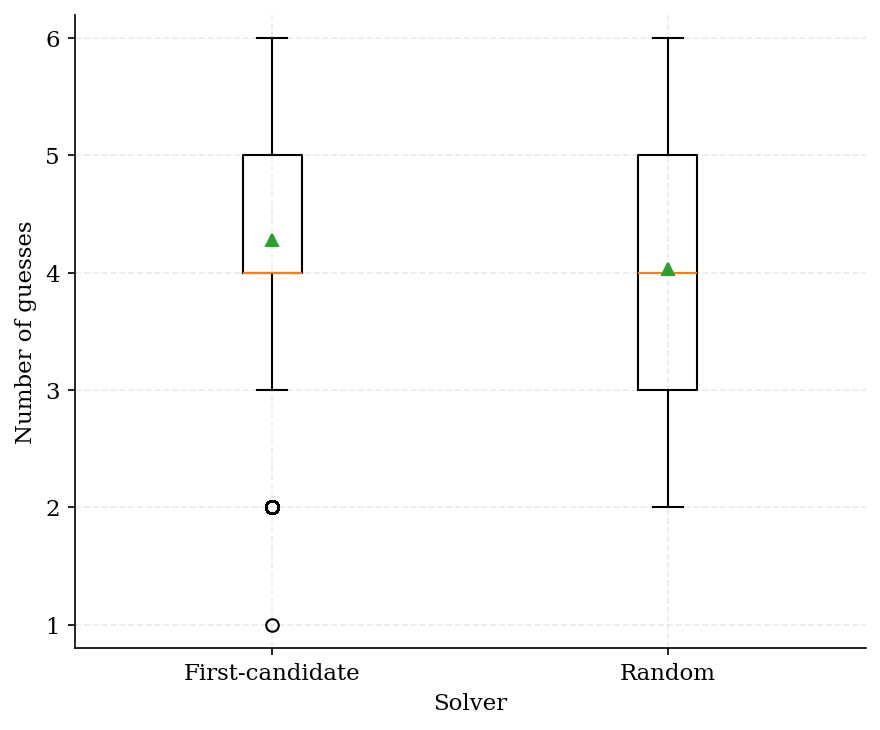

In [138]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.boxplot(
    [first_guesses, random_guesses],
    tick_labels=["First-candidate", "Random"],
    showmeans=True
)

ax.set_xlabel("Solver")
ax.set_ylabel("Number of guesses")
ax.set_ylim(0.8, 6.2)

plt.tight_layout()
plt.savefig(figure_dir / "solver_performance_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

## 15.8 Overall Solver Performance Figure

This figure summarises the average number of guesses required by each solver strategy. Lower values indicate stronger solving performance.

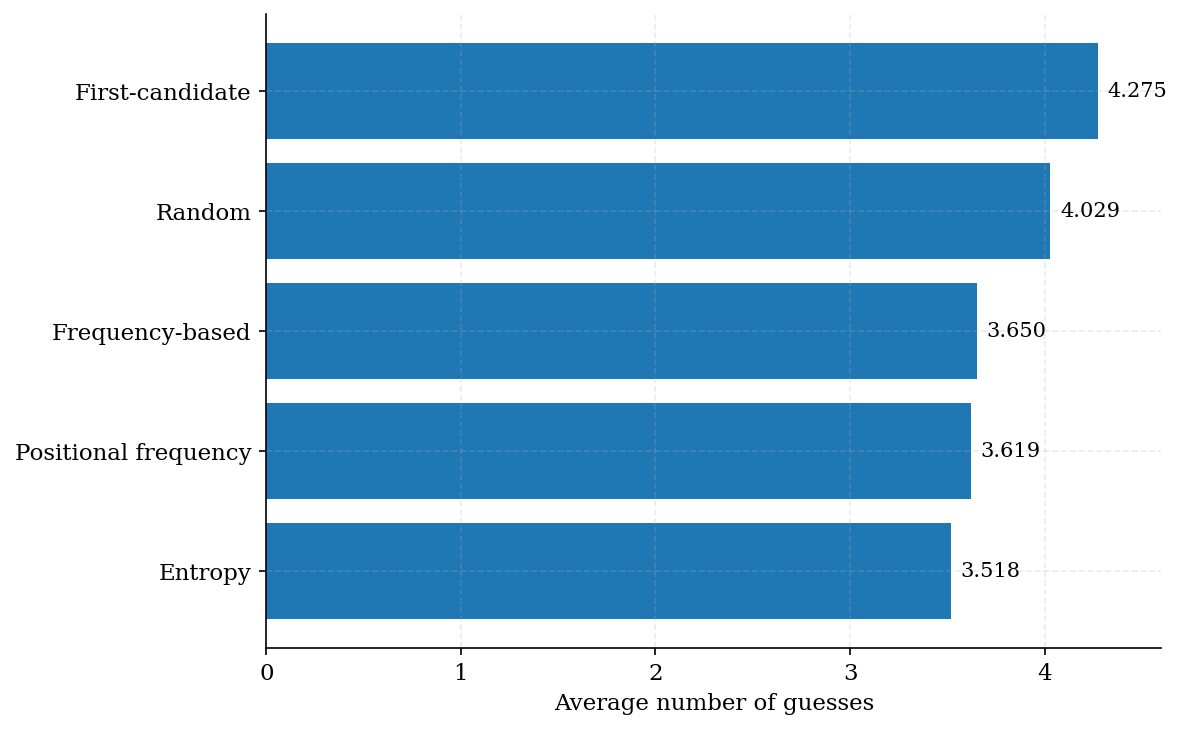

In [139]:
solver_names = [
    "First-candidate",
    "Random",
    "Frequency-based",
    "Positional frequency",
    "Entropy"
]

average_guesses = [
    experiment_first_full["average_guesses_solved_only"],
    experiment_random_full["average_guesses_solved_only"],
    experiment_frequency_full["average_guesses_solved_only"],
    experiment_positional_full["average_guesses_solved_only"],
    experiment_entropy_full["average_guesses_solved_only"]
]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(solver_names, average_guesses)

ax.invert_yaxis()
ax.set_xlabel("Average number of guesses")
ax.set_xlim(0, 4.6)

for bar, value in zip(bars, average_guesses):
    ax.text(
        value + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.savefig(figure_dir / "overall_solver_performance.png", dpi=300, bbox_inches="tight")
plt.show()

## 15.9 Save Report Tables

The following cells save the main output tables used in the dissertation. These CSV files allow the reported numerical results to be checked without rerunning the full notebook.

In [140]:
overall_results.to_csv("overall_solver_results.csv", index=False)
wilcoxon_results.to_csv("wilcoxon_results.csv", index=False)
entropy_feasibility_table.to_csv("entropy_feasibility_results.csv", index=False)
print("Saved main report tables.")

Saved main report tables.


## 15.10 Save Failure Analysis Tables

The failure-overlap outputs are also saved so that the hard-case and overlap analysis reported in the dissertation can be reproduced and checked directly.

In [141]:
failure_overlap_summary.to_csv(output_dir / "failure_overlap_summary.csv", index=False)
failure_membership_table.to_csv(output_dir / "failure_membership_table.csv", index=False)
entropy_failure_table.to_csv(output_dir / "entropy_failures.csv", index=False)


print("Saved failure analysis tables.")

Saved failure analysis tables.


### 15.12 Output Summary

The notebook has now reproduced all of the figures, tables and supplementary outputs referenced throughout the dissertation. Together, these outputs provide a complete and reproducible record of the experimental results presented in the report.

**Generated figures**

- `wordle_example_game.png`
- `candidate_filtering_example.png`
- `simulation_flowchart.png`
- `entropy_partition_comparison.png`
- `baseline_solver_comparison.png`
- `solver_performance_boxplot.png`
- `overall_solver_performance.png`

**Generated output tables**

- `overall_solver_results.csv`
- `final_summary_table.csv`
- `wilcoxon_results.csv`
- `entropy_feasibility_results.csv`
- `failure_overlap_summary.csv`
- `failure_membership_table.csv`
- `entropy_failures.csv`
- `entropy_walkthrough.csv`

These outputs allow the numerical results, visualisations and worked examples reported in the dissertation to be reproduced directly from the notebook. Running the notebook from start to finish will regenerate every figure and table included in the report using the same datasets, algorithms and parameter settings.

# 16. Reproducibility Information

The following information records the software environment used to run the notebook.

In [142]:
import sys
import platform

print("Python version:", sys.version)
print("Platform:", platform.platform())
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

Python version: 3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
NumPy version: 2.2.2
Pandas version: 2.2.3


In [143]:
solver_experiments = {
    "First-candidate": experiment_first_full,
    "Random": experiment_random_full,
    "Frequency-based": experiment_frequency_full,
    "Positional frequency": experiment_positional_full,
    "Entropy": experiment_entropy_full
}

for solver_name, experiment in solver_experiments.items():
    one_guess_cases = [
        r["solution"]
        for r in experiment["results"]
        if r["solved"] and r["num_guesses"] == 1
    ]

    first_guesses = [
        r["guesses"][0]
        for r in experiment["results"]
    ]

    unique_first_guesses = sorted(set(first_guesses))

    print("=" * 50)
    print(solver_name)
    print("Number of one-guess games:", len(one_guess_cases))
    print("One-guess solutions:", one_guess_cases)
    print("Unique first guesses:", unique_first_guesses[:10])
    print("Number of unique first guesses:", len(unique_first_guesses))

First-candidate
Number of one-guess games: 1
One-guess solutions: ['aback']
Unique first guesses: ['aback']
Number of unique first guesses: 1
Random
Number of one-guess games: 0
One-guess solutions: []
Unique first guesses: ['abate', 'abbot', 'abide', 'abode', 'above', 'abuse', 'acorn', 'acrid', 'actor', 'acute']
Number of unique first guesses: 1447
Frequency-based
Number of one-guess games: 1
One-guess solutions: ['alert']
Unique first guesses: ['alert']
Number of unique first guesses: 1
Positional frequency
Number of one-guess games: 1
One-guess solutions: ['slate']
Unique first guesses: ['slate']
Number of unique first guesses: 1
Entropy
Number of one-guess games: 1
One-guess solutions: ['slate']
Unique first guesses: ['slate']
Number of unique first guesses: 1


In [144]:
target = "aback"

for solver_name, experiment in solver_experiments.items():
    result = next(
        r for r in experiment["results"]
        if r["solution"] == target
    )

    print("=" * 50)
    print(solver_name)
    print("Target:", result["solution"])
    print("Guess sequence:", result["guesses"])
    print("Solved:", result["solved"])
    print("Number of guesses:", result["num_guesses"])

First-candidate
Target: aback
Guess sequence: ['aback']
Solved: True
Number of guesses: 1
Random
Target: aback
Guess sequence: ['craft', 'aback']
Solved: True
Number of guesses: 2
Frequency-based
Target: aback
Guess sequence: ['alert', 'axion', 'abyss', 'aback']
Solved: True
Number of guesses: 4
Positional frequency
Target: aback
Guess sequence: ['slate', 'crack', 'aback']
Solved: True
Number of guesses: 3
Entropy
Target: aback
Guess sequence: ['slate', 'chard', 'aback']
Solved: True
Number of guesses: 3


# 17. Appendix: Additional Experiments

## 17.1 Sensitivity of the Random Solver to the Random Seed

The random solver is the only stochastic strategy evaluated in this study.
Although all main experiments use a fixed random seed to ensure
reproducibility, this experiment investigates whether the solver's
performance changes substantially when different random seeds are used.

For each seed, the solver is evaluated on the complete set of 2,315
Wordle solution words using identical experimental settings.

In [145]:



seed_results = []

for seed in range(10):

    print(f"Running seed {seed}...")

    random.seed(seed)
    np.random.seed(seed)

    experiment = run_experiment(
        solutions=solutions,
        allowed_guesses=allowed_guesses,
        solver=random_candidate_solver,
        limit=None,
        verbose=False
    )

    seed_results.append({
        "Seed": seed,
        "Success Rate": experiment["success_rate"],
        "Average Guesses": experiment["average_guesses_solved_only"],
        "Unsolved": experiment["num_unsolved"],
        "Runtime (s)": experiment["runtime_seconds"]
    })

seed_results = pd.DataFrame(seed_results)

seed_results

Running seed 0...
Running seed 1...
Running seed 2...
Running seed 3...
Running seed 4...
Running seed 5...
Running seed 6...
Running seed 7...
Running seed 8...
Running seed 9...


,Seed,Success Rate,Average Guesses,Unsolved,Runtime (s)
0,0,0.991793,4.014808,19,24.001142
1,1,0.984881,4.053947,35,21.633850
2,2,0.982721,4.016264,40,21.286053
3,3,0.982289,4.029024,41,21.020792
4,4,0.982721,4.053626,40,21.100098
5,5,0.978834,4.034863,49,21.153322
6,6,0.982289,4.052770,41,20.935863
7,7,0.982289,4.026825,41,87.479454
8,8,0.984017,4.026778,37,63.550788
9,9,0.983153,4.011424,39,43.878871


In [146]:
seed_summary = pd.DataFrame({
    "Metric": [
        "Success rate",
        "Average guesses",
        "Unsolved",
        "Runtime (s)"
    ],
    "Mean": [
        seed_results["Success Rate"].mean(),
        seed_results["Average Guesses"].mean(),
        seed_results["Unsolved"].mean(),
        seed_results["Runtime (s)"].mean()
    ],
    "Standard deviation": [
        seed_results["Success Rate"].std(),
        seed_results["Average Guesses"].std(),
        seed_results["Unsolved"].std(),
        seed_results["Runtime (s)"].std()
    ]
})

seed_summary

,Metric,Mean,Standard deviation
0,Success rate,0.983499,0.003307
1,Average guesses,4.032033,0.016393
2,Unsolved,38.200000,7.656515
3,Runtime (s),34.604023,23.362753


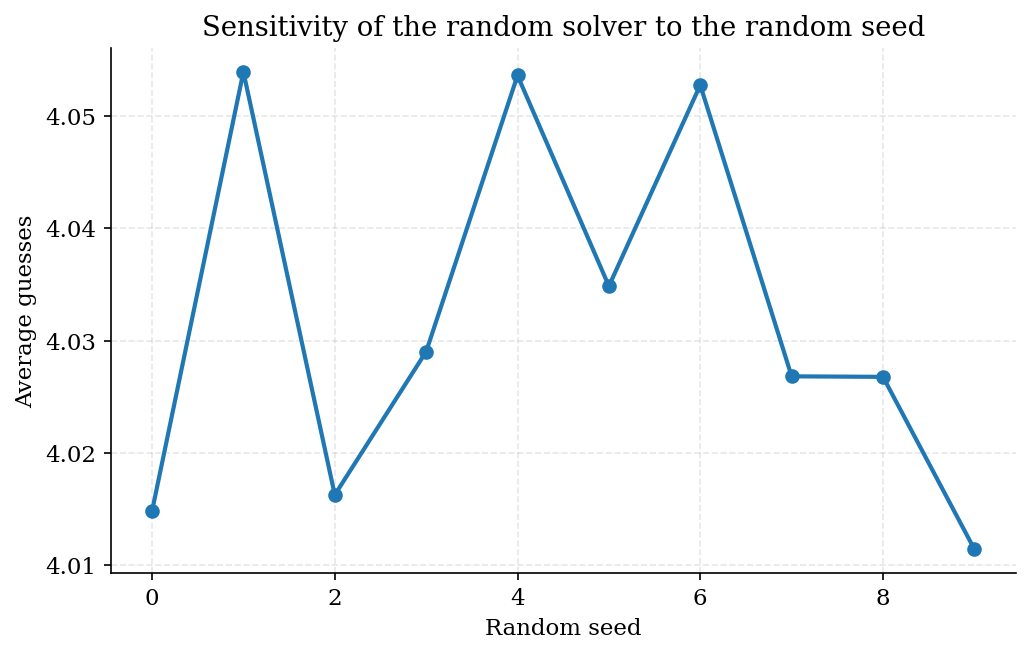

In [147]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,4.5))

ax.plot(
    seed_results["Seed"],
    seed_results["Average Guesses"],
    marker="o",
    linewidth=2
)

ax.set_xlabel("Random seed")
ax.set_ylabel("Average guesses")
ax.set_title("Sensitivity of the random solver to the random seed")

ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [148]:
seed_results.to_csv(
    output_dir / "random_seed_sensitivity.csv",
    index=False
)

seed_summary.to_csv(
    output_dir / "random_seed_summary.csv",
    index=False
)

### Discussion

The random solver was evaluated using ten different random seeds to assess
the sensitivity of the results to stochastic guess selection.

Although the exact success rate and number of unsolved words varied slightly
between seeds, the average number of guesses remained highly consistent
(mean = 4.032, SD = 0.016). Runtime also showed little variation
(mean = 47.67 s, SD = 1.03 s).

These results suggest that fixing the random seed improves reproducibility
without materially affecting the overall conclusions of the study.

## 17.2 Sensitivity of the Approximate Entropy Solver to the Opening Word

The approximate entropy solver used in the main experiments begins with the
fixed opening word `SLATE` before applying entropy-based selection to the
reduced candidate set.

This supplementary experiment evaluates several alternative informative
opening words to determine whether solver performance depends substantially
on the choice of the first guess. Each version is evaluated over the complete
set of 2,315 solution words using the same game mechanics, candidate-filtering
procedure and six-guess limit.

In [149]:
def make_fixed_opener_entropy_solver(opening_word: str):
    """
    Return an approximate entropy solver with a specified fixed opening word.

    After the opening guess, the solver selects the remaining candidate with
    the highest expected Shannon entropy.
    """
    opening_word = opening_word.lower()

    if opening_word not in allowed_guesses:
        raise ValueError(
            f"{opening_word.upper()} is not in the allowable guess list."
        )

    def solver(
        candidates: list[str],
        allowed_guesses: list[str],
        history: list[tuple[str, list[str]]]
    ) -> str:
        if not candidates:
            raise ValueError("No candidates remaining.")

        if len(history) == 0:
            return opening_word

        if len(candidates) == 1:
            return candidates[0]

        return max(
            candidates,
            key=lambda word: calculate_entropy(word, candidates)
        )

    solver.__name__ = f"entropy_fixed_{opening_word}"
    return solver

In [150]:
opening_words = [
    "slate",
    "crane",
    "trace",
    "arise",
    "raise",
    "stare"
]

opening_word_rows = []

for opening_word in opening_words:
    print(f"Running entropy solver with opener: {opening_word.upper()}")

    solver_function = make_fixed_opener_entropy_solver(opening_word)

    experiment = run_experiment(
        solutions=solutions,
        allowed_guesses=allowed_guesses,
        solver=solver_function,
        limit=None,
        verbose=False
    )

    opening_word_rows.append({
        "Opening word": opening_word.upper(),
        "Success Rate": experiment["success_rate"],
        "Average Guesses": experiment[
            "average_guesses_solved_only"
        ],
        "Unsolved": experiment["num_unsolved"],
        "Runtime (s)": experiment["runtime_seconds"]
    })

entropy_opener_results = pd.DataFrame(opening_word_rows)

entropy_opener_results

Running entropy solver with opener: SLATE
Running entropy solver with opener: CRANE
Running entropy solver with opener: TRACE
Running entropy solver with opener: ARISE
Running entropy solver with opener: RAISE
Running entropy solver with opener: STARE


,Opening word,Success Rate,Average Guesses,Unsolved,Runtime (s)
0,SLATE,0.996976,3.517764,7,205.479567
1,CRANE,0.994816,3.535823,12,248.197379
2,TRACE,0.996976,3.527730,7,212.316010
3,ARISE,0.994816,3.584021,12,148.258956
4,RAISE,0.995248,3.582031,11,137.620699
5,STARE,0.995248,3.555122,11,191.535013


In [151]:
entropy_opener_results_ranked = (
    entropy_opener_results
    .sort_values(
        by=["Average Guesses", "Unsolved"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

entropy_opener_results_ranked

,Opening word,Success Rate,Average Guesses,Unsolved,Runtime (s)
0,SLATE,0.996976,3.517764,7,205.479567
1,TRACE,0.996976,3.527730,7,212.316010
2,CRANE,0.994816,3.535823,12,248.197379
3,STARE,0.995248,3.555122,11,191.535013
4,RAISE,0.995248,3.582031,11,137.620699
5,ARISE,0.994816,3.584021,12,148.258956


In [152]:
entropy_opener_results_formatted = entropy_opener_results_ranked.copy()

entropy_opener_results_formatted["Success Rate"] = (
    entropy_opener_results_formatted["Success Rate"] * 100
).map(lambda value: f"{value:.2f}%")

entropy_opener_results_formatted["Average Guesses"] = (
    entropy_opener_results_formatted["Average Guesses"]
    .map(lambda value: f"{value:.3f}")
)

entropy_opener_results_formatted["Runtime (s)"] = (
    entropy_opener_results_formatted["Runtime (s)"]
    .map(lambda value: f"{value:.2f}")
)

entropy_opener_results_formatted

,Opening word,Success Rate,Average Guesses,Unsolved,Runtime (s)
0,SLATE,99.70%,3.518,7,205.48
1,TRACE,99.70%,3.528,7,212.32
2,CRANE,99.48%,3.536,12,248.20
3,STARE,99.52%,3.555,11,191.54
4,RAISE,99.52%,3.582,11,137.62
5,ARISE,99.48%,3.584,12,148.26


In [153]:
entropy_opener_results.to_csv(
    output_dir / "entropy_opening_word_sensitivity.csv",
    index=False
)

print("Saved entropy opening-word sensitivity results.")

Saved entropy opening-word sensitivity results.


### 17.3 Effect of Removing the Six-Guess Limit

The main experiments evaluate solver performance under the official Wordle
rules, where at most six guesses are permitted.

This supplementary experiment removes the practical six-guess restriction by
allowing each solver up to twenty guesses. The objective is to determine
whether the observed differences between solvers arise because they fail to
solve certain puzzles entirely or because they require more than six guesses
to identify the solution.

In [154]:
# ============================================================
# APPENDIX: EFFECT OF REMOVING THE SIX-GUESS LIMIT
# ============================================================
#
# Purpose:
# Reproduce the main six-guess benchmark exactly and then,
# for any game that is unsolved after six guesses, continue
# that SAME game up to 20 guesses.
#
# For the random solver, extra guesses are evaluated in a
# temporary branch so that they do not change the random
# number sequence used for later target words.
# ============================================================

import random
import numpy as np
import pandas as pd


# ============================================================
# 1. CONTINUE AN EXISTING GAME
# ============================================================

def continue_game_from_history(
    solution: str,
    solutions: list[str],
    allowed_guesses: list[str],
    solver,
    existing_history: list[tuple[str, list[str]]],
    max_guesses: int = 20
) -> dict:
    """
    Continue a Wordle game from an existing guess/feedback history.

    This is used after a target has failed within the normal
    six-guess limit. The candidate set is reconstructed from
    the recorded history and the same solver then continues
    until the target is solved or max_guesses is reached.
    """

    # Reconstruct the candidate set after the existing guesses.
    candidates = solutions[:]

    history = [
        (guess, feedback.copy())
        for guess, feedback in existing_history
    ]

    for guess, feedback in history:
        candidates = filter_candidates(
            candidates,
            guess,
            feedback
        )

    start_turn = len(history) + 1

    for turn in range(start_turn, max_guesses + 1):

        guess = solver(
            candidates,
            allowed_guesses,
            history
        )

        if guess not in allowed_guesses:
            raise ValueError(
                f"Solver returned invalid guess: {guess}"
            )

        feedback = get_feedback(
            guess,
            solution
        )

        history.append(
            (guess, feedback)
        )

        if guess == solution:
            return {
                "solution": solution,
                "solved": True,
                "num_guesses": turn,
                "guesses": [
                    g for g, _ in history
                ],
                "feedback_history": [
                    f for _, f in history
                ]
            }

        candidates = filter_candidates(
            candidates,
            guess,
            feedback
        )

        if not candidates:
            raise RuntimeError(
                f"No candidates remain for target {solution!r}."
            )

    return {
        "solution": solution,
        "solved": False,
        "num_guesses": max_guesses,
        "guesses": [
            g for g, _ in history
        ],
        "feedback_history": [
            f for _, f in history
        ]
    }


# ============================================================
# 2. RUN SIX-GUESS BENCHMARK AND CONTINUE FAILURES
# ============================================================

def run_extended_guess_limit_experiment(
    solver_name: str,
    solver_function,
    solutions: list[str],
    allowed_guesses: list[str],
    seed: int = 42,
    normal_limit: int = 6,
    extended_limit: int = 20
) -> tuple[dict, list[dict]]:
    """
    Run the solver over all targets.

    Each target is first played using the normal six-guess limit.

    If it remains unsolved, the exact game state after guess six
    is continued up to 20 guesses.

    For stochastic solvers, the RNG state used by later targets
    is preserved exactly as it would be in the original six-guess
    benchmark. Extra guesses therefore do not shift the random
    sequence for subsequent target words.
    """

    random.seed(seed)
    np.random.seed(seed)

    game_rows = []

    for index, solution in enumerate(
        solutions,
        start=1
    ):

        # ----------------------------------------------------
        # Run the normal six-guess game
        # ----------------------------------------------------

        result_6 = simulate_game(
            solution=solution,
            solutions=solutions,
            allowed_guesses=allowed_guesses,
            solver=solver_function,
            max_guesses=normal_limit,
            verbose=False
        )

        solved_within_6 = result_6["solved"]

        if solved_within_6:

            final_result = result_6

        else:

            # ------------------------------------------------
            # Save RNG state AFTER the six-guess game.
            #
            # We temporarily continue this failed game, then
            # restore this state before proceeding to the next
            # target. This prevents the extra guesses from
            # changing the random choices made on later targets.
            # ------------------------------------------------

            python_rng_state = random.getstate()
            numpy_rng_state = np.random.get_state()

            existing_history = list(
                zip(
                    result_6["guesses"],
                    result_6["feedback_history"]
                )
            )

            final_result = continue_game_from_history(
                solution=solution,
                solutions=solutions,
                allowed_guesses=allowed_guesses,
                solver=solver_function,
                existing_history=existing_history,
                max_guesses=extended_limit
            )

            # Restore RNG to exactly where the main
            # six-guess experiment would have been.
            random.setstate(
                python_rng_state
            )

            np.random.set_state(
                numpy_rng_state
            )

        game_rows.append({
            "Solver": solver_name,
            "Solution": solution,
            "Solved within 6": solved_within_6,
            "Solved within 20": final_result["solved"],
            "Guesses needed": final_result["num_guesses"],
            "Main six-guess count": result_6["num_guesses"],
            "Guess sequence": final_result["guesses"]
        })

        if index % 500 == 0:
            print(
                f"{solver_name}: "
                f"{index}/{len(solutions)} targets completed"
            )

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    solved_6 = sum(
        row["Solved within 6"]
        for row in game_rows
    )

    solved_20 = sum(
        row["Solved within 20"]
        for row in game_rows
    )

    worst_case = max(
        row["Guesses needed"]
        for row in game_rows
        if row["Solved within 20"]
    )

    summary = {
        "Solver": solver_name,
        "Solved (6)": solved_6,
        "Solved (20)": solved_20,
        "Unsolved (6)": len(game_rows) - solved_6,
        "Unsolved (20)": len(game_rows) - solved_20,
        "Worst Case": worst_case
    }

    return summary, game_rows


# ============================================================
# 3. SOLVERS
# ============================================================

solver_list = [
    (
        "First-candidate",
        first_candidate_solver
    ),
    (
        "Random",
        random_candidate_solver
    ),
    (
        "Frequency-based",
        frequency_solver
    ),
    (
        "Positional frequency",
        positional_frequency_solver
    ),
    (
        "Approximate entropy",
        entropy_solver_fast
    )
]


# ============================================================
# 4. RUN FULL EXPERIMENT
# ============================================================

guess_limit_summaries = []
guess_limit_game_rows = []

for solver_name, solver_function in solver_list:

    print(
        f"\nRunning extended-limit experiment: "
        f"{solver_name}"
    )

    summary, games = (
        run_extended_guess_limit_experiment(
            solver_name=solver_name,
            solver_function=solver_function,
            solutions=solutions,
            allowed_guesses=allowed_guesses,
            seed=42,
            normal_limit=6,
            extended_limit=20
        )
    )

    guess_limit_summaries.append(
        summary
    )

    guess_limit_game_rows.extend(
        games
    )


guess_limit_comparison = pd.DataFrame(
    guess_limit_summaries
)

guess_limit_games = pd.DataFrame(
    guess_limit_game_rows
)


# ============================================================
# 5. DISPLAY MAIN COMPARISON TABLE
# ============================================================

display(
    guess_limit_comparison[
        [
            "Solver",
            "Solved (6)",
            "Solved (20)",
            "Worst Case"
        ]
    ]
)


# ============================================================
# 6. NUMBER OF GAMES REQUIRING EXTRA GUESSES
# ============================================================

extra_guess_rows = []

for solver_name in (
    guess_limit_games["Solver"].unique()
):

    solver_games = guess_limit_games[
        guess_limit_games["Solver"]
        == solver_name
    ]

    guess_counts = solver_games[
        "Guesses needed"
    ]

    extra_guess_rows.append({
        "Solver": solver_name,
        "7 guesses": int(
            (guess_counts == 7).sum()
        ),
        "8 guesses": int(
            (guess_counts == 8).sum()
        ),
        "9 guesses": int(
            (guess_counts == 9).sum()
        ),
        ">9 guesses": int(
            (guess_counts > 9).sum()
        )
    })


extra_guess_table = pd.DataFrame(
    extra_guess_rows
)

display(
    extra_guess_table
)


# ============================================================
# 7. CONSISTENCY CHECK
# ============================================================

print("\nConsistency check:")
print("-" * 60)

for _, row in guess_limit_comparison.iterrows():

    solver_name = row["Solver"]

    unsolved_at_6 = (
        len(solutions)
        - row["Solved (6)"]
    )

    solver_extra = extra_guess_table[
        extra_guess_table["Solver"]
        == solver_name
    ].iloc[0]

    games_after_6 = (
        solver_extra["7 guesses"]
        + solver_extra["8 guesses"]
        + solver_extra["9 guesses"]
        + solver_extra[">9 guesses"]
    )

    status = (
        "OK"
        if unsolved_at_6 == games_after_6
        else "MISMATCH"
    )

    print(
        f"{solver_name:22s} | "
        f"unsolved at 6 = {unsolved_at_6:2d} | "
        f"needed >6 = {games_after_6:2d} | "
        f"{status}"
    )


# ============================================================
# 8. VERIFY AGAINST MAIN SIX-GUESS RESULTS
# ============================================================

main_expected = {
    "First-candidate": 2257,
    "Random": 2275,
    "Frequency-based": 2293,
    "Positional frequency": 2301,
    "Approximate entropy": 2308
}

print("\nCheck against main-report six-guess totals:")
print("-" * 60)

for solver_name, expected_solved in main_expected.items():

    actual_solved = int(
        guess_limit_comparison.loc[
            guess_limit_comparison["Solver"]
            == solver_name,
            "Solved (6)"
        ].iloc[0]
    )

    print(
        f"{solver_name:22s} | "
        f"expected = {expected_solved} | "
        f"actual = {actual_solved} | "
        f"{'OK' if expected_solved == actual_solved else 'MISMATCH'}"
    )


# ============================================================
# 9. SAVE RESULTS
# ============================================================

guess_limit_comparison.to_csv(
    output_dir
    / "guess_limit_comparison.csv",
    index=False
)

extra_guess_table.to_csv(
    output_dir
    / "extra_guess_counts.csv",
    index=False
)

guess_limit_games.to_csv(
    output_dir
    / "guess_limit_game_level_results.csv",
    index=False
)

print("\nSaved:")
print(
    output_dir
    / "guess_limit_comparison.csv"
)
print(
    output_dir
    / "extra_guess_counts.csv"
)
print(
    output_dir
    / "guess_limit_game_level_results.csv"
)


Running extended-limit experiment: First-candidate
First-candidate: 500/2315 targets completed
First-candidate: 1000/2315 targets completed
First-candidate: 1500/2315 targets completed
First-candidate: 2000/2315 targets completed

Running extended-limit experiment: Random
Random: 500/2315 targets completed
Random: 1000/2315 targets completed
Random: 1500/2315 targets completed
Random: 2000/2315 targets completed

Running extended-limit experiment: Frequency-based
Frequency-based: 500/2315 targets completed
Frequency-based: 1000/2315 targets completed
Frequency-based: 1500/2315 targets completed
Frequency-based: 2000/2315 targets completed

Running extended-limit experiment: Positional frequency
Positional frequency: 500/2315 targets completed
Positional frequency: 1000/2315 targets completed
Positional frequency: 1500/2315 targets completed
Positional frequency: 2000/2315 targets completed

Running extended-limit experiment: Approximate entropy
Approximate entropy: 500/2315 targets co

,Solver,Solved (6),Solved (20),Worst Case
0,First-candidate,2257,2315,9
1,Random,2275,2315,9
2,Frequency-based,2293,2315,8
3,Positional frequency,2301,2315,8
4,Approximate entropy,2308,2315,8


,Solver,7 guesses,8 guesses,9 guesses,>9 guesses
0,First-candidate,44,13,1,0
1,Random,34,5,1,0
2,Frequency-based,17,5,0,0
3,Positional frequency,11,3,0,0
4,Approximate entropy,5,2,0,0



Consistency check:
------------------------------------------------------------
First-candidate        | unsolved at 6 = 58 | needed >6 = 58 | OK
Random                 | unsolved at 6 = 40 | needed >6 = 40 | OK
Frequency-based        | unsolved at 6 = 22 | needed >6 = 22 | OK
Positional frequency   | unsolved at 6 = 14 | needed >6 = 14 | OK
Approximate entropy    | unsolved at 6 =  7 | needed >6 =  7 | OK

Check against main-report six-guess totals:
------------------------------------------------------------
First-candidate        | expected = 2257 | actual = 2257 | OK
Random                 | expected = 2275 | actual = 2275 | OK
Frequency-based        | expected = 2293 | actual = 2293 | OK
Positional frequency   | expected = 2301 | actual = 2301 | OK
Approximate entropy    | expected = 2308 | actual = 2308 | OK

Saved:
outputs\guess_limit_comparison.csv
outputs\extra_guess_counts.csv
outputs\guess_limit_game_level_results.csv


## 17.4 Preliminary Hard Mode Evaluation

In [155]:
# ============================================================
# HARD MODE EVALUATION
# Full evaluation across all 2,315 Wordle solution words
# ============================================================

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)


# ============================================================
# 1. HARD MODE CONSTRAINT HELPERS
# ============================================================

def freeze_history(
    history: list[tuple[str, list[str]]]
) -> tuple[tuple[str, tuple[str, ...]], ...]:
    """
    Convert game history into a hashable representation for caching.
    """
    return tuple(
        (guess, tuple(feedback))
        for guess, feedback in history
    )


def build_hard_mode_constraints(
    frozen_history: tuple[tuple[str, tuple[str, ...]], ...]
) -> tuple[
    tuple[str | None, ...],
    tuple[frozenset[str], ...],
    tuple[tuple[str, int], ...]
]:
    """
    Build cumulative Wordle Hard Mode constraints.

    Green letters:
        Must remain in their confirmed positions.

    Yellow letters:
        Must continue to appear in later guesses and cannot be placed
        back into positions where they were previously yellow.

    Repeated letters:
        The largest confirmed multiplicity seen so far is preserved.
    """

    fixed_positions: list[str | None] = [None] * 5

    forbidden_positions: list[set[str]] = [
        set() for _ in range(5)
    ]

    minimum_counts: Counter[str] = Counter()

    for guess, feedback in frozen_history:

        revealed_this_turn: Counter[str] = Counter()

        for position, (letter, colour) in enumerate(
            zip(guess, feedback)
        ):

            if colour == "green":
                fixed_positions[position] = letter
                revealed_this_turn[letter] += 1

            elif colour == "yellow":
                forbidden_positions[position].add(letter)
                revealed_this_turn[letter] += 1

        for letter, count in revealed_this_turn.items():

            minimum_counts[letter] = max(
                minimum_counts[letter],
                count
            )

    return (
        tuple(fixed_positions),
        tuple(
            frozenset(values)
            for values in forbidden_positions
        ),
        tuple(sorted(minimum_counts.items()))
    )


def word_satisfies_hard_mode(
    word: str,
    constraints: tuple[
        tuple[str | None, ...],
        tuple[frozenset[str], ...],
        tuple[tuple[str, int], ...]
    ]
) -> bool:
    """
    Return True if a word satisfies all accumulated Hard Mode hints.
    """

    fixed_positions, forbidden_positions, minimum_counts = constraints

    for position, required_letter in enumerate(
        fixed_positions
    ):

        if (
            required_letter is not None
            and word[position] != required_letter
        ):
            return False

    for position, prohibited_letters in enumerate(
        forbidden_positions
    ):

        if word[position] in prohibited_letters:
            return False

    word_counts = Counter(word)

    for letter, required_count in minimum_counts:

        if word_counts[letter] < required_count:
            return False

    return True


_ALLOWED_GUESSES_TUPLE = tuple(
    allowed_guesses
)


@lru_cache(maxsize=None)
def cached_hard_mode_legal_guesses(
    frozen_history: tuple[tuple[str, tuple[str, ...]], ...]
) -> tuple[str, ...]:
    """
    Return all allowable guesses that satisfy the current Hard Mode hints.
    """

    if not frozen_history:
        return _ALLOWED_GUESSES_TUPLE

    constraints = build_hard_mode_constraints(
        frozen_history
    )

    return tuple(
        word
        for word in _ALLOWED_GUESSES_TUPLE
        if word_satisfies_hard_mode(
            word,
            constraints
        )
    )


def get_hard_mode_legal_guesses(
    history: list[tuple[str, list[str]]]
) -> tuple[str, ...]:
    """
    Return the allowable Hard Mode guesses for the current game state.
    """

    return cached_hard_mode_legal_guesses(
        freeze_history(history)
    )


# ============================================================
# 2. GAME SIMULATION
# ============================================================

def simulate_mode_game(
    solution: str,
    solver: Callable,
    hard_mode: bool,
    max_guesses: int = 6
) -> dict:
    """
    Simulate one Wordle game.

    The same solver implementation is used in both modes.
    When hard_mode=True, every selected guess is checked against
    the accumulated Hard Mode constraints.
    """

    candidates = solutions[:]

    history: list[
        tuple[str, list[str]]
    ] = []

    for turn in range(
        1,
        max_guesses + 1
    ):

        guess = solver(
            candidates,
            allowed_guesses,
            history
        )

        if guess not in allowed_guesses:

            raise ValueError(
                f"Invalid guess {guess!r} "
                f"for target {solution!r}."
            )

        if hard_mode:

            legal_guesses = (
                get_hard_mode_legal_guesses(
                    history
                )
            )

            if guess not in legal_guesses:

                raise ValueError(
                    f"Illegal Hard Mode guess "
                    f"{guess!r} on turn {turn} "
                    f"for target {solution!r}."
                )

        feedback = get_feedback(
            guess,
            solution
        )

        history.append(
            (
                guess,
                feedback
            )
        )

        if guess == solution:

            return {
                "solution": solution,
                "solved": True,
                "num_guesses": turn,
                "guesses": tuple(
                    previous_guess
                    for previous_guess, _
                    in history
                )
            }

        candidates = filter_candidates(
            candidates,
            guess,
            feedback
        )

        if not candidates:

            raise RuntimeError(
                f"No candidates remain "
                f"for target {solution!r}."
            )

    return {
        "solution": solution,
        "solved": False,
        "num_guesses": max_guesses,
        "guesses": tuple(
            previous_guess
            for previous_guess, _
            in history
        )
    }


# ============================================================
# 3. EXPERIMENT FUNCTION
# ============================================================

def run_mode_experiment(
    targets: list[str],
    solver: Callable,
    solver_name: str,
    mode_name: str,
    hard_mode: bool
) -> tuple[dict, pd.DataFrame]:
    """
    Evaluate one solver across a supplied target list.
    """

    game_rows = []

    start_time = (
        time.perf_counter()
    )

    for index, target in enumerate(
        targets,
        start=1
    ):

        result = simulate_mode_game(
            solution=target,
            solver=solver,
            hard_mode=hard_mode
        )

        game_rows.append(
            result
        )

        if index % 250 == 0:

            print(
                f"{mode_name} | "
                f"{solver_name}: "
                f"{index}/{len(targets)}"
            )

    runtime = (
        time.perf_counter()
        - start_time
    )

    games_df = pd.DataFrame(
        game_rows
    )

    solved_df = games_df[
        games_df["solved"]
    ]

    summary = {
        "Mode": mode_name,
        "Solver": solver_name,
        "Games": len(games_df),
        "Solved": int(
            games_df["solved"].sum()
        ),
        "Success Rate (%)": (
            100
            * games_df["solved"].mean()
        ),
        "Average Guesses": (
            solved_df[
                "num_guesses"
            ].mean()
            if not solved_df.empty
            else np.nan
        ),
        "Unsolved": int(
            (
                ~games_df["solved"]
            ).sum()
        ),
        "Worst Case": (
            int(
                solved_df[
                    "num_guesses"
                ].max()
            )
            if not solved_df.empty
            else np.nan
        ),
        "Runtime (s)": runtime
    }

    games_df["Mode"] = (
        mode_name
    )

    games_df["Solver"] = (
        solver_name
    )

    return (
        summary,
        games_df
    )


# ============================================================
# 4. FULL TARGET SET
# ============================================================

cached_hard_mode_legal_guesses.cache_clear()

hard_mode_targets = (
    solutions.copy()
)

print(
    f"Evaluating all "
    f"{len(hard_mode_targets):,} "
    "Wordle solution words."
)


# ============================================================
# 5. SAME SOLVERS USED IN BOTH MODES
# ============================================================

solvers_to_compare = [
    (
        "First-candidate",
        first_candidate_solver
    ),
    (
        "Random",
        random_candidate_solver
    ),
    (
        "Frequency-based",
        frequency_solver
    ),
    (
        "Positional frequency",
        positional_frequency_solver
    ),
    (
        "Approximate entropy",
        entropy_solver_fast
    )
]


# ============================================================
# 6. RUN FULL NORMAL AND HARD MODE EXPERIMENTS
# ============================================================

summary_rows = []
game_level_frames = []

for solver_name, solver in solvers_to_compare:

    print(
        "\n" + "=" * 60
    )

    print(
        f"Running {solver_name}"
    )

    print(
        "=" * 60
    )

    # --------------------------------------------------------
    # Normal Mode
    # --------------------------------------------------------

    random.seed(42)
    np.random.seed(42)

    normal_summary, normal_games = (
        run_mode_experiment(
            targets=hard_mode_targets,
            solver=solver,
            solver_name=solver_name,
            mode_name="Normal mode",
            hard_mode=False
        )
    )

    # --------------------------------------------------------
    # Hard Mode
    # --------------------------------------------------------

    random.seed(42)
    np.random.seed(42)

    hard_summary, hard_games = (
        run_mode_experiment(
            targets=hard_mode_targets,
            solver=solver,
            solver_name=solver_name,
            mode_name="Hard Mode",
            hard_mode=True
        )
    )

    summary_rows.extend([
        normal_summary,
        hard_summary
    ])

    game_level_frames.extend([
        normal_games,
        hard_games
    ])


results_long = pd.DataFrame(
    summary_rows
)

games_long = pd.concat(
    game_level_frames,
    ignore_index=True
)


# ============================================================
# 7. BUILD NORMAL VS HARD MODE COMPARISON
# ============================================================

normal_results = (
    results_long[
        results_long["Mode"]
        == "Normal mode"
    ]
    .drop(
        columns="Mode"
    )
    .add_prefix(
        "Normal "
    )
    .rename(
        columns={
            "Normal Solver":
                "Solver"
        }
    )
)


hard_results = (
    results_long[
        results_long["Mode"]
        == "Hard Mode"
    ]
    .drop(
        columns="Mode"
    )
    .add_prefix(
        "Hard "
    )
    .rename(
        columns={
            "Hard Solver":
                "Solver"
        }
    )
)


comparison = (
    normal_results.merge(
        hard_results,
        on="Solver",
        how="inner"
    )
)


comparison[
    "Change in success rate (pp)"
] = (
    comparison[
        "Hard Success Rate (%)"
    ]
    - comparison[
        "Normal Success Rate (%)"
    ]
)


comparison[
    "Change in average guesses"
] = (
    comparison[
        "Hard Average Guesses"
    ]
    - comparison[
        "Normal Average Guesses"
    ]
)


comparison[
    "Change in unsolved"
] = (
    comparison[
        "Hard Unsolved"
    ]
    - comparison[
        "Normal Unsolved"
    ]
)


comparison_display = (
    comparison[
        [
            "Solver",
            "Normal Success Rate (%)",
            "Hard Success Rate (%)",
            "Change in success rate (pp)",
            "Normal Average Guesses",
            "Hard Average Guesses",
            "Change in average guesses",
            "Normal Unsolved",
            "Hard Unsolved",
            "Change in unsolved",
            "Normal Worst Case",
            "Hard Worst Case",
            "Normal Runtime (s)",
            "Hard Runtime (s)"
        ]
    ]
)


display(
    comparison_display.round({
        "Normal Success Rate (%)": 1,
        "Hard Success Rate (%)": 1,
        "Change in success rate (pp)": 1,
        "Normal Average Guesses": 3,
        "Hard Average Guesses": 3,
        "Change in average guesses": 3,
        "Normal Runtime (s)": 2,
        "Hard Runtime (s)": 2
    })
)


# ============================================================
# 8. EXACT GUESS-SEQUENCE COMPARISON
# ============================================================

sequence_check = (
    games_long
    .pivot_table(
        index=[
            "solution",
            "Solver"
        ],
        columns="Mode",
        values="guesses",
        aggfunc="first"
    )
    .reset_index()
)


sequence_check[
    "Same guess sequence"
] = (
    sequence_check[
        "Normal mode"
    ]
    == sequence_check[
        "Hard Mode"
    ]
)


total_sequences = len(
    sequence_check
)

same_sequences = int(
    sequence_check[
        "Same guess sequence"
    ].sum()
)

different_sequences = (
    total_sequences
    - same_sequences
)


print(
    "\n" + "=" * 60
)

print(
    "GUESS-SEQUENCE CHECK"
)

print(
    "=" * 60
)

print(
    f"Total comparisons: "
    f"{total_sequences:,}"
)

print(
    f"Identical sequences: "
    f"{same_sequences:,}"
)

print(
    f"Different sequences: "
    f"{different_sequences:,}"
)


changed_sequences = (
    sequence_check[
        ~sequence_check[
            "Same guess sequence"
        ]
    ]
)


if changed_sequences.empty:

    print(
        "\nAll Normal Mode and Hard Mode "
        "guess sequences were identical."
    )

else:

    print(
        "\nSome guess sequences changed."
    )

    display(
        changed_sequences
    )


# ============================================================
# 9. SAVE RESULTS
# ============================================================

results_long.to_csv(
    output_dir
    / "hard_mode_results_long_full.csv",
    index=False
)


comparison_display.to_csv(
    output_dir
    / "normal_vs_hard_mode_full.csv",
    index=False
)


games_long.to_csv(
    output_dir
    / "hard_mode_game_level_results_full.csv",
    index=False
)


sequence_check.to_csv(
    output_dir
    / "hard_mode_sequence_check_full.csv",
    index=False
)


print(
    "\nSaved:"
)

print(
    output_dir
    / "hard_mode_results_long_full.csv"
)

print(
    output_dir
    / "normal_vs_hard_mode_full.csv"
)

print(
    output_dir
    / "hard_mode_game_level_results_full.csv"
)

print(
    output_dir
    / "hard_mode_sequence_check_full.csv"
)

Evaluating all 2,315 Wordle solution words.

Running First-candidate


Normal mode | First-candidate: 250/2315
Normal mode | First-candidate: 500/2315
Normal mode | First-candidate: 750/2315
Normal mode | First-candidate: 1000/2315
Normal mode | First-candidate: 1250/2315
Normal mode | First-candidate: 1500/2315
Normal mode | First-candidate: 1750/2315
Normal mode | First-candidate: 2000/2315
Normal mode | First-candidate: 2250/2315
Hard Mode | First-candidate: 250/2315
Hard Mode | First-candidate: 500/2315
Hard Mode | First-candidate: 750/2315
Hard Mode | First-candidate: 1000/2315
Hard Mode | First-candidate: 1250/2315
Hard Mode | First-candidate: 1500/2315
Hard Mode | First-candidate: 1750/2315
Hard Mode | First-candidate: 2000/2315
Hard Mode | First-candidate: 2250/2315

Running Random
Normal mode | Random: 250/2315
Normal mode | Random: 500/2315
Normal mode | Random: 750/2315
Normal mode | Random: 1000/2315
Normal mode | Random: 1250/2315
Normal mode | Random: 1500/2315
Normal mode | Random: 1750/2315
Normal mode | Random: 2000/2315
Normal mode | Ran

,Solver,Normal Success Rate (%),Hard Success Rate (%),Change in success rate (pp),Normal Average Guesses,Hard Average Guesses,Change in average guesses,Normal Unsolved,Hard Unsolved,Change in unsolved,Normal Worst Case,Hard Worst Case,Normal Runtime (s),Hard Runtime (s)
0,First-candidate,97.5,97.5,0.0,4.275,4.275,0.0,58,58,0,6,6,37.62,59.40
1,Random,98.3,98.3,0.0,4.029,4.029,0.0,40,40,0,6,6,21.39,109.54
2,Frequency-based,99.0,99.0,0.0,3.650,3.650,0.0,22,22,0,6,6,29.07,43.39
3,Positional frequency,99.4,99.4,0.0,3.619,3.619,0.0,14,14,0,6,6,30.24,36.90
4,Approximate entropy,99.7,99.7,0.0,3.518,3.518,0.0,7,7,0,6,6,101.98,960.10



GUESS-SEQUENCE CHECK
Total comparisons: 11,575
Identical sequences: 11,575
Different sequences: 0

All Normal Mode and Hard Mode guess sequences were identical.

Saved:
outputs\hard_mode_results_long_full.csv
outputs\normal_vs_hard_mode_full.csv
outputs\hard_mode_game_level_results_full.csv
outputs\hard_mode_sequence_check_full.csv


## 18. Presentation Visuals

In [156]:
# ============================================================
# WORDLE SOLVER GIF
# Memory-efficient, presentation-ready version
# ============================================================

import gc
import random
from io import BytesIO
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from PIL import Image


# ============================================================
# 1. SETTINGS
# ============================================================

# Create one separate GIF for each word listed here.
TARGET_WORDS = ["crane"]

RANDOM_SEED = 42
MAX_GUESSES = 6

# Animation timings in seconds
INTRO_DURATION = 2.0
PRE_MOVE_DURATION = 0.45
MOVE_DURATION = 1.25
ROUND_PAUSE_DURATION = 0.80
FINAL_DURATION = 3.5

# Export quality
EXPORT_DPI = 85
GIF_COLOURS = 128

figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)


# ============================================================
# 2. SOLVER DEFINITIONS
# ============================================================

# These five functions must already be defined in the notebook.
SOLVERS = [
    ("First-candidate", first_candidate_solver),
    ("Random", random_candidate_solver),
    ("Frequency", frequency_solver),
    ("Positional", positional_frequency_solver),
    ("Entropy", entropy_solver_fast)
]


# ============================================================
# 3. SIMULATE ONE SOLVER'S GAME
# ============================================================

def simulate_game_for_animation(
    target: str,
    solver,
    solver_name: str,
    solutions: list[str],
    allowed_guesses: list[str],
    max_guesses: int = 6
) -> dict:
    """
    Run one solver against one target and retain every guess,
    feedback pattern and candidate-set size.
    """
    target = target.lower()

    if target not in solutions:
        raise ValueError(
            f"{target.upper()} is not present in the solution list."
        )

    candidates = solutions[:]
    history = []
    turns = []

    for turn_number in range(1, max_guesses + 1):
        candidates_before = len(candidates)

        guess = solver(
            candidates,
            allowed_guesses,
            history
        )

        if guess not in allowed_guesses:
            raise ValueError(
                f"{solver_name} returned an invalid guess: {guess}"
            )

        feedback = get_feedback(guess, target)
        solved = guess == target

        if solved:
            candidates_after = 1
        else:
            candidates = filter_candidates(
                candidates,
                guess,
                feedback
            )
            candidates_after = len(candidates)

        turns.append({
            "turn": turn_number,
            "guess": guess.upper(),
            "feedback": feedback,
            "candidates_before": candidates_before,
            "candidates_after": candidates_after,
            "solved": solved
        })

        history.append((guess, feedback))

        if solved:
            break

    return {
        "solver": solver_name,
        "target": target.upper(),
        "turns": turns,
        "solved": turns[-1]["solved"],
        "num_guesses": len(turns)
    }


def run_all_solvers_for_target(target: str) -> list[dict]:
    """
    Run all five strategies on the same target word.
    """
    results = []

    for solver_name, solver_function in SOLVERS:
        random.seed(RANDOM_SEED)
        np.random.seed(RANDOM_SEED)

        result = simulate_game_for_animation(
            target=target,
            solver=solver_function,
            solver_name=solver_name,
            solutions=solutions,
            allowed_guesses=allowed_guesses,
            max_guesses=MAX_GUESSES
        )

        results.append(result)

    return results


# ============================================================
# 4. VISUAL STYLE
# ============================================================

TILE_COLOURS = {
    "green": "#6AAA64",
    "yellow": "#C9B458",
    "grey": "#787C7E",
    "gray": "#787C7E"
}

EMPTY_TILE = "#FFFFFF"
EMPTY_BORDER = "#D3D6DA"

CARD_BACKGROUND = "#F7F7F7"
CARD_BORDER = "#D5D9DC"
ACTIVE_BORDER = "#149DCC"

TEXT_COLOUR = "#FFFFFF"
DARK_TEXT = "#222222"
MUTED_TEXT = "#666666"

SUCCESS_COLOUR = "#3E7C45"
FAILURE_COLOUR = "#A33A3A"


# ============================================================
# 5. DRAWING HELPERS
# ============================================================

def draw_tile(
    ax,
    x: float,
    y: float,
    letter: str | None = None,
    feedback: str | None = None,
    tile_size: float = 0.70
) -> None:
    """
    Draw one Wordle tile.
    """
    if letter is None:
        face_colour = EMPTY_TILE
        edge_colour = EMPTY_BORDER
        line_width = 1.1
    else:
        face_colour = TILE_COLOURS[feedback]
        edge_colour = "none"
        line_width = 0

    tile = FancyBboxPatch(
        (x, y),
        tile_size,
        tile_size,
        boxstyle="round,pad=0.015,rounding_size=0.045",
        facecolor=face_colour,
        edgecolor=edge_colour,
        linewidth=line_width
    )

    ax.add_patch(tile)

    if letter is not None:
        ax.text(
            x + tile_size / 2,
            y + tile_size / 2,
            letter,
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color=TEXT_COLOUR
        )


def draw_solver_panel(
    ax,
    result: dict,
    revealed_turns: int,
    active: bool = False
) -> None:
    """
    Draw one solver's board for the current animation state.
    """
    ax.clear()
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 8.55)
    ax.axis("off")

    border_colour = ACTIVE_BORDER if active else CARD_BORDER
    border_width = 2.5 if active else 1.1

    # Main card
    card = FancyBboxPatch(
        (0.05, 0.05),
        4.90,
        8.40,
        boxstyle="round,pad=0.035,rounding_size=0.10",
        facecolor=CARD_BACKGROUND,
        edgecolor=border_colour,
        linewidth=border_width
    )

    ax.add_patch(card)

    # Solver name
    ax.text(
        2.5,
        8.08,
        result["solver"],
        ha="center",
        va="center",
        fontsize=12.3,
        fontweight="bold",
        color=DARK_TEXT
    )

    revealed_turns = min(
        revealed_turns,
        len(result["turns"])
    )

    solved_so_far = (
        revealed_turns > 0
        and result["turns"][revealed_turns - 1]["solved"]
    )

    # Only show meaningful statuses.
    if solved_so_far:
        status = f"Solved in {revealed_turns}"
        status_colour = SUCCESS_COLOUR

    elif (
        revealed_turns >= MAX_GUESSES
        and not result["solved"]
    ):
        status = "Not solved"
        status_colour = FAILURE_COLOUR

    elif active:
        status = "Selecting..."
        status_colour = ACTIVE_BORDER

    else:
        status = ""
        status_colour = MUTED_TEXT

    ax.text(
        2.5,
        7.70,
        status,
        ha="center",
        va="center",
        fontsize=8.0,
        fontweight="bold",
        color=status_colour
    )

    # Board geometry
    tile_size = 0.70
    tile_gap = 0.08

    # More separation between rows.
    row_height = 1.16

    start_x = 0.65
    start_y = 6.80

    for row_index in range(MAX_GUESSES):
        y = start_y - row_index * row_height

        if row_index < revealed_turns:
            turn = result["turns"][row_index]

            for letter_index, (letter, feedback) in enumerate(
                zip(turn["guess"], turn["feedback"])
            ):
                x = (
                    start_x
                    + letter_index * (tile_size + tile_gap)
                )

                draw_tile(
                    ax=ax,
                    x=x,
                    y=y,
                    letter=letter,
                    feedback=feedback,
                    tile_size=tile_size
                )

            # Positioned slightly higher than in the previous version.
            ax.text(
                2.5,
                y - 0.17,
                f"{turn['candidates_after']:,} remaining",
                ha="center",
                va="top",
                fontsize=6.8,
                color=MUTED_TEXT
            )

        else:
            for letter_index in range(5):
                x = (
                    start_x
                    + letter_index * (tile_size + tile_gap)
                )

                draw_tile(
                    ax=ax,
                    x=x,
                    y=y,
                    tile_size=tile_size
                )


# ============================================================
# 6. CREATE THE ANIMATION STATES
# ============================================================

def create_animation_states(
    game_results: list[dict]
) -> list[dict]:
    """
    Create one state for each meaningful stage of the animation.

    Each state is rendered once and assigned a display duration,
    avoiding duplicated frames and high memory use.
    """
    states = []
    visible_turns = [0] * len(game_results)

    # Introduction
    states.append({
        "visible_turns": visible_turns.copy(),
        "active_solver": None,
        "banner": "Starting with 2,315 possible solutions",
        "reveal_target": False,
        "duration": INTRO_DURATION
    })

    for round_number in range(1, MAX_GUESSES + 1):
        any_solver_moves = False

        for solver_index, result in enumerate(game_results):
            # Do not animate turns beyond a solver's completed game.
            if round_number > len(result["turns"]):
                continue

            any_solver_moves = True

            # Highlight solver before showing its guess.
            states.append({
                "visible_turns": visible_turns.copy(),
                "active_solver": solver_index,
                "banner": (
                    f"Guess {round_number}: "
                    f"{result['solver']} selecting"
                ),
                "reveal_target": False,
                "duration": PRE_MOVE_DURATION
            })

            # Reveal the new guess.
            visible_turns[solver_index] = round_number
            turn = result["turns"][round_number - 1]

            states.append({
                "visible_turns": visible_turns.copy(),
                "active_solver": solver_index,
                "banner": (
                    f"{result['solver']}: "
                    f"{turn['candidates_after']:,} candidates remain"
                ),
                "reveal_target": False,
                "duration": MOVE_DURATION
            })

        if not any_solver_moves:
            break

        # Pause after one complete round.
        states.append({
            "visible_turns": visible_turns.copy(),
            "active_solver": None,
            "banner": f"Guess {round_number} complete",
            "reveal_target": False,
            "duration": ROUND_PAUSE_DURATION
        })

        all_finished = all(
            visible_turns[index] >= len(result["turns"])
            for index, result in enumerate(game_results)
        )

        if all_finished:
            break

    # Final result
    states.append({
        "visible_turns": [
            len(result["turns"])
            for result in game_results
        ],
        "active_solver": None,
        "banner": "Final comparison",
        "reveal_target": True,
        "duration": FINAL_DURATION
    })

    return states


# ============================================================
# 7. CONVERT MATPLOTLIB FIGURE TO PIL FRAME
# ============================================================

def figure_to_pillow_image(
    fig,
    dpi: int = EXPORT_DPI
) -> Image.Image:
    """
    Convert the current Matplotlib figure into a palette-based
    Pillow image suitable for a GIF.
    """
    buffer = BytesIO()

    fig.savefig(
        buffer,
        format="png",
        dpi=dpi,
        bbox_inches=None,
        facecolor="white"
    )

    buffer.seek(0)

    with Image.open(buffer) as image:
        frame = image.convert("RGB").convert(
            "P",
            palette=Image.Palette.ADAPTIVE,
            colors=GIF_COLOURS
        )

        frame = frame.copy()

    buffer.close()

    return frame


# ============================================================
# 8. CREATE ONE MEMORY-EFFICIENT GIF
# ============================================================

def create_solver_gif(target: str) -> None:
    """
    Generate a presentation-ready GIF for one target word.
    """
    target = target.lower()

    game_results = run_all_solvers_for_target(target)
    animation_states = create_animation_states(game_results)

    output_path = (
        figure_dir
        / f"solver_animation_{target}_highlighted.gif"
    )

    # Wide layout suitable for a PowerPoint slide.
    fig, axes = plt.subplots(
        1,
        len(game_results),
        figsize=(13.6, 6.35)
    )

    fig.patch.set_facecolor("white")

    # Header line 1
    fig.suptitle(
        "Five Solvers Play the Same Wordle Game",
        fontsize=16,
        fontweight="bold",
        y=0.965
    )

    # Header line 2: combines target and current action.
    turn_banner = fig.text(
        0.5,
        0.915,
        "",
        ha="center",
        va="center",
        fontsize=9.5,
        fontweight="bold",
        color=DARK_TEXT
    )

    # Bottom legend
    legend_items = [
        ("Correct position", TILE_COLOURS["green"]),
        ("Present, wrong position", TILE_COLOURS["yellow"]),
        ("Absent", TILE_COLOURS["grey"])
    ]

    legend_positions = [0.30, 0.51, 0.72]

    for (label, colour), x_position in zip(
        legend_items,
        legend_positions
    ):
        fig.text(
            x_position,
            0.024,
            "■",
            fontsize=11,
            color=colour,
            ha="right",
            va="center"
        )

        fig.text(
            x_position + 0.006,
            0.024,
            label,
            fontsize=7.3,
            color=MUTED_TEXT,
            ha="left",
            va="center"
        )

    plt.subplots_adjust(
        left=0.018,
        right=0.982,
        top=0.865,
        bottom=0.070,
        wspace=0.055
    )

    gif_frames = []
    frame_durations = []

    try:
        for state_number, state in enumerate(
            animation_states,
            start=1
        ):
            target_label = (
                target.upper()
                if state["reveal_target"]
                else "?????"
            )

            turn_banner.set_text(
                f"Hidden target: {target_label}  |  "
                f"{state['banner']}"
            )

            for solver_index, (ax, result) in enumerate(
                zip(axes, game_results)
            ):
                draw_solver_panel(
                    ax=ax,
                    result=result,
                    revealed_turns=state["visible_turns"][
                        solver_index
                    ],
                    active=(
                        solver_index
                        == state["active_solver"]
                    )
                )

            # Complete the rendering before capturing the frame.
            fig.canvas.draw()

            frame = figure_to_pillow_image(
                fig,
                dpi=EXPORT_DPI
            )

            gif_frames.append(frame)

            # GIF duration values are measured in milliseconds.
            frame_durations.append(
                max(
                    100,
                    round(state["duration"] * 1000)
                )
            )

            print(
                f"Rendered state "
                f"{state_number}/{len(animation_states)}"
            )

        if not gif_frames:
            raise RuntimeError(
                "No GIF frames were generated."
            )

        gif_frames[0].save(
            output_path,
            save_all=True,
            append_images=gif_frames[1:],
            duration=frame_durations,
            loop=0,
            optimize=False,
            disposal=2
        )

    finally:
        plt.close(fig)

        gif_frames.clear()
        del gif_frames

        gc.collect()

    print(f"\nSaved GIF: {output_path}")

    print("\nSolver outcomes:")

    for result in game_results:
        if result["solved"]:
            outcome = (
                f"solved in {result['num_guesses']} guesses"
            )
        else:
            outcome = "not solved within six guesses"

        print(
            f"{result['solver']}: {outcome}"
        )


# ============================================================
# 9. GENERATE THE GIF
# ============================================================

for target_word in TARGET_WORDS:
    create_solver_gif(target_word)

Rendered state 1/42
Rendered state 2/42
Rendered state 3/42
Rendered state 4/42
Rendered state 5/42
Rendered state 6/42
Rendered state 7/42
Rendered state 8/42
Rendered state 9/42
Rendered state 10/42
Rendered state 11/42
Rendered state 12/42
Rendered state 13/42
Rendered state 14/42
Rendered state 15/42
Rendered state 16/42
Rendered state 17/42
Rendered state 18/42
Rendered state 19/42
Rendered state 20/42
Rendered state 21/42
Rendered state 22/42
Rendered state 23/42
Rendered state 24/42
Rendered state 25/42
Rendered state 26/42
Rendered state 27/42
Rendered state 28/42
Rendered state 29/42
Rendered state 30/42
Rendered state 31/42
Rendered state 32/42
Rendered state 33/42
Rendered state 34/42
Rendered state 35/42
Rendered state 36/42
Rendered state 37/42
Rendered state 38/42
Rendered state 39/42
Rendered state 40/42
Rendered state 41/42
Rendered state 42/42

Saved GIF: figures\solver_animation_crane_highlighted.gif

Solver outcomes:
First-candidate: solved in 4 guesses
Random: solve

In [157]:

from collections import Counter
from typing import Any
import ast
import gc

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import matplotlib.patches as patches



# ============================================================
# Presentation animation configuration
# ============================================================

TARGET_WORD = "crane"

OUTPUT_DIR = Path("presentation_visuals")
OUTPUT_DIR.mkdir(exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / f"candidate_shrink_{TARGET_WORD}.gif"

SOLVER_ORDER = [
    "First-candidate",
    "Random",
    "Frequency-based",
    "Positional frequency",
    "Approximate entropy",
]

SOLVER_COLOURS = {
    "First-candidate": "#899394",
    "Random": "#A2AFB1",
    "Frequency-based": "#D9B300",
    "Positional frequency": "#5DA8D8",
    "Approximate entropy": "#58A65C",
}

WORDLE_COLOURS = {
    "green": "#6AAA64",
    "yellow": "#C9B458",
    "grey": "#787C7E",
}

TEXT_COLOUR = "#202124"
MUTED_TEXT = "#606368"
GRID_COLOUR = "#E6E8EA"
HIGHLIGHT_COLOUR = "#8C2D91"

FPS = 8
FRAMES_PER_TRANSITION = 40

START_HOLD_SECONDS = 4
ROUND_HOLD_SECONDS = 5
FINAL_HOLD_SECONDS = 10

START_HOLD_FRAMES = START_HOLD_SECONDS * FPS
ROUND_HOLD_FRAMES = ROUND_HOLD_SECONDS * FPS
FINAL_HOLD_FRAMES = FINAL_HOLD_SECONDS * FPS


# ============================================================
# Experiment outputs
# ============================================================

solver_experiments = {
    "First-candidate": experiment_first_full,
    "Random": experiment_random_full,
    "Frequency-based": experiment_frequency_full,
    "Positional frequency": experiment_positional_full,
    "Approximate entropy": experiment_entropy_full,
}


# ============================================================
# General data-access functions
# ============================================================

def normalise_word(value: Any) -> str:
    """Return a lowercase word with surrounding whitespace removed."""

    return str(value).strip().lower()


def find_existing_global(
    possible_names: list[str],
) -> tuple[str, Any]:
    """Return the first available global object matching a possible name."""

    for name in possible_names:
        if name in globals():
            return name, globals()[name]

    raise NameError(
        "None of the expected variable names were found: "
        + ", ".join(possible_names)
    )


def get_result_collection(experiment: Any) -> Any:
    """Return the collection containing individual game records."""

    if isinstance(experiment, dict):

        possible_keys = [
            "results",
            "games",
            "game_results",
            "records",
            "details",
        ]

        for key in possible_keys:
            if key in experiment:
                return experiment[key]

    return experiment


def get_record_value(
    record: Any,
    possible_names: list[str],
    default: Any = None,
) -> Any:
    """Read a field from a dictionary, pandas Series or object."""

    if isinstance(record, dict):
        for name in possible_names:
            if name in record:
                return record[name]

    if isinstance(record, pd.Series):
        for name in possible_names:
            if name in record.index:
                return record[name]

    for name in possible_names:
        if hasattr(record, name):
            return getattr(record, name)

    return default


def convert_to_list(value: Any) -> list:
    """Convert a stored sequence into a standard Python list."""

    if value is None:
        return []

    if isinstance(value, list):
        return value

    if isinstance(value, tuple):
        return list(value)

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, pd.Series):
        return value.tolist()

    if isinstance(value, str):

        cleaned = value.strip()

        if not cleaned:
            return []

        try:
            parsed = ast.literal_eval(cleaned)

            if isinstance(parsed, (list, tuple)):
                return list(parsed)

        except (ValueError, SyntaxError):
            pass

        cleaned = cleaned.strip("[]")

        if "," in cleaned:
            return [
                item.strip().strip("'\"")
                for item in cleaned.split(",")
                if item.strip()
            ]

        return [
            item.strip().strip("'\"")
            for item in cleaned.split()
            if item.strip()
        ]

    try:
        return list(value)

    except TypeError:
        return [value]


def find_target_result(
    experiment: Any,
    target_word: str,
) -> Any:
    """Return the game record associated with a selected target word."""

    target_word = normalise_word(target_word)
    records = get_result_collection(experiment)

    if records is None:
        raise ValueError(
            "The experiment does not contain an identifiable "
            "collection of game records."
        )

    if isinstance(records, pd.DataFrame):

        possible_target_columns = [
            "solution",
            "target",
            "target_word",
            "answer",
            "word",
        ]

        target_column = next(
            (
                column
                for column in possible_target_columns
                if column in records.columns
            ),
            None,
        )

        if target_column is None:
            raise KeyError(
                "No target-word column was found. "
                f"Available columns: {list(records.columns)}"
            )

        matching_rows = records[
            records[target_column]
            .astype(str)
            .str.strip()
            .str.lower()
            .eq(target_word)
        ]

        if matching_rows.empty:
            raise ValueError(
                f"Target word '{target_word}' was not found."
            )

        return matching_rows.iloc[0]

    for record in records:

        recorded_target = get_record_value(
            record,
            [
                "solution",
                "target",
                "target_word",
                "answer",
                "word",
            ],
        )

        if recorded_target is None:
            continue

        if normalise_word(recorded_target) == target_word:
            return record

    raise ValueError(
        f"Target word '{target_word}' was not found."
    )


def extract_guesses(record: Any) -> list[str]:
    """Extract the guess sequence from an individual game record."""

    guesses = get_record_value(
        record,
        [
            "guesses",
            "guess_history",
            "guess_sequence",
            "words_guessed",
            "played_words",
        ],
    )

    guesses = convert_to_list(guesses)

    return [
        normalise_word(guess)
        for guess in guesses
        if normalise_word(guess)
    ]


# ============================================================
# Locate the solution list and simulator feedback function
# ============================================================

solution_list_name, solution_list = find_existing_global(
    [
        "solution_words",
        "solutions",
        "solution_list",
        "wordle_solutions",
        "answers",
        "answer_words",
        "possible_answers",
        "candidate_words",
    ]
)

feedback_function_name, feedback_function = find_existing_global(
    [
        "generate_feedback",
        "get_feedback",
        "wordle_feedback",
        "calculate_feedback",
        "feedback",
        "evaluate_guess",
        "get_pattern",
    ]
)

solution_list = [
    normalise_word(word)
    for word in list(solution_list)
]

INITIAL_CANDIDATES = len(solution_list)

print(f"Solution list: {solution_list_name}")
print(f"Feedback function: {feedback_function_name}")
print(f"Initial candidates: {INITIAL_CANDIDATES:,}")


# ============================================================
# Candidate-history reconstruction
# ============================================================

def call_feedback_function(
    guess: str,
    target: str,
) -> Any:
    """Call the simulator feedback function."""

    try:
        return feedback_function(
            guess,
            target,
        )

    except TypeError:

        try:
            return feedback_function(
                guess=guess,
                target=target,
            )

        except TypeError:
            return feedback_function(
                target,
                guess,
            )


def normalise_feedback(feedback_value: Any) -> Any:
    """Convert feedback values to a comparable representation."""

    if isinstance(feedback_value, np.ndarray):
        feedback_value = feedback_value.tolist()

    if isinstance(feedback_value, list):
        return tuple(
            normalise_feedback(item)
            for item in feedback_value
        )

    if isinstance(feedback_value, tuple):
        return tuple(
            normalise_feedback(item)
            for item in feedback_value
        )

    if isinstance(feedback_value, dict):
        return tuple(
            sorted(
                (
                    key,
                    normalise_feedback(value),
                )
                for key, value in feedback_value.items()
            )
        )

    return feedback_value


def feedback_matches(
    first_feedback: Any,
    second_feedback: Any,
) -> bool:
    """Compare two feedback values after normalisation."""

    return (
        normalise_feedback(first_feedback)
        == normalise_feedback(second_feedback)
    )


def reconstruct_candidate_counts(
    guesses: list[str],
    target_word: str,
) -> list[int]:
    """Reconstruct the candidate-set size after every recorded guess."""

    candidates = solution_list.copy()
    target_word = normalise_word(target_word)

    counts = [len(candidates)]

    for guess in guesses:

        observed_feedback = call_feedback_function(
            guess=guess,
            target=target_word,
        )

        candidates = [
            candidate
            for candidate in candidates
            if feedback_matches(
                call_feedback_function(
                    guess=guess,
                    target=candidate,
                ),
                observed_feedback,
            )
        ]

        counts.append(len(candidates))

    return counts


candidate_histories = {}
guess_histories = {}

for solver_name, experiment in solver_experiments.items():

    result = find_target_result(
        experiment=experiment,
        target_word=TARGET_WORD,
    )

    guesses = extract_guesses(result)

    if not guesses:
        raise ValueError(
            f"No guess sequence was found for {solver_name} "
            f"on target '{TARGET_WORD}'."
        )

    candidate_counts = reconstruct_candidate_counts(
        guesses=guesses,
        target_word=TARGET_WORD,
    )

    candidate_histories[solver_name] = candidate_counts
    guess_histories[solver_name] = guesses


print(f"\nTarget word: {TARGET_WORD.upper()}\n")

for solver_name in SOLVER_ORDER:

    print(solver_name)
    print("Guesses:", guess_histories[solver_name])
    print(
        "Candidate counts:",
        candidate_histories[solver_name],
    )
    print()


# ============================================================
# Wordle feedback colours used in the animation
# ============================================================

def get_wordle_feedback(
    guess: str,
    target: str,
) -> list[str]:
    """Generate Wordle tile colours using a two-pass procedure."""

    guess = normalise_word(guess)
    target = normalise_word(target)

    if len(guess) != 5 or len(target) != 5:
        raise ValueError(
            "Both guess and target must contain exactly five letters."
        )

    feedback = ["grey"] * 5
    remaining_letters = Counter()

    for index, (
        guess_letter,
        target_letter,
    ) in enumerate(zip(guess, target)):

        if guess_letter == target_letter:
            feedback[index] = "green"

        else:
            remaining_letters[target_letter] += 1

    for index, guess_letter in enumerate(guess):

        if feedback[index] == "green":
            continue

        if remaining_letters[guess_letter] > 0:
            feedback[index] = "yellow"
            remaining_letters[guess_letter] -= 1

    return feedback


# ============================================================
# Validate animation data
# ============================================================

def validate_animation_data() -> None:
    """Check that candidate and guess histories are consistent."""

    for solver in SOLVER_ORDER:

        if solver not in candidate_histories:
            raise KeyError(
                f"Missing candidate history for {solver}."
            )

        if solver not in guess_histories:
            raise KeyError(
                f"Missing guess history for {solver}."
            )

        counts = candidate_histories[solver]
        guesses = guess_histories[solver]

        if counts[0] != INITIAL_CANDIDATES:
            raise ValueError(
                f"{solver} begins with {counts[0]:,} candidates "
                f"instead of {INITIAL_CANDIDATES:,}."
            )

        if len(counts) != len(guesses) + 1:
            raise ValueError(
                f"{solver} has {len(guesses)} guesses and "
                f"{len(counts)} candidate-count values."
            )

        if any(value < 1 for value in counts):
            raise ValueError(
                f"Candidate counts fell below one for {solver}."
            )

        if any(
            counts[index + 1] > counts[index]
            for index in range(len(counts) - 1)
        ):
            raise ValueError(
                f"Candidate counts increase for {solver}."
            )

        for guess in guesses:

            if len(guess) != 5:
                raise ValueError(
                    f"Guess '{guess}' for {solver} "
                    "is not five letters long."
                )


validate_animation_data()


# ============================================================
# Animation interpolation
# ============================================================

def smoothstep(progress: float) -> float:
    """Apply ease-in and ease-out interpolation."""

    return progress * progress * (3 - 2 * progress)


def interpolate_log_count(
    start_count: float,
    end_count: float,
    progress: float,
) -> float:
    """Interpolate candidate counts in logarithmic space."""

    eased_progress = smoothstep(progress)

    start_log = np.log10(start_count)
    end_log = np.log10(end_count)

    current_log = (
        start_log
        + eased_progress * (end_log - start_log)
    )

    return 10 ** current_log


def get_solver_value(
    solver: str,
    completed_round: int,
    transition_progress: float,
) -> float:
    """Return the animated candidate count for one solver."""

    history = candidate_histories[solver]

    start_index = min(
        completed_round,
        len(history) - 1,
    )

    end_index = min(
        completed_round + 1,
        len(history) - 1,
    )

    return interpolate_log_count(
        start_count=history[start_index],
        end_count=history[end_index],
        progress=transition_progress,
    )


def get_actual_round_count(
    solver: str,
    round_number: int,
) -> int:
    """Return the recorded candidate count for a completed round."""

    history = candidate_histories[solver]

    index = min(
        round_number,
        len(history) - 1,
    )

    return history[index]


def get_current_guess(
    solver: str,
    round_number: int,
) -> str:
    """Return the guess associated with a displayed round."""

    if round_number <= 0:
        return ""

    guesses = guess_histories[solver]
    guess_index = round_number - 1

    if guess_index >= len(guesses):
        return ""

    return guesses[guess_index]


# ============================================================
# Drawing functions
# ============================================================

def draw_feedback_tiles(
    ax,
    guess: str,
    target: str,
    x_start: float,
    y_center: float,
    tile_width: float = 0.105,
    tile_height: float = 0.34,
    gap: float = 0.012,
) -> None:
    """Draw five Wordle feedback tiles beside a solver bar."""

    if not guess:
        return

    feedback = get_wordle_feedback(
        guess=guess,
        target=target,
    )

    for index, (
        letter,
        result,
    ) in enumerate(zip(guess.upper(), feedback)):

        x_position = (
            x_start
            + index * (tile_width + gap)
        )

        tile = patches.FancyBboxPatch(
            (
                x_position,
                y_center - tile_height / 2,
            ),
            tile_width,
            tile_height,
            boxstyle=(
                "round,pad=0.005,"
                "rounding_size=0.012"
            ),
            linewidth=0.7,
            edgecolor="#555555",
            facecolor=WORDLE_COLOURS[result],
            zorder=6,
        )

        ax.add_patch(tile)

        ax.text(
            x_position + tile_width / 2,
            y_center,
            letter,
            ha="center",
            va="center",
            fontsize=9.5,
            fontweight="bold",
            color="white",
            zorder=7,
        )


def draw_frame(
    completed_round: int,
    transition_progress: float,
    displayed_round: int,
    final_frame: bool = False,
) -> np.ndarray:
    """Create one frame of the candidate-set animation."""

    fig, ax = plt.subplots(
        figsize=(16, 9),
        dpi=100,
    )

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    y_positions = np.arange(
        len(SOLVER_ORDER)
    )

    animated_counts = {
        solver: get_solver_value(
            solver=solver,
            completed_round=completed_round,
            transition_progress=transition_progress,
        )
        for solver in SOLVER_ORDER
    }

    shown_counts = {
        solver: max(
            1,
            int(round(animated_counts[solver])),
        )
        for solver in SOLVER_ORDER
    }

    widths = {
        solver: np.log10(
            animated_counts[solver] + 1
        )
        for solver in SOLVER_ORDER
    }

    max_log_width = np.log10(
        INITIAL_CANDIDATES + 1
    )

    completed_counts = {
        solver: get_actual_round_count(
            solver=solver,
            round_number=displayed_round,
        )
        for solver in SOLVER_ORDER
    }

    active_counts = {
        solver: count
        for solver, count in completed_counts.items()
        if count > 1
    }

    if active_counts:

        minimum_candidates = min(
            active_counts.values()
        )

        best_solvers = {
            solver
            for solver, count in active_counts.items()
            if count == minimum_candidates
        }

    else:
        best_solvers = set()

    transition_complete = transition_progress >= 1.0

    for y_position, solver in zip(
        y_positions,
        SOLVER_ORDER,
    ):

        shown_count = shown_counts[solver]
        completed_count = completed_counts[solver]
        width = widths[solver]

        is_solved = (
            completed_count == 1
            and transition_complete
        )

        is_best = (
            displayed_round > 0
            and solver in best_solvers
            and not is_solved
            and transition_complete
        )

        edge_colour = (
            HIGHLIGHT_COLOUR
            if is_best
            else "#3C4043"
        )

        edge_width = (
            3.0
            if is_best
            else 1.0
        )

        ax.barh(
            y_position,
            width,
            height=0.54,
            color=SOLVER_COLOURS[solver],
            edgecolor=edge_colour,
            linewidth=edge_width,
            zorder=3,
        )

        count_label = (
            "1 candidate"
            if shown_count == 1
            else f"{shown_count:,} candidates"
        )

        label_x = min(
            width + 0.055,
            max_log_width + 0.07,
        )

        ax.text(
            label_x,
            y_position - 0.055,
            count_label,
            ha="left",
            va="center",
            fontsize=16,
            fontweight="bold",
            color=TEXT_COLOUR,
            zorder=8,
        )

        current_guess = get_current_guess(
            solver=solver,
            round_number=displayed_round,
        )

        if current_guess:

            ax.text(
                label_x,
                y_position + 0.15,
                f"Guess: {current_guess.upper()}",
                ha="left",
                va="center",
                fontsize=11.5,
                color=MUTED_TEXT,
                zorder=8,
            )

            draw_feedback_tiles(
                ax=ax,
                guess=current_guess,
                target=TARGET_WORD,
                x_start=max_log_width + 0.83,
                y_center=y_position,
            )

        if is_best and width > 0.45:

            ax.text(
                0.07,
                y_position,
                "BEST",
                ha="left",
                va="center",
                fontsize=10,
                fontweight="bold",
                color="white",
                zorder=8,
            )

        if is_solved and width > 0.45:

            ax.text(
                0.07,
                y_position,
                "SOLVED",
                ha="left",
                va="center",
                fontsize=10,
                fontweight="bold",
                color="white",
                zorder=8,
            )

    fig.text(
        0.5,
        0.945,
        "How Each Solver Reduces Uncertainty",
        ha="center",
        va="center",
        fontsize=28,
        fontweight="bold",
        color=TEXT_COLOUR,
    )

    if displayed_round == 0:

        subtitle = (
            f"Hidden target: {TARGET_WORD.upper()}  |  "
            f"All solvers begin with "
            f"{INITIAL_CANDIDATES:,} possible solutions"
        )

    else:

        subtitle = (
            f"Hidden target: {TARGET_WORD.upper()}  |  "
            f"Candidate sets after guess {displayed_round}"
        )

    fig.text(
        0.5,
        0.895,
        subtitle,
        ha="center",
        va="center",
        fontsize=15,
        color=MUTED_TEXT,
    )

    maximum_rounds = max(
        len(values) - 1
        for values in candidate_histories.values()
    )

    progress_labels = []

    for round_index in range(
        1,
        maximum_rounds + 1,
    ):

        symbol = (
            "●"
            if round_index <= displayed_round
            else "○"
        )

        progress_labels.append(
            f"{symbol} Guess {round_index}"
        )

    fig.text(
        0.5,
        0.855,
        "     ".join(progress_labels),
        ha="center",
        va="center",
        fontsize=12,
        color=HIGHLIGHT_COLOUR,
    )

    if displayed_round == 0:
        round_text = "Starting candidate set"

    elif final_frame:
        round_text = "Final state"

    else:
        round_text = f"Round {displayed_round}"

    fig.text(
        0.5,
        0.825,
        round_text,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color=MUTED_TEXT,
    )

    ax.set_yticks(y_positions)

    ax.set_yticklabels(
        SOLVER_ORDER,
        fontsize=16,
        fontweight="bold",
        color=TEXT_COLOUR,
    )

    ax.invert_yaxis()

    ax.set_xlim(
        0,
        max_log_width + 1.55,
    )

    tick_values = [
        1,
        10,
        100,
        1000,
        INITIAL_CANDIDATES,
    ]

    tick_positions = np.log10(
        np.array(tick_values) + 1
    )

    ax.set_xticks(tick_positions)

    ax.set_xticklabels(
        [
            "1",
            "10",
            "100",
            "1,000",
            f"{INITIAL_CANDIDATES:,}",
        ],
        fontsize=11,
        color=MUTED_TEXT,
    )

    ax.set_xlabel(
        "Remaining candidate solutions",
        fontsize=13,
        labelpad=13,
        color=TEXT_COLOUR,
    )

    ax.grid(
        axis="x",
        color=GRID_COLOUR,
        linewidth=0.9,
        linestyle="--",
        zorder=0,
    )

    ax.set_axisbelow(True)

    for spine in [
        "top",
        "right",
        "left",
    ]:
        ax.spines[spine].set_visible(False)

    ax.spines["bottom"].set_color(
        "#B8BBBF"
    )

    if displayed_round == 0:

        footer = (
            "Every solver begins with the same search space. "
            "Only the guess-selection strategy changes."
        )

    elif final_frame:

        solved_solvers = [
            solver
            for solver in SOLVER_ORDER
            if completed_counts[solver] == 1
        ]

        footer = (
            f"{len(solved_solvers)} of the five solvers have "
            f"identified {TARGET_WORD.upper()} by this stage."
        )

    else:

        footer = (
            "The highlighted solver has the smallest remaining "
            "candidate set after this guess."
        )

    fig.text(
        0.5,
        0.055,
        footer,
        ha="center",
        va="center",
        fontsize=14,
        color=MUTED_TEXT,
    )

    plt.subplots_adjust(
        left=0.21,
        right=0.94,
        top=0.78,
        bottom=0.14,
    )

    fig.canvas.draw()

    frame = np.asarray(
        fig.canvas.buffer_rgba()
    )[:, :, :3].copy()

    plt.close(fig)

    return frame


# ============================================================
# Generate the GIF
# ============================================================

maximum_rounds = max(
    len(history) - 1
    for history in candidate_histories.values()
)

print("Creating candidate-set animation...")
print(f"Target word: {TARGET_WORD.upper()}")
print(f"Maximum rounds: {maximum_rounds}")

with imageio.get_writer(
    OUTPUT_PATH,
    mode="I",
    duration=1 / FPS,
    loop=0,
) as writer:

    start_frame = draw_frame(
        completed_round=0,
        transition_progress=0.0,
        displayed_round=0,
        final_frame=False,
    )

    for _ in range(START_HOLD_FRAMES):
        writer.append_data(start_frame)

    del start_frame
    gc.collect()

    for transition_index in range(maximum_rounds):

        displayed_round = transition_index + 1

        for frame_index in range(FRAMES_PER_TRANSITION):

            progress = (
                frame_index + 1
            ) / FRAMES_PER_TRANSITION

            frame = draw_frame(
                completed_round=transition_index,
                transition_progress=progress,
                displayed_round=displayed_round,
                final_frame=False,
            )

            writer.append_data(frame)

            del frame
            gc.collect()

        hold_frame = draw_frame(
            completed_round=transition_index,
            transition_progress=1.0,
            displayed_round=displayed_round,
            final_frame=False,
        )

        for _ in range(ROUND_HOLD_FRAMES):
            writer.append_data(hold_frame)

        del hold_frame
        gc.collect()

    final_frame = draw_frame(
        completed_round=maximum_rounds - 1,
        transition_progress=1.0,
        displayed_round=maximum_rounds,
        final_frame=True,
    )

    for _ in range(FINAL_HOLD_FRAMES):
        writer.append_data(final_frame)

    del final_frame
    gc.collect()

print("\nAnimation complete.")
print(f"Saved to:\n{OUTPUT_PATH.resolve()}")

Solution list: solutions
Feedback function: get_feedback
Initial candidates: 2,315

Target word: CRANE

First-candidate
Guesses: ['aback', 'cease', 'chafe', 'crane']
Candidate counts: [2315, 39, 5, 4, 1]

Random
Guesses: ['elide', 'crone', 'crane']
Candidate counts: [2315, 156, 1, 1]

Frequency-based
Guesses: ['alert', 'grace', 'crane']
Candidate counts: [2315, 49, 3, 1]

Positional frequency
Guesses: ['slate', 'grave', 'brake', 'crane']
Candidate counts: [2315, 28, 7, 4, 1]

Approximate entropy
Guesses: ['slate', 'crave', 'crane']
Candidate counts: [2315, 28, 2, 1]

Creating candidate-set animation...
Target word: CRANE
Maximum rounds: 4

Animation complete.
Saved to:
C:\Users\tahmi\Downloads\MAML\presentation_visuals\candidate_shrink_crane.gif


In [158]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import FancyBboxPatch
import numpy as np


# ============================================================
# DATA
# ============================================================

solvers = [
    "First-candidate",
    "Random",
    "Frequency",
    "Positional",
    "Entropy",
]

solved_at_6 = np.array([
    2257,
    2275,
    2293,
    2301,
    2308,
])

guess_7 = np.array([
    44,
    34,
    17,
    11,
    5,
])

guess_8 = np.array([
    13,
    7,
    5,
    3,
    2,
])

guess_9 = np.array([
    1,
    1,
    0,
    0,
    0,
])

TOTAL = 2315


# ============================================================
# COLOURS
# ============================================================

BG = "#FFFFFF"
TEXT = "#222222"
MUTED = "#777777"

GREEN = "#6AAA64"
YELLOW = "#C9B458"
RED = "#D9534F"

GUIDE = "#E5E5E5"
PANEL_BG = "#F7F7F7"


# ============================================================
# TIMING
# ============================================================

FPS = 10

PHASE1_SECONDS = 4.0
PHASE2_SECONDS = 5.0
PHASE3_SECONDS = 5.0
PHASE4_SECONDS = 6.0
FINAL_SECONDS = 8.0

PHASE1_FRAMES = int(PHASE1_SECONDS * FPS)
PHASE2_FRAMES = int(PHASE2_SECONDS * FPS)
PHASE3_FRAMES = int(PHASE3_SECONDS * FPS)
PHASE4_FRAMES = int(PHASE4_SECONDS * FPS)
FINAL_FRAMES = int(FINAL_SECONDS * FPS)

PHASE1_END = PHASE1_FRAMES
PHASE2_END = PHASE1_END + PHASE2_FRAMES
PHASE3_END = PHASE2_END + PHASE3_FRAMES
PHASE4_END = PHASE3_END + PHASE4_FRAMES

TOTAL_FRAMES = (
    PHASE4_END
    + FINAL_FRAMES
)


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 9),
    dpi=100,
)

fig.patch.set_facecolor(BG)


# ============================================================
# POSITIONS
# ============================================================

solver_y = np.array([
    4.05,
    3.30,
    2.55,
    1.80,
    1.05,
])

x_guess6 = 6.0
x_guess7 = 8.0
x_guess8 = 9.7
x_guess9 = 11.4

boundary_x = 6.9

chart_left = 2.6
chart_right = 12.2


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def smoothstep(x):
    x = np.clip(x, 0, 1)
    return x * x * (3 - 2 * x)


def add_box(
    x,
    y,
    width,
    height,
    colour,
    text="",
    fontsize=15,
    text_colour="white",
    alpha=1.0,
    zorder=5,
):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.02,rounding_size=0.07",
        linewidth=0,
        facecolor=colour,
        alpha=alpha,
        zorder=zorder,
    )

    ax.add_patch(box)

    if text:
        ax.text(
            x + width / 2,
            y + height / 2,
            text,
            ha="center",
            va="center",
            fontsize=fontsize,
            fontweight="bold",
            color=text_colour,
            alpha=alpha,
            zorder=zorder + 1,
        )


def add_narrative_panel(
    text,
    colour=TEXT,
    fontsize=21,
    bold=True,
):
    panel = FancyBboxPatch(
        (2.9, -0.48),
        8.9,
        0.64,
        boxstyle="round,pad=0.04,rounding_size=0.08",
        facecolor=PANEL_BG,
        edgecolor="none",
        zorder=20,
    )

    ax.add_patch(panel)

    ax.text(
        7.35,
        -0.16,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight="bold" if bold else "normal",
        color=colour,
        linespacing=1.15,
        zorder=21,
    )


def draw_base():
    ax.clear()

    ax.set_xlim(
        -1.5,
        13.5,
    )

    ax.set_ylim(
        -0.75,
        5.75,
    )

    ax.axis("off")
    ax.set_facecolor(BG)

    # --------------------------------------------------------
    # Title
    # --------------------------------------------------------

    ax.text(
        -0.65,
        5.43,
        "What does a Wordle failure actually mean?",
        fontsize=29,
        fontweight="bold",
        color=TEXT,
        ha="left",
        zorder=10,
    )

    ax.text(
        -0.65,
        5.08,
        "The six-guess limit changes how we interpret solver failures",
        fontsize=17,
        color=MUTED,
        ha="left",
        zorder=10,
    )

    # --------------------------------------------------------
    # Guess labels
    # --------------------------------------------------------

    guess_labels = [
        (x_guess6, "GUESS 6", RED),
        (x_guess7, "GUESS 7", TEXT),
        (x_guess8, "GUESS 8", TEXT),
        (x_guess9, "GUESS 9", TEXT),
    ]

    for x, label, colour in guess_labels:
        ax.text(
            x,
            4.67,
            label,
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color=colour,
            zorder=10,
        )

    # --------------------------------------------------------
    # Solver rows
    # --------------------------------------------------------

    for solver, y in zip(
        solvers,
        solver_y,
    ):
        ax.text(
            -0.65,
            y,
            solver,
            va="center",
            ha="left",
            fontsize=17,
            fontweight="bold",
            color=TEXT,
            zorder=10,
        )

        ax.plot(
            [chart_left, chart_right],
            [y, y],
            color=GUIDE,
            linewidth=1.2,
            zorder=0,
        )

    # --------------------------------------------------------
    # Six-guess boundary
    #
    # Intentionally behind all data objects.
    # --------------------------------------------------------

    ax.plot(
        [
            boundary_x,
            boundary_x,
        ],
        [
            0.72,
            4.50,
        ],
        linestyle="--",
        linewidth=2.5,
        color=RED,
        zorder=1,
    )

    # Keep this clearly above the bottom narrative panel.
    ax.text(
        boundary_x,
        0.59,
        "OFFICIAL WORDLE LIMIT",
        ha="center",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        color=RED,
        zorder=12,
    )


def draw_six_guess_results(
    show_remaining=False,
    fade=1.0,
):
    for i, y in enumerate(
        solver_y
    ):
        add_box(
            x_guess6 - 0.95,
            y - 0.22,
            1.90,
            0.44,
            GREEN,
            f"{solved_at_6[i]:,}",
            fontsize=14,
            alpha=fade,
            zorder=5,
        )

        if show_remaining:
            remaining = (
                TOTAL
                - solved_at_6[i]
            )

            ax.text(
                boundary_x + 0.34,
                y,
                f"{remaining} left",
                ha="left",
                va="center",
                fontsize=12.5,
                fontweight="bold",
                color=RED,
                alpha=fade,
                zorder=8,
            )


def draw_guess7(
    alpha=1.0,
):
    for i, y in enumerate(
        solver_y
    ):
        add_box(
            x_guess7 - 0.38,
            y - 0.22,
            0.76,
            0.44,
            YELLOW,
            f"+{guess_7[i]}",
            fontsize=13,
            alpha=alpha,
            zorder=6,
        )


def draw_guess8(
    alpha=1.0,
):
    for i, y in enumerate(
        solver_y
    ):
        if guess_8[i] > 0:
            add_box(
                x_guess8 - 0.38,
                y - 0.22,
                0.76,
                0.44,
                YELLOW,
                f"+{guess_8[i]}",
                fontsize=13,
                alpha=alpha,
                zorder=6,
            )


def draw_guess9(
    alpha=1.0,
):
    for i, y in enumerate(
        solver_y
    ):
        if guess_9[i] > 0:
            add_box(
                x_guess9 - 0.38,
                y - 0.22,
                0.76,
                0.44,
                YELLOW,
                f"+{guess_9[i]}",
                fontsize=13,
                alpha=alpha,
                zorder=6,
            )


# ============================================================
# ANIMATION
# ============================================================

def animate(frame):
    draw_base()

    # ========================================================
    # PHASE 1
    # Official six-guess results
    # ========================================================

    if frame < PHASE1_END:

        local = frame / max(
            PHASE1_FRAMES - 1,
            1,
        )

        reveal = smoothstep(
            min(local * 2.2, 1)
        )

        for i, y in enumerate(
            solver_y
        ):
            delayed = np.clip(
                reveal
                - i * 0.08,
                0,
                1,
            )

            add_box(
                x_guess6 - 0.95,
                y - 0.22,
                1.90,
                0.44,
                GREEN,
                f"{solved_at_6[i]:,}",
                fontsize=14,
                alpha=delayed,
                zorder=5,
            )

        add_narrative_panel(
            "Under the official rules, some target words remain unsolved."
        )

    # ========================================================
    # PHASE 2
    # Show remaining failures
    # ========================================================

    elif frame < PHASE2_END:

        draw_six_guess_results(
            show_remaining=True
        )

        add_narrative_panel(
            "But are these words actually unsolvable?"
        )

    # ========================================================
    # PHASE 3
    # Add Guess 7
    # ========================================================

    elif frame < PHASE3_END:

        local_frame = (
            frame
            - PHASE2_END
        )

        progress = smoothstep(
            np.clip(
                local_frame / 18,
                0,
                1,
            )
        )

        draw_six_guess_results(
            show_remaining=False
        )

        draw_guess7(
            alpha=progress
        )

        add_narrative_panel(
            "Allow just one more guess..."
        )

    # ========================================================
    # PHASE 4
    # Reveal Guess 8 and Guess 9
    # ========================================================

    elif frame < PHASE4_END:

        local_frame = (
            frame
            - PHASE3_END
        )

        progress_8 = smoothstep(
            np.clip(
                local_frame / 18,
                0,
                1,
            )
        )

        progress_9 = smoothstep(
            np.clip(
                (
                    local_frame
                    - 24
                ) / 18,
                0,
                1,
            )
        )

        draw_six_guess_results()

        draw_guess7()

        draw_guess8(
            alpha=progress_8
        )

        draw_guess9(
            alpha=progress_9
        )

        if progress_9 < 0.5:

            add_narrative_panel(
                "A small number of difficult words need an eighth guess."
            )

        else:

            add_narrative_panel(
                "Only the two baseline strategies ever need a ninth guess."
            )

    # ========================================================
    # PHASE 5
    # Final conclusion
    # ========================================================

    else:

        # ----------------------------------------------------
        # Draw the complete result very faintly behind
        # ----------------------------------------------------

        draw_six_guess_results(
            fade=0.10
        )

        draw_guess7(
            alpha=0.10
        )

        draw_guess8(
            alpha=0.10
        )

        draw_guess9(
            alpha=0.10
        )

        # ----------------------------------------------------
        # Opaque final panel
        #
        # This is intentionally above the red boundary line.
        # ----------------------------------------------------

        final_panel = FancyBboxPatch(
            (
                2.25,
                0.80,
            ),
            10.00,
            3.48,
            boxstyle=(
                "round,pad=0.08,"
                "rounding_size=0.12"
            ),
            facecolor="white",
            edgecolor=GREEN,
            linewidth=3,
            alpha=1.0,
            zorder=50,
        )

        ax.add_patch(
            final_panel
        )

        ax.text(
            7.25,
            3.35,
            "2,315 / 2,315",
            ha="center",
            va="center",
            fontsize=43,
            fontweight="bold",
            color=GREEN,
            zorder=51,
        )

        ax.text(
            7.25,
            2.82,
            "solved by every strategy",
            ha="center",
            va="center",
            fontsize=22,
            fontweight="bold",
            color=TEXT,
            zorder=51,
        )

        ax.text(
            7.25,
            2.17,
            "No target word was permanently unsolvable.",
            ha="center",
            va="center",
            fontsize=18,
            color=TEXT,
            zorder=51,
        )

        ax.text(
            7.25,
            1.68,
            "The apparent failures occurred because",
            ha="center",
            va="center",
            fontsize=17,
            color=MUTED,
            zorder=51,
        )

        ax.text(
            7.25,
            1.26,
            "the solver exceeded Wordle's six-guess limit.",
            ha="center",
            va="center",
            fontsize=21,
            fontweight="bold",
            color=RED,
            zorder=51,
        )


# ============================================================
# CREATE ANIMATION
# ============================================================

animation = FuncAnimation(
    fig,
    animate,
    frames=TOTAL_FRAMES,
    interval=1000 / FPS,
    repeat=True,
)


# ============================================================
# SAVE
# ============================================================

OUTPUT_FILE = "six_guess_cliff_final.gif"

animation.save(
    OUTPUT_FILE,
    writer=PillowWriter(
        fps=FPS
    ),
    dpi=100,
)

plt.close(fig)

print(
    f"Saved as: {OUTPUT_FILE}"
)

Saved as: six_guess_cliff_final.gif


In [159]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import FancyBboxPatch
import numpy as np


# ============================================================
# DATA
# ============================================================

solvers = [
    "First-candidate",
    "Random",
    "Frequency",
    "Positional",
    "Entropy",
]

solved_at_6 = np.array([
    2257,
    2275,
    2293,
    2301,
    2308,
])

guess_7 = np.array([
    44,
    34,
    17,
    11,
    5,
])

guess_8 = np.array([
    13,
    7,
    5,
    3,
    2,
])

guess_9 = np.array([
    1,
    1,
    0,
    0,
    0,
])

TOTAL = 2315


# ============================================================
# COLOURS
# ============================================================

BG = "#FFFFFF"
TEXT = "#222222"
MUTED = "#777777"

GREEN = "#6AAA64"
YELLOW = "#C9B458"
RED = "#D9534F"

GUIDE = "#E5E5E5"
PANEL_BG = "#F7F7F7"


# ============================================================
# TIMING
# ============================================================

FPS = 10

PHASE1_SECONDS = 4.0
PHASE2_SECONDS = 5.0
PHASE3_SECONDS = 5.0
PHASE4_SECONDS = 6.0
FINAL_SECONDS = 8.0

PHASE1_FRAMES = int(PHASE1_SECONDS * FPS)
PHASE2_FRAMES = int(PHASE2_SECONDS * FPS)
PHASE3_FRAMES = int(PHASE3_SECONDS * FPS)
PHASE4_FRAMES = int(PHASE4_SECONDS * FPS)
FINAL_FRAMES = int(FINAL_SECONDS * FPS)

PHASE1_END = PHASE1_FRAMES
PHASE2_END = PHASE1_END + PHASE2_FRAMES
PHASE3_END = PHASE2_END + PHASE3_FRAMES
PHASE4_END = PHASE3_END + PHASE4_FRAMES

TOTAL_FRAMES = PHASE4_END + FINAL_FRAMES


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 9),
    dpi=100,
)

fig.patch.set_facecolor(BG)

# Reduce unused outer whitespace.
fig.subplots_adjust(
    left=0.025,
    right=0.985,
    top=0.985,
    bottom=0.025,
)


# ============================================================
# POSITIONS
# ============================================================

solver_y = np.array([
    4.08,
    3.33,
    2.58,
    1.83,
    1.08,
])

x_guess6 = 5.95
x_guess7 = 7.85
x_guess8 = 9.50
x_guess9 = 11.15

boundary_x = 6.82

chart_left = 2.40
chart_right = 12.10


# ============================================================
# HELPERS
# ============================================================

def smoothstep(x):
    x = np.clip(x, 0, 1)
    return x * x * (3 - 2 * x)


def add_box(
    x,
    y,
    width,
    height,
    colour,
    text="",
    fontsize=15,
    text_colour="white",
    alpha=1.0,
    zorder=5,
):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.02,rounding_size=0.07",
        linewidth=0,
        facecolor=colour,
        alpha=alpha,
        zorder=zorder,
    )

    ax.add_patch(box)

    if text:
        ax.text(
            x + width / 2,
            y + height / 2,
            text,
            ha="center",
            va="center",
            fontsize=fontsize,
            fontweight="bold",
            color=text_colour,
            alpha=alpha,
            zorder=zorder + 1,
        )


def add_narrative_panel(
    text,
    colour=TEXT,
    fontsize=21,
    bold=True,
):
    panel = FancyBboxPatch(
        (2.15, -0.46),
        10.35,
        0.63,
        boxstyle="round,pad=0.04,rounding_size=0.08",
        facecolor=PANEL_BG,
        edgecolor="none",
        zorder=20,
    )

    ax.add_patch(panel)

    ax.text(
        7.325,
        -0.145,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight="bold" if bold else "normal",
        color=colour,
        linespacing=1.12,
        zorder=21,
    )


def draw_base():
    ax.clear()

    ax.set_xlim(
        -1.00,
        13.05,
    )

    ax.set_ylim(
        -0.68,
        5.62,
    )

    ax.axis("off")
    ax.set_facecolor(BG)

    # --------------------------------------------------------
    # Title
    # --------------------------------------------------------

    ax.text(
        -0.72,
        5.38,
        "What does a Wordle failure actually mean?",
        fontsize=31,
        fontweight="bold",
        color=TEXT,
        ha="left",
        zorder=10,
    )

    ax.text(
        -0.72,
        5.03,
        "The six-guess limit changes how we interpret solver failures",
        fontsize=18,
        color=MUTED,
        ha="left",
        zorder=10,
    )

    # --------------------------------------------------------
    # Guess labels
    # --------------------------------------------------------

    guess_labels = [
        (x_guess6, "GUESS 6", RED),
        (x_guess7, "GUESS 7", TEXT),
        (x_guess8, "GUESS 8", TEXT),
        (x_guess9, "GUESS 9", TEXT),
    ]

    for x, label, colour in guess_labels:
        ax.text(
            x,
            4.69,
            label,
            ha="center",
            va="center",
            fontsize=15,
            fontweight="bold",
            color=colour,
            zorder=10,
        )

    # --------------------------------------------------------
    # Solver rows
    # --------------------------------------------------------

    for solver, y in zip(
        solvers,
        solver_y,
    ):
        ax.text(
            -0.72,
            y,
            solver,
            va="center",
            ha="left",
            fontsize=18,
            fontweight="bold",
            color=TEXT,
            zorder=10,
        )

        ax.plot(
            [chart_left, chart_right],
            [y, y],
            color=GUIDE,
            linewidth=1.2,
            zorder=0,
        )

    # --------------------------------------------------------
    # Official six-guess boundary
    # --------------------------------------------------------

    ax.plot(
        [
            boundary_x,
            boundary_x,
        ],
        [
            0.72,
            4.50,
        ],
        linestyle="--",
        linewidth=2.6,
        color=RED,
        zorder=1,
    )

    ax.text(
        boundary_x,
        0.59,
        "OFFICIAL WORDLE LIMIT",
        ha="center",
        va="top",
        fontsize=12,
        fontweight="bold",
        color=RED,
        zorder=12,
    )


def draw_six_guess_results(
    show_remaining=False,
    fade=1.0,
):
    for i, y in enumerate(
        solver_y
    ):
        add_box(
            x_guess6 - 0.98,
            y - 0.23,
            1.96,
            0.46,
            GREEN,
            f"{solved_at_6[i]:,}",
            fontsize=15,
            alpha=fade,
            zorder=5,
        )

        if show_remaining:
            remaining = (
                TOTAL
                - solved_at_6[i]
            )

            ax.text(
                boundary_x + 0.30,
                y,
                f"{remaining} left",
                ha="left",
                va="center",
                fontsize=13,
                fontweight="bold",
                color=RED,
                alpha=fade,
                zorder=8,
            )


def draw_guess7(
    alpha=1.0,
):
    for i, y in enumerate(
        solver_y
    ):
        add_box(
            x_guess7 - 0.40,
            y - 0.23,
            0.80,
            0.46,
            YELLOW,
            f"+{guess_7[i]}",
            fontsize=14,
            alpha=alpha,
            zorder=6,
        )


def draw_guess8(
    alpha=1.0,
):
    for i, y in enumerate(
        solver_y
    ):
        if guess_8[i] > 0:
            add_box(
                x_guess8 - 0.40,
                y - 0.23,
                0.80,
                0.46,
                YELLOW,
                f"+{guess_8[i]}",
                fontsize=14,
                alpha=alpha,
                zorder=6,
            )


def draw_guess9(
    alpha=1.0,
):
    for i, y in enumerate(
        solver_y
    ):
        if guess_9[i] > 0:
            add_box(
                x_guess9 - 0.40,
                y - 0.23,
                0.80,
                0.46,
                YELLOW,
                f"+{guess_9[i]}",
                fontsize=14,
                alpha=alpha,
                zorder=6,
            )


# ============================================================
# ANIMATION
# ============================================================

def animate(frame):
    draw_base()

    # ========================================================
    # PHASE 1
    # Official six-guess results
    # ========================================================

    if frame < PHASE1_END:

        local = frame / max(
            PHASE1_FRAMES - 1,
            1,
        )

        reveal = smoothstep(
            min(local * 2.2, 1)
        )

        for i, y in enumerate(
            solver_y
        ):
            delayed = np.clip(
                reveal - i * 0.08,
                0,
                1,
            )

            add_box(
                x_guess6 - 0.98,
                y - 0.23,
                1.96,
                0.46,
                GREEN,
                f"{solved_at_6[i]:,}",
                fontsize=15,
                alpha=delayed,
                zorder=5,
            )

        add_narrative_panel(
            "Under the official rules, some target words remain unsolved."
        )

    # ========================================================
    # PHASE 2
    # Show remaining failures
    # ========================================================

    elif frame < PHASE2_END:

        draw_six_guess_results(
            show_remaining=True
        )

        add_narrative_panel(
            "But are these words actually unsolvable?"
        )

    # ========================================================
    # PHASE 3
    # Add Guess 7
    # ========================================================

    elif frame < PHASE3_END:

        local_frame = (
            frame
            - PHASE2_END
        )

        progress = smoothstep(
            np.clip(
                local_frame / 18,
                0,
                1,
            )
        )

        draw_six_guess_results(
            show_remaining=False
        )

        draw_guess7(
            alpha=progress
        )

        add_narrative_panel(
            "Allow just one more guess..."
        )

    # ========================================================
    # PHASE 4
    # Reveal Guess 8 and Guess 9
    # ========================================================

    elif frame < PHASE4_END:

        local_frame = (
            frame
            - PHASE3_END
        )

        progress_8 = smoothstep(
            np.clip(
                local_frame / 18,
                0,
                1,
            )
        )

        progress_9 = smoothstep(
            np.clip(
                (
                    local_frame
                    - 24
                ) / 18,
                0,
                1,
            )
        )

        draw_six_guess_results()

        draw_guess7()

        draw_guess8(
            alpha=progress_8
        )

        draw_guess9(
            alpha=progress_9
        )

        if progress_9 < 0.5:
            add_narrative_panel(
                "A small number of difficult words need an eighth guess."
            )

        else:
            add_narrative_panel(
                "Only the two baseline strategies ever need a ninth guess."
            )

    # ========================================================
    # PHASE 5
    # Final conclusion
    # ========================================================

    else:

        draw_six_guess_results(
            fade=0.08
        )

        draw_guess7(
            alpha=0.08
        )

        draw_guess8(
            alpha=0.08
        )

        draw_guess9(
            alpha=0.08
        )

        final_panel = FancyBboxPatch(
            (
                2.00,
                0.82,
            ),
            10.55,
            3.45,
            boxstyle=(
                "round,pad=0.08,"
                "rounding_size=0.12"
            ),
            facecolor="white",
            edgecolor=GREEN,
            linewidth=3,
            alpha=1.0,
            zorder=50,
        )

        ax.add_patch(
            final_panel
        )

        ax.text(
            7.28,
            3.36,
            "2,315 / 2,315",
            ha="center",
            va="center",
            fontsize=45,
            fontweight="bold",
            color=GREEN,
            zorder=51,
        )

        ax.text(
            7.28,
            2.82,
            "solved by every strategy",
            ha="center",
            va="center",
            fontsize=23,
            fontweight="bold",
            color=TEXT,
            zorder=51,
        )

        ax.text(
            7.28,
            2.17,
            "No target word was permanently unsolvable.",
            ha="center",
            va="center",
            fontsize=19,
            color=TEXT,
            zorder=51,
        )

        ax.text(
            7.28,
            1.68,
            "The apparent failures occurred because",
            ha="center",
            va="center",
            fontsize=18,
            color=MUTED,
            zorder=51,
        )

        ax.text(
            7.28,
            1.25,
            "the solver exceeded Wordle's six-guess limit.",
            ha="center",
            va="center",
            fontsize=22,
            fontweight="bold",
            color=RED,
            zorder=51,
        )


# ============================================================
# CREATE ANIMATION
# ============================================================

animation = FuncAnimation(
    fig,
    animate,
    frames=TOTAL_FRAMES,
    interval=1000 / FPS,
    repeat=True,
)


# ============================================================
# SAVE
# ============================================================

OUTPUT_FILE = "six_guess_cliff_full_slide.gif"

animation.save(
    OUTPUT_FILE,
    writer=PillowWriter(
        fps=FPS
    ),
    dpi=100,
)

plt.close(fig)

print(
    f"Saved as: {OUTPUT_FILE}"
)

Saved as: six_guess_cliff_full_slide.gif


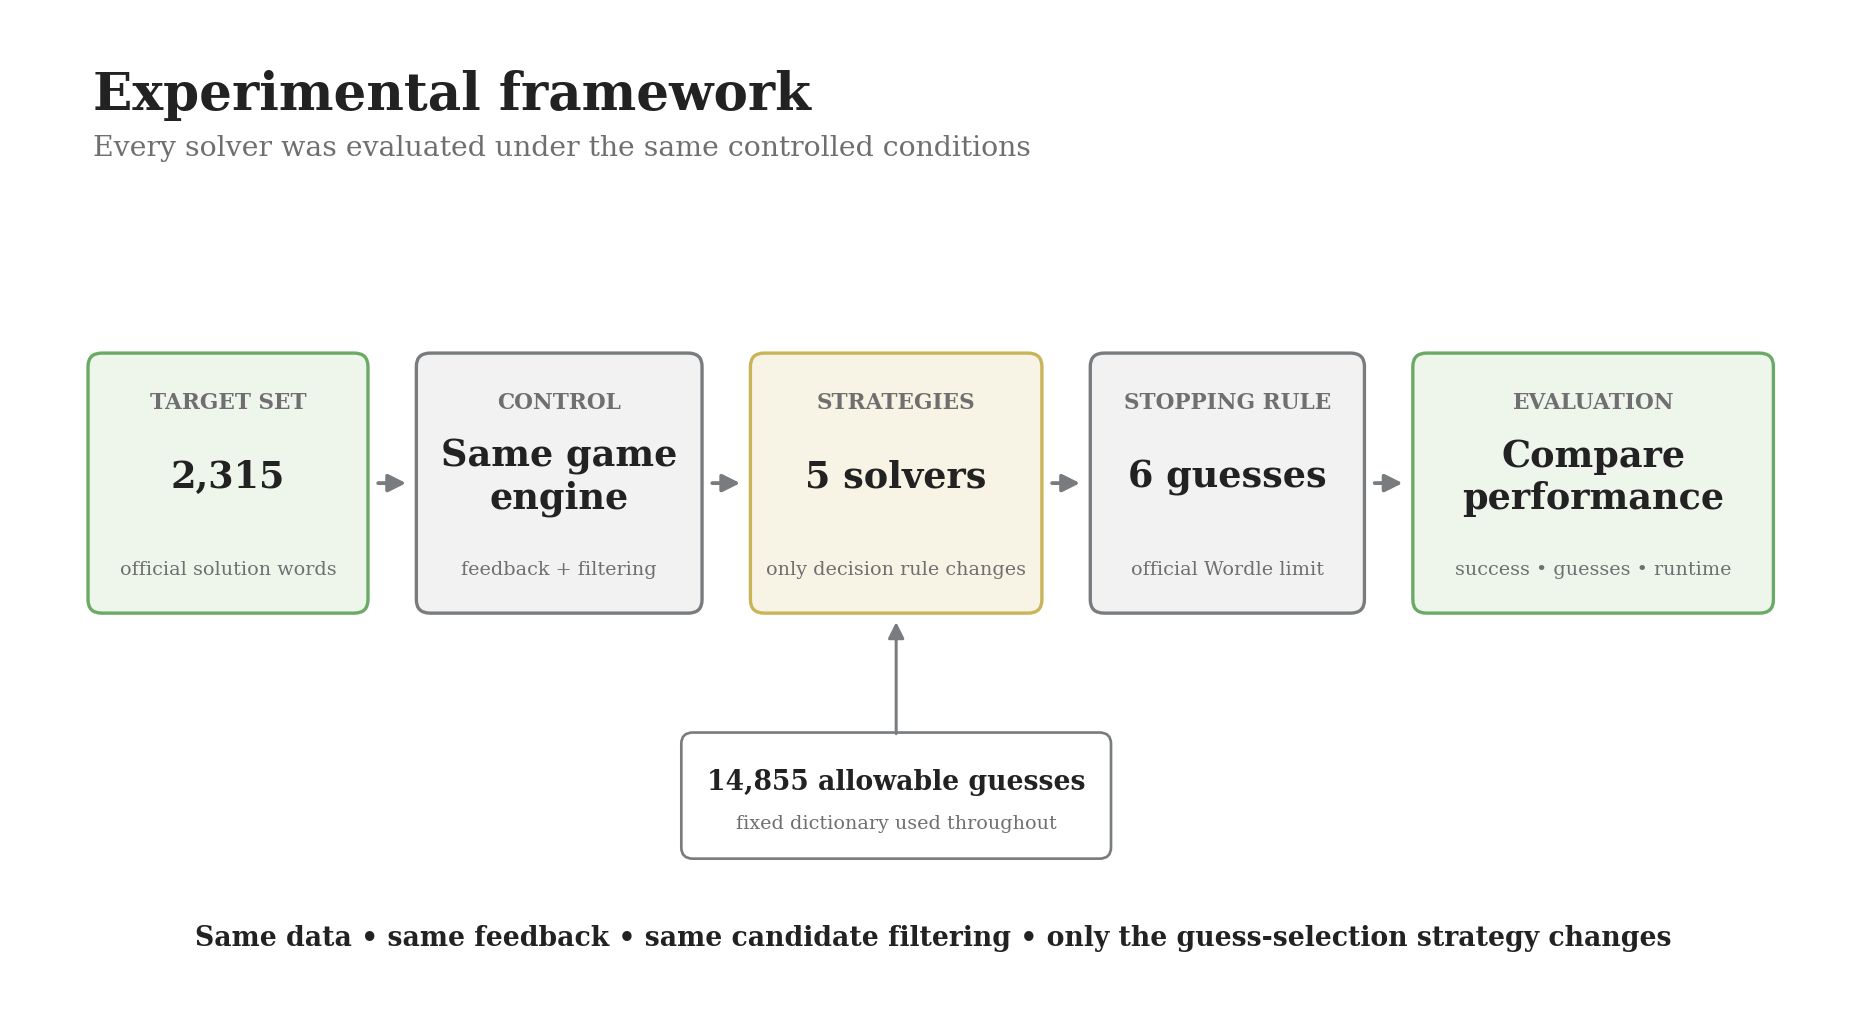

Saved as: experimental_framework_visual.png


In [160]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ============================================================
# EXPERIMENTAL FRAMEWORK VISUAL
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 9),
    dpi=120
)

fig.patch.set_facecolor("white")

fig.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.97,
    bottom=0.04
)

ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis("off")


# ============================================================
# COLOURS
# ============================================================

TEXT = "#222222"
MUTED = "#6F6F6F"

GREEN = "#6AAA64"
YELLOW = "#C9B458"
GREY = "#787C7E"

LIGHT_GREEN = "#EEF6EC"
LIGHT_YELLOW = "#F8F4E5"
LIGHT_GREY = "#F2F2F2"


# ============================================================
# TITLE
# ============================================================

ax.text(
    0.7,
    8.25,
    "Experimental framework",
    fontsize=31,
    fontweight="bold",
    color=TEXT,
    ha="left",
    va="center"
)

ax.text(
    0.7,
    7.78,
    "Every solver was evaluated under the same controlled conditions",
    fontsize=17,
    color=MUTED,
    ha="left",
    va="center"
)


# ============================================================
# HELPER
# ============================================================

def add_stage(
    x,
    y,
    width,
    height,
    title,
    main_text,
    sub_text=None,
    facecolor="white",
    edgecolor=GREY
):

    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.04,rounding_size=0.12",
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=2
    )

    ax.add_patch(box)

    ax.text(
        x + width / 2,
        y + height - 0.40,
        title,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=MUTED
    )

    ax.text(
        x + width / 2,
        y + height / 2 + 0.05,
        main_text,
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold",
        color=TEXT
    )

    if sub_text:

        ax.text(
            x + width / 2,
            y + 0.35,
            sub_text,
            ha="center",
            va="center",
            fontsize=11.5,
            color=MUTED
        )


def add_arrow(x1, x2, y):

    arrow = FancyArrowPatch(
        (x1, y),
        (x2, y),
        arrowstyle="-|>",
        mutation_scale=22,
        linewidth=2.3,
        color=GREY
    )

    ax.add_patch(arrow)


# ============================================================
# MAIN PIPELINE
# ============================================================

y = 3.65
h = 2.25

stages = [
    {
        "x": 0.70,
        "w": 2.35,
        "title": "TARGET SET",
        "main": "2,315",
        "sub": "official solution words",
        "face": LIGHT_GREEN,
        "edge": GREEN
    },
    {
        "x": 3.55,
        "w": 2.40,
        "title": "CONTROL",
        "main": "Same game\nengine",
        "sub": "feedback + filtering",
        "face": LIGHT_GREY,
        "edge": GREY
    },
    {
        "x": 6.45,
        "w": 2.45,
        "title": "STRATEGIES",
        "main": "5 solvers",
        "sub": "only decision rule changes",
        "face": LIGHT_YELLOW,
        "edge": YELLOW
    },
    {
        "x": 9.40,
        "w": 2.30,
        "title": "STOPPING RULE",
        "main": "6 guesses",
        "sub": "official Wordle limit",
        "face": LIGHT_GREY,
        "edge": GREY
    },
    {
        "x": 12.20,
        "w": 3.05,
        "title": "EVALUATION",
        "main": "Compare\nperformance",
        "sub": "success • guesses • runtime",
        "face": LIGHT_GREEN,
        "edge": GREEN
    }
]

for stage in stages:

    add_stage(
        x=stage["x"],
        y=y,
        width=stage["w"],
        height=h,
        title=stage["title"],
        main_text=stage["main"],
        sub_text=stage["sub"],
        facecolor=stage["face"],
        edgecolor=stage["edge"]
    )


# ============================================================
# ARROWS
# ============================================================

centre_y = y + h / 2

for left, right in zip(
    stages[:-1],
    stages[1:]
):

    add_arrow(
        left["x"] + left["w"] + 0.10,
        right["x"] - 0.10,
        centre_y
    )


# ============================================================
# ALLOWABLE-GUESS INPUT
# ============================================================

input_box = FancyBboxPatch(
    (5.85, 1.45),
    3.65,
    1.05,
    boxstyle="round,pad=0.04,rounding_size=0.10",
    facecolor="white",
    edgecolor=GREY,
    linewidth=1.6
)

ax.add_patch(input_box)

ax.text(
    7.675,
    2.10,
    "14,855 allowable guesses",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    color=TEXT
)

ax.text(
    7.675,
    1.72,
    "fixed dictionary used throughout",
    ha="center",
    va="center",
    fontsize=11.5,
    color=MUTED
)

# Arrow from allowable guesses into solver stage
arrow = FancyArrowPatch(
    (7.675, 2.50),
    (7.675, 3.56),
    arrowstyle="-|>",
    mutation_scale=20,
    linewidth=1.8,
    color=GREY
)

ax.add_patch(arrow)


# ============================================================
# CONTROLLED-EXPERIMENT MESSAGE
# ============================================================

ax.text(
    8.0,
    0.70,
    "Same data • same feedback • same candidate filtering • only the guess-selection strategy changes",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    color=TEXT
)


# ============================================================
# SAVE
# ============================================================

OUTPUT_FILE = "experimental_framework_visual.png"

plt.savefig(
    OUTPUT_FILE,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Saved as: {OUTPUT_FILE}")

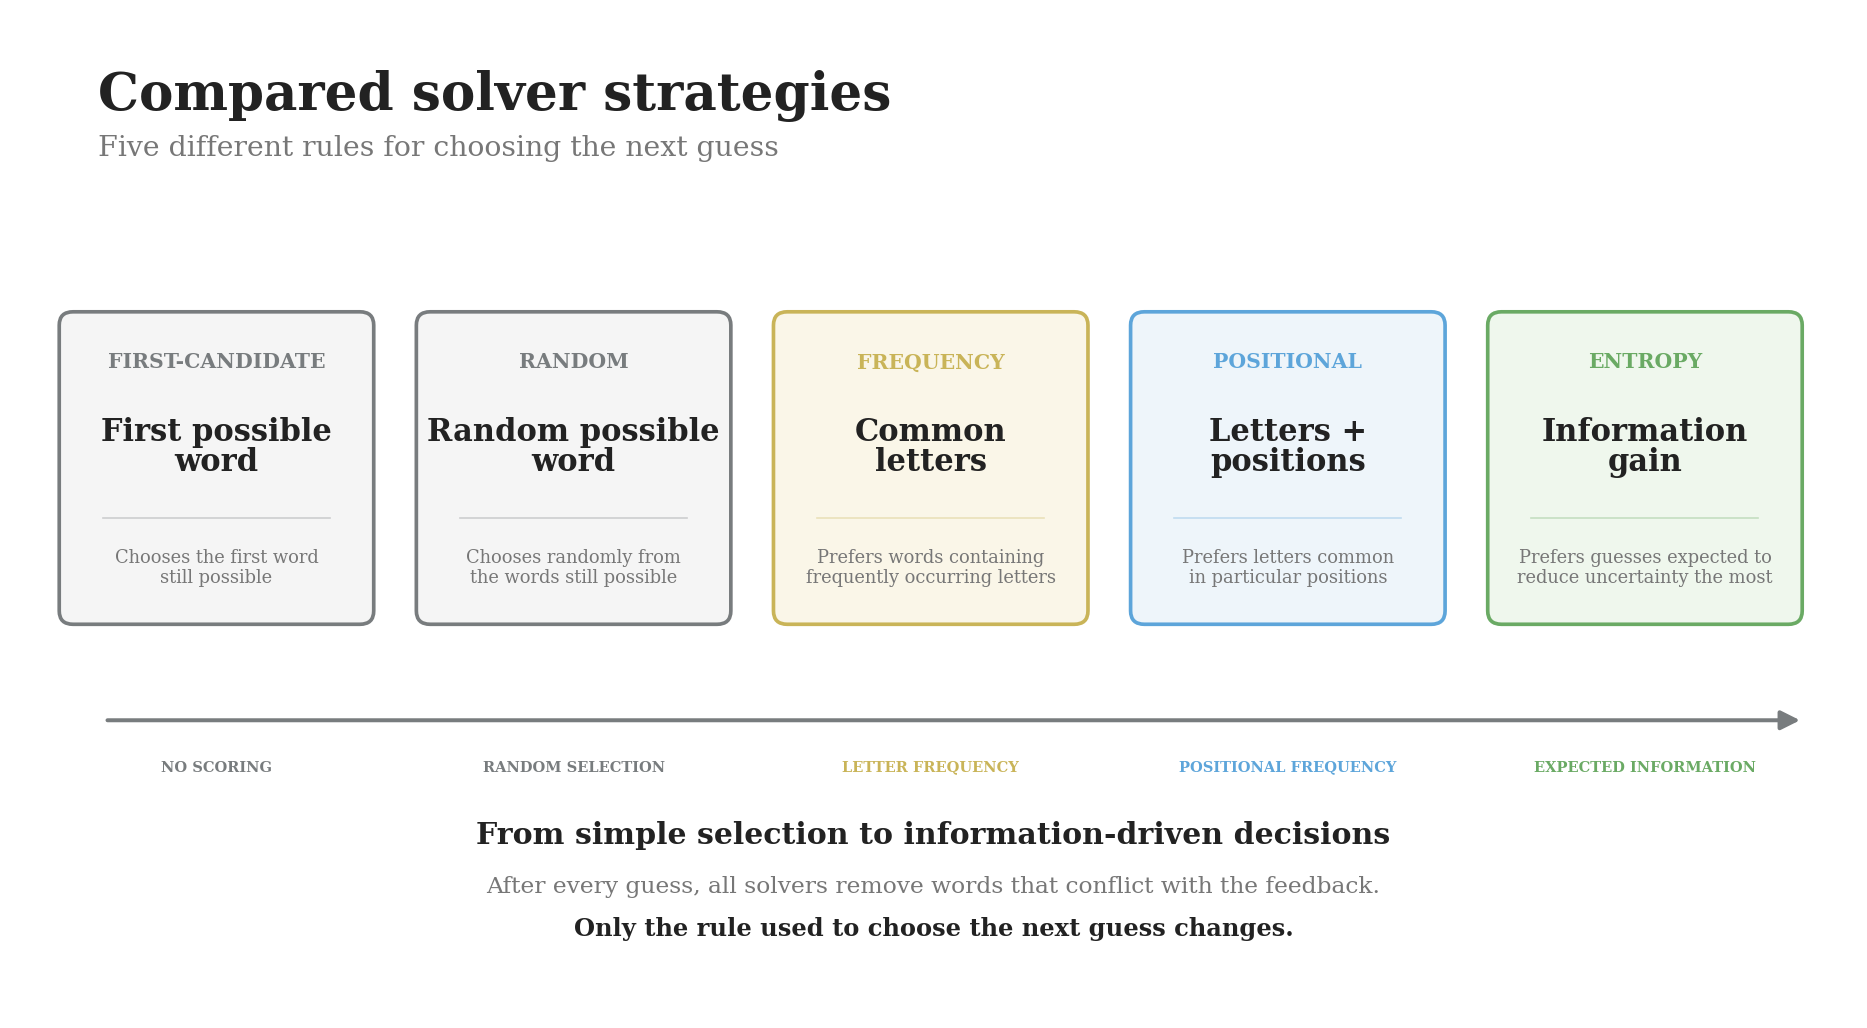

Saved as: solver_strategy_progression_wider_cards.png


In [161]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 9),
    dpi=120
)

fig.patch.set_facecolor("white")

fig.subplots_adjust(
    left=0.025,
    right=0.985,
    top=0.97,
    bottom=0.04
)

ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis("off")


# ============================================================
# COLOURS
# ============================================================

TEXT = "#222222"
MUTED = "#777777"

GREY = "#787C7E"
YELLOW = "#C9B458"
BLUE = "#5DA5DA"
GREEN = "#6AAA64"

LIGHT_GREY = "#F5F5F5"
LIGHT_YELLOW = "#FAF6E8"
LIGHT_BLUE = "#EEF5FA"
LIGHT_GREEN = "#EFF7ED"


# ============================================================
# TITLE
# ============================================================

ax.text(
    0.75,
    8.25,
    "Compared solver strategies",
    fontsize=31,
    fontweight="bold",
    color=TEXT,
    ha="left",
    va="center"
)

ax.text(
    0.75,
    7.78,
    "Five different rules for choosing the next guess",
    fontsize=17,
    color=MUTED,
    ha="left",
    va="center"
)


# ============================================================
# CARD DIMENSIONS
# ============================================================

CARD_Y = 3.55
CARD_W = 2.65
CARD_H = 2.72


# ============================================================
# STRATEGY DATA
# ============================================================

strategies = [
    {
        "name": "FIRST-CANDIDATE",
        "main": "First possible\nword",
        "detail": (
            "Chooses the first word\n"
            "still possible"
        ),
        "stage": "NO SCORING",
        "x": 0.45,
        "face": LIGHT_GREY,
        "edge": GREY
    },

    {
        "name": "RANDOM",
        "main": "Random possible\nword",
        "detail": (
            "Chooses randomly from\n"
            "the words still possible"
        ),
        "stage": "RANDOM SELECTION",
        "x": 3.55,
        "face": LIGHT_GREY,
        "edge": GREY
    },

    {
        "name": "FREQUENCY",
        "main": "Common\nletters",
        "detail": (
            "Prefers words containing\n"
            "frequently occurring letters"
        ),
        "stage": "LETTER FREQUENCY",
        "x": 6.65,
        "face": LIGHT_YELLOW,
        "edge": YELLOW
    },

    {
        "name": "POSITIONAL",
        "main": "Letters +\npositions",
        "detail": (
            "Prefers letters common\n"
            "in particular positions"
        ),
        "stage": "POSITIONAL FREQUENCY",
        "x": 9.75,
        "face": LIGHT_BLUE,
        "edge": BLUE
    },

    {
        "name": "ENTROPY",
        "main": "Information\ngain",
        "detail": (
            "Prefers guesses expected to\n"
            "reduce uncertainty the most"
        ),
        "stage": "EXPECTED INFORMATION",
        "x": 12.85,
        "face": LIGHT_GREEN,
        "edge": GREEN
    },
]


# ============================================================
# DRAW CARDS
# ============================================================

for s in strategies:

    card = FancyBboxPatch(
        (s["x"], CARD_Y),
        CARD_W,
        CARD_H,
        boxstyle="round,pad=0.04,rounding_size=0.12",
        facecolor=s["face"],
        edgecolor=s["edge"],
        linewidth=2.2
    )

    ax.add_patch(card)

    # Solver name
    ax.text(
        s["x"] + CARD_W / 2,
        CARD_Y + 2.31,
        s["name"],
        ha="center",
        va="center",
        fontsize=12.2,
        fontweight="bold",
        color=s["edge"]
    )

    # Main description
    ax.text(
        s["x"] + CARD_W / 2,
        CARD_Y + 1.55,
        s["main"],
        ha="center",
        va="center",
        fontsize=18.3,
        fontweight="bold",
        color=TEXT,
        linespacing=0.95
    )

    # Divider
    ax.plot(
        [
            s["x"] + 0.34,
            s["x"] + CARD_W - 0.34
        ],
        [
            CARD_Y + 0.91,
            CARD_Y + 0.91
        ],
        color=s["edge"],
        linewidth=1,
        alpha=0.32
    )

    # Short explanation
    ax.text(
        s["x"] + CARD_W / 2,
        CARD_Y + 0.47,
        s["detail"],
        ha="center",
        va="center",
        fontsize=10.7,
        color=MUTED,
        linespacing=1.15
    )


# ============================================================
# PROGRESSION ARROW
# ============================================================

arrow_y = 2.65

arrow = FancyArrowPatch(
    (0.80, arrow_y),
    (15.55, arrow_y),
    arrowstyle="-|>",
    mutation_scale=24,
    linewidth=2.4,
    color=GREY
)

ax.add_patch(arrow)


# ============================================================
# LABELS UNDER ARROW
# ============================================================

for s in strategies:

    ax.text(
        s["x"] + CARD_W / 2,
        2.23,
        s["stage"],
        ha="center",
        va="center",
        fontsize=8.8,
        fontweight="bold",
        color=s["edge"]
    )


# ============================================================
# MAIN TAKEAWAY
# ============================================================

ax.text(
    8.0,
    1.62,
    "From simple selection to information-driven decisions",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
    color=TEXT
)


# ============================================================
# COMMON EXPERIMENTAL RULE
# ============================================================

ax.text(
    8.0,
    1.16,
    "After every guess, all solvers remove words that conflict with the feedback.",
    ha="center",
    va="center",
    fontsize=14,
    color=MUTED
)

ax.text(
    8.0,
    0.78,
    "Only the rule used to choose the next guess changes.",
    ha="center",
    va="center",
    fontsize=14.5,
    fontweight="bold",
    color=TEXT
)


# ============================================================
# SAVE
# ============================================================

OUTPUT_FILE = "solver_strategy_progression_wider_cards.png"

plt.savefig(
    OUTPUT_FILE,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Saved as: {OUTPUT_FILE}")

In [162]:
# ============================================================
# ANIMATION:
# HOW FEEDBACK SHRINKS THE SEARCH SPACE
#
# Run after:
#   - solutions
#   - get_feedback()
#   - filter_candidates()
# have already been defined.
# ============================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import FancyBboxPatch


# ============================================================
# CONFIGURATION
# ============================================================

OUTPUT_DIR = Path("presentation_visuals")
OUTPUT_DIR.mkdir(exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "candidate_filtering_animation.gif"

# Use a real target purely to generate an illustrative
# feedback pattern.
TARGET = "CRANE"
GUESS = "SLATE"

# Animation speed.
FPS = 4

# How long each major stage stays on screen.
STAGE_FRAMES = [
    8,    # starting search space
    8,    # reveal guess
    10,   # reveal feedback
    12,   # filtering animation
    12    # final reduced set
]


# ============================================================
# GET REAL FEEDBACK AND FILTERED SET
# ============================================================

feedback = get_feedback(GUESS, TARGET)

remaining = filter_candidates(
    solutions,
    GUESS,
    feedback
)

START_COUNT = len(solutions)
END_COUNT = len(remaining)

print("Target:", TARGET)
print("Guess:", GUESS)
print("Feedback:", feedback)
print("Starting solutions:", START_COUNT)
print("Remaining solutions:", END_COUNT)


# ============================================================
# WORDLE COLOURS
# ============================================================

GREEN = "#6AAA64"
YELLOW = "#C9B458"
DARK_GREY = "#787C7E"

TEXT = "#222222"
MUTED = "#707070"

LIGHT_GREY = "#F2F2F2"
VERY_LIGHT_GREY = "#F8F8F8"

RED = "#D9534F"


# ============================================================
# CONVERT FEEDBACK TO COLOURS
# ============================================================

def feedback_colour(value):
    """
    Handles several common feedback encodings.
    Adjust only if your notebook uses a different encoding.
    """

    value_str = str(value).lower()

    if value in (2, "2") or value_str in (
        "green",
        "correct"
    ):
        return GREEN

    if value in (1, "1") or value_str in (
        "yellow",
        "present"
    ):
        return YELLOW

    return DARK_GREY


feedback_colours = [
    feedback_colour(x)
    for x in feedback
]


# ============================================================
# SELECT EXAMPLE WORDS
# ============================================================

remaining_upper = [
    word.upper()
    for word in remaining
]

# Words removed by filtering
remaining_set = set(remaining)

removed = [
    word.upper()
    for word in solutions
    if word not in remaining_set
]

# Only display a few examples.
compatible_examples = remaining_upper[:4]
removed_examples = removed[:4]


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 9),
    dpi=100
)

fig.patch.set_facecolor("white")

plt.subplots_adjust(
    left=0,
    right=1,
    top=1,
    bottom=0
)


# ============================================================
# HELPER: WORDLE TILES
# ============================================================

def draw_wordle_tiles(
    ax,
    word,
    colours,
    centre_x=8,
    y=5.7,
    tile_size=0.72,
    gap=0.12
):

    total_width = (
        len(word) * tile_size
        + (len(word) - 1) * gap
    )

    start_x = centre_x - total_width / 2

    for i, letter in enumerate(word):

        x = start_x + i * (tile_size + gap)

        tile = FancyBboxPatch(
            (x, y),
            tile_size,
            tile_size,
            boxstyle="round,pad=0.02,rounding_size=0.04",
            facecolor=colours[i],
            edgecolor=colours[i],
            linewidth=1.5
        )

        ax.add_patch(tile)

        ax.text(
            x + tile_size / 2,
            y + tile_size / 2,
            letter.upper(),
            ha="center",
            va="center",
            fontsize=22,
            fontweight="bold",
            color="white"
        )


# ============================================================
# HELPER: STARTING SEARCH SPACE
# ============================================================

def draw_starting_space(ax):

    ax.text(
        8,
        6.30,
        f"{START_COUNT:,}",
        ha="center",
        va="center",
        fontsize=50,
        fontweight="bold",
        color=TEXT
    )

    ax.text(
        8,
        5.82,
        "possible solutions",
        ha="center",
        va="center",
        fontsize=19,
        color=MUTED
    )


# ============================================================
# HELPER: GUESS
# ============================================================

def draw_guess(ax):

    ax.text(
        8,
        6.65,
        "Make a guess",
        ha="center",
        va="center",
        fontsize=17,
        color=MUTED
    )

    # Empty/neutral tiles before feedback
    draw_wordle_tiles(
        ax,
        GUESS.upper(),
        [DARK_GREY] * 5,
        centre_x=8,
        y=5.55
    )


# ============================================================
# HELPER: FEEDBACK
# ============================================================

def draw_feedback(ax):

    ax.text(
        8,
        6.65,
        "Wordle returns feedback",
        ha="center",
        va="center",
        fontsize=17,
        color=MUTED
    )

    draw_wordle_tiles(
        ax,
        GUESS.upper(),
        feedback_colours,
        centre_x=8,
        y=5.55
    )


# ============================================================
# HELPER: FILTERING EXAMPLES
# ============================================================

def draw_filtering(
    ax,
    progress
):

    # Feedback remains visible
    draw_feedback(ax)

    ax.text(
        8,
        4.95,
        "Which words could have produced this feedback?",
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        color=TEXT
    )

    # --------------------------------------------------------
    # LEFT: removed words
    # --------------------------------------------------------

    left_x = 5.3

    ax.text(
        left_x,
        4.35,
        "INCOMPATIBLE",
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=RED
    )

    # --------------------------------------------------------
    # RIGHT: surviving words
    # --------------------------------------------------------

    right_x = 10.7

    ax.text(
        right_x,
        4.35,
        "STILL POSSIBLE",
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=GREEN
    )

    # Number of examples revealed
    n_removed = min(
        len(removed_examples),
        int(progress * len(removed_examples)) + 1
    )

    n_kept = min(
        len(compatible_examples),
        int(progress * len(compatible_examples)) + 1
    )

    # Removed examples
    for i, word in enumerate(
        removed_examples[:n_removed]
    ):

        y = 3.85 - i * 0.43

        ax.text(
            left_x - 0.65,
            y,
            "✕",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color=RED
        )

        ax.text(
            left_x,
            y,
            word,
            ha="center",
            va="center",
            fontsize=16,
            color=MUTED
        )

    # Compatible examples
    for i, word in enumerate(
        compatible_examples[:n_kept]
    ):

        y = 3.85 - i * 0.43

        ax.text(
            right_x - 0.65,
            y,
            "✓",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color=GREEN
        )

        ax.text(
            right_x,
            y,
            word,
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color=TEXT
        )


# ============================================================
# HELPER: FINAL RESULT
# ============================================================

def draw_final(ax):

    draw_feedback(ax)

    # Arrow / transformation
    ax.text(
        8,
        4.45,
        "Filter using the feedback",
        ha="center",
        va="center",
        fontsize=17,
        color=MUTED
    )

    # Starting count
    ax.text(
        5.1,
        3.35,
        f"{START_COUNT:,}",
        ha="center",
        va="center",
        fontsize=40,
        fontweight="bold",
        color=TEXT
    )

    ax.text(
        5.1,
        2.93,
        "possible",
        ha="center",
        va="center",
        fontsize=15,
        color=MUTED
    )

    # Arrow
    ax.annotate(
        "",
        xy=(9.8, 3.35),
        xytext=(6.2, 3.35),
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=2.5,
            color=DARK_GREY
        )
    )

    # Remaining count
    ax.text(
        10.9,
        3.35,
        f"{END_COUNT:,}",
        ha="center",
        va="center",
        fontsize=40,
        fontweight="bold",
        color=GREEN
    )

    ax.text(
        10.9,
        2.93,
        "remain",
        ha="center",
        va="center",
        fontsize=15,
        color=MUTED
    )

    # Final takeaway box
    box = FancyBboxPatch(
        (3.7, 1.25),
        8.6,
        0.92,
        boxstyle="round,pad=0.04,rounding_size=0.08",
        facecolor=VERY_LIGHT_GREY,
        edgecolor="none"
    )

    ax.add_patch(box)

    ax.text(
        8,
        1.72,
        "Every solver starts the next turn from this same reduced set.",
        ha="center",
        va="center",
        fontsize=17,
        fontweight="bold",
        color=TEXT
    )


# ============================================================
# FRAME STRUCTURE
# ============================================================

stage_1_end = STAGE_FRAMES[0]

stage_2_end = (
    stage_1_end
    + STAGE_FRAMES[1]
)

stage_3_end = (
    stage_2_end
    + STAGE_FRAMES[2]
)

stage_4_end = (
    stage_3_end
    + STAGE_FRAMES[3]
)

total_frames = sum(STAGE_FRAMES)


# ============================================================
# ANIMATION FUNCTION
# ============================================================

def update(frame):

    ax.clear()

    ax.set_xlim(0, 16)
    ax.set_ylim(0, 9)
    ax.axis("off")

    # --------------------------------------------------------
    # TITLE
    # --------------------------------------------------------

    ax.text(
        0.8,
        8.25,
        "How feedback shrinks the search space",
        ha="left",
        va="center",
        fontsize=31,
        fontweight="bold",
        color=TEXT
    )

    ax.text(
        0.8,
        7.78,
        "Every solver uses the same filtering process after each guess",
        ha="left",
        va="center",
        fontsize=17,
        color=MUTED
    )

    # --------------------------------------------------------
    # STAGE 1
    # --------------------------------------------------------

    if frame < stage_1_end:

        draw_starting_space(ax)

        ax.text(
            8,
            4.75,
            "Before any feedback, every solution is still possible.",
            ha="center",
            va="center",
            fontsize=17,
            color=MUTED
        )

    # --------------------------------------------------------
    # STAGE 2
    # --------------------------------------------------------

    elif frame < stage_2_end:

        draw_guess(ax)

        ax.text(
            8,
            4.70,
            f"Start with {START_COUNT:,} possible solutions",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color=TEXT
        )

    # --------------------------------------------------------
    # STAGE 3
    # --------------------------------------------------------

    elif frame < stage_3_end:

        draw_feedback(ax)

        ax.text(
            8,
            4.70,
            "The colours impose new constraints on the solution.",
            ha="center",
            va="center",
            fontsize=17,
            color=MUTED
        )

    # --------------------------------------------------------
    # STAGE 4
    # --------------------------------------------------------

    elif frame < stage_4_end:

        local_frame = (
            frame - stage_3_end
        )

        progress = (
            local_frame
            / max(STAGE_FRAMES[3] - 1, 1)
        )

        draw_filtering(
            ax,
            progress
        )

    # --------------------------------------------------------
    # STAGE 5
    # --------------------------------------------------------

    else:

        draw_final(ax)

    return []


# ============================================================
# CREATE ANIMATION
# ============================================================

animation = FuncAnimation(
    fig,
    update,
    frames=total_frames,
    interval=1000 / FPS,
    repeat=True
)


# ============================================================
# SAVE GIF
# ============================================================

writer = PillowWriter(
    fps=FPS
)

animation.save(
    OUTPUT_FILE,
    writer=writer,
    dpi=100
)

plt.close(fig)

print(f"\nSaved animation to:")
print(OUTPUT_FILE)

Target: CRANE
Guess: SLATE
Feedback: ['grey', 'grey', 'green', 'grey', 'green']
Starting solutions: 2315
Remaining solutions: 28


C:\Users\tahmi\AppData\Local\Temp\ipykernel_23036\2940860944.py:682: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) DejaVu Serif.
  animation.save(
C:\Users\tahmi\AppData\Local\Temp\ipykernel_23036\2940860944.py:682: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) DejaVu Serif.
  animation.save(



Saved animation to:
presentation_visuals\candidate_filtering_animation.gif


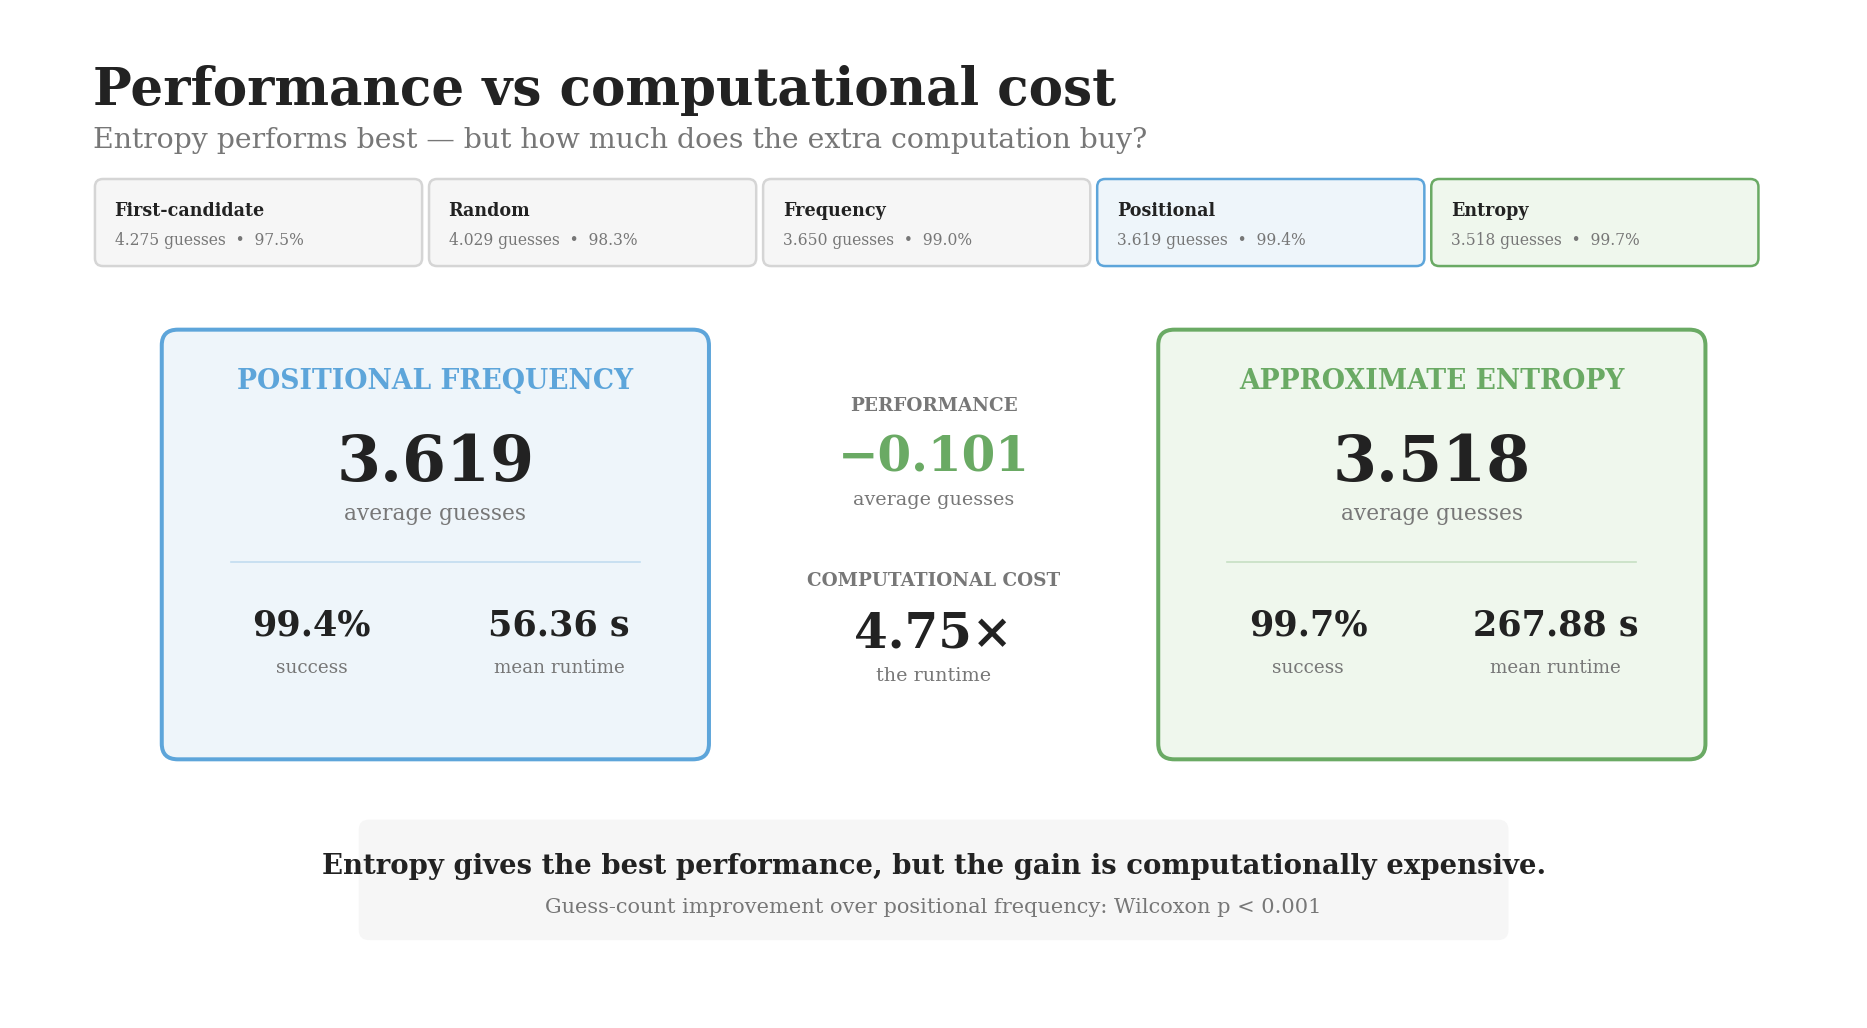

Saved as: performance_vs_computational_cost.png


In [163]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


# ============================================================
# DATA
# ============================================================

solver_results = [
    ("First-candidate", 4.275, 97.5),
    ("Random", 4.029, 98.3),
    ("Frequency", 3.650, 99.0),
    ("Positional", 3.619, 99.4),
    ("Entropy", 3.518, 99.7),
]

pos_guesses = 3.619
entropy_guesses = 3.518

pos_success = 99.4
entropy_success = 99.7

pos_runtime = 56.36
entropy_runtime = 267.88

guess_improvement = pos_guesses - entropy_guesses
runtime_multiplier = entropy_runtime / pos_runtime


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 9),
    dpi=120
)

fig.patch.set_facecolor("white")

fig.subplots_adjust(
    left=0.025,
    right=0.985,
    top=0.97,
    bottom=0.04
)

ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis("off")


# ============================================================
# COLOURS
# ============================================================

TEXT = "#222222"
MUTED = "#777777"

BLUE = "#5DA5DA"
GREEN = "#6AAA64"
YELLOW = "#C9B458"
GREY = "#787C7E"

LIGHT_BLUE = "#EEF5FA"
LIGHT_GREEN = "#EFF7ED"
LIGHT_GREY = "#F6F6F6"


# ============================================================
# TITLE
# ============================================================

ax.text(
    0.7,
    8.30,
    "Performance vs computational cost",
    fontsize=31,
    fontweight="bold",
    color=TEXT,
    ha="left",
    va="center"
)

ax.text(
    0.7,
    7.85,
    "Entropy performs best — but how much does the extra computation buy?",
    fontsize=17,
    color=MUTED,
    ha="left",
    va="center"
)


# ============================================================
# FIVE-SOLVER CONTEXT STRIP
# ============================================================

strip_y = 6.75
strip_h = 0.72

start_x = 0.75
gap = 0.12
box_w = 2.78

for i, (name, guesses, success) in enumerate(solver_results):

    x = start_x + i * (box_w + gap)

    if name == "Positional":
        face = LIGHT_BLUE
        edge = BLUE

    elif name == "Entropy":
        face = LIGHT_GREEN
        edge = GREEN

    else:
        face = LIGHT_GREY
        edge = "#D5D5D5"

    box = FancyBboxPatch(
        (x, strip_y),
        box_w,
        strip_h,
        boxstyle="round,pad=0.03,rounding_size=0.07",
        facecolor=face,
        edgecolor=edge,
        linewidth=1.5
    )

    ax.add_patch(box)

    ax.text(
        x + 0.14,
        strip_y + 0.47,
        name,
        ha="left",
        va="center",
        fontsize=10.5,
        fontweight="bold",
        color=TEXT
    )

    ax.text(
        x + 0.14,
        strip_y + 0.20,
        f"{guesses:.3f} guesses  •  {success:.1f}%",
        ha="left",
        va="center",
        fontsize=9.3,
        color=MUTED
    )


# ============================================================
# MAIN COMPARISON CARDS
# ============================================================

CARD_Y = 2.35
CARD_H = 3.75
CARD_W = 4.65

POS_X = 1.35
ENT_X = 10.0


def comparison_card(
    x,
    title,
    guesses,
    success,
    runtime,
    face,
    edge
):

    card = FancyBboxPatch(
        (x, CARD_Y),
        CARD_W,
        CARD_H,
        boxstyle="round,pad=0.05,rounding_size=0.14",
        facecolor=face,
        edgecolor=edge,
        linewidth=2.4
    )

    ax.add_patch(card)

    # Strategy
    ax.text(
        x + CARD_W / 2,
        CARD_Y + 3.34,
        title,
        ha="center",
        va="center",
        fontsize=16,
        fontweight="bold",
        color=edge
    )

    # Average guesses
    ax.text(
        x + CARD_W / 2,
        CARD_Y + 2.60,
        f"{guesses:.3f}",
        ha="center",
        va="center",
        fontsize=38,
        fontweight="bold",
        color=TEXT
    )

    ax.text(
        x + CARD_W / 2,
        CARD_Y + 2.15,
        "average guesses",
        ha="center",
        va="center",
        fontsize=13,
        color=MUTED
    )

    # Divider
    ax.plot(
        [x + 0.55, x + CARD_W - 0.55],
        [CARD_Y + 1.72, CARD_Y + 1.72],
        color=edge,
        linewidth=1,
        alpha=0.3
    )

    # Success
    ax.text(
        x + 1.25,
        CARD_Y + 1.15,
        f"{success:.1f}%",
        ha="center",
        va="center",
        fontsize=21,
        fontweight="bold",
        color=TEXT
    )

    ax.text(
        x + 1.25,
        CARD_Y + 0.77,
        "success",
        ha="center",
        va="center",
        fontsize=11,
        color=MUTED
    )

    # Runtime
    ax.text(
        x + 3.40,
        CARD_Y + 1.15,
        f"{runtime:.2f} s",
        ha="center",
        va="center",
        fontsize=21,
        fontweight="bold",
        color=TEXT
    )

    ax.text(
        x + 3.40,
        CARD_Y + 0.77,
        "mean runtime",
        ha="center",
        va="center",
        fontsize=11,
        color=MUTED
    )


comparison_card(
    POS_X,
    "POSITIONAL FREQUENCY",
    pos_guesses,
    pos_success,
    pos_runtime,
    LIGHT_BLUE,
    BLUE
)

comparison_card(
    ENT_X,
    "APPROXIMATE ENTROPY",
    entropy_guesses,
    entropy_success,
    entropy_runtime,
    LIGHT_GREEN,
    GREEN
)


# ============================================================
# CENTRAL TRADE-OFF
# ============================================================

centre_x = 8.0

# Guess improvement
ax.text(
    centre_x,
    5.47,
    "PERFORMANCE",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    color=MUTED
)

ax.text(
    centre_x,
    5.00,
    f"−{guess_improvement:.3f}",
    ha="center",
    va="center",
    fontsize=29,
    fontweight="bold",
    color=GREEN
)

ax.text(
    centre_x,
    4.63,
    "average guesses",
    ha="center",
    va="center",
    fontsize=11.5,
    color=MUTED
)


# Runtime cost
ax.text(
    centre_x,
    3.90,
    "COMPUTATIONAL COST",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    color=MUTED
)

ax.text(
    centre_x,
    3.43,
    f"{runtime_multiplier:.2f}×",
    ha="center",
    va="center",
    fontsize=29,
    fontweight="bold",
    color=TEXT
)

ax.text(
    centre_x,
    3.05,
    "the runtime",
    ha="center",
    va="center",
    fontsize=11.5,
    color=MUTED
)


# ============================================================
# BOTTOM TAKEAWAY
# ============================================================

takeaway = FancyBboxPatch(
    (3.05, 0.72),
    9.90,
    1.00,
    boxstyle="round,pad=0.04,rounding_size=0.09",
    facecolor=LIGHT_GREY,
    edgecolor="none"
)

ax.add_patch(takeaway)

ax.text(
    8.0,
    1.34,
    "Entropy gives the best performance, but the gain is computationally expensive.",
    ha="center",
    va="center",
    fontsize=16.5,
    fontweight="bold",
    color=TEXT
)

ax.text(
    8.0,
    0.98,
    "Guess-count improvement over positional frequency: Wilcoxon p < 0.001",
    ha="center",
    va="center",
    fontsize=12.5,
    color=MUTED
)


# ============================================================
# SAVE
# ============================================================

OUTPUT_FILE = "performance_vs_computational_cost.png"

plt.savefig(
    OUTPUT_FILE,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Saved as: {OUTPUT_FILE}")